In [1]:
# ML classes
from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager
# Plot distributions
import seaborn as sns
# basics
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import re
import numpy as np
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
import pickle
from tabulate import tabulate
import math 

#ML 
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_predict, cross_val_score, LeaveOneOut, StratifiedKFold, KFold
import xgboost as xgb
import shap

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import make_scorer

#Survival 
from lifelines.utils import concordance_index, median_survival_times,find_best_parametric_model
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import rmst_plot, qq_plot,add_at_risk_counts
from lifelines import LogNormalFitter, LogLogisticFitter, WeibullFitter, ExponentialFitter, WeibullAFTFitter, KaplanMeierFitter, CoxPHFitter

from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv

In [2]:
# Aggregate Feature Importances Across All Folds
def aggregate_feature_importances(importance_list):
    # Aggregate feature importance over multiple dictionaries
    all_keys = set(k for dic in importance_list for k in dic)
    aggregated_importance = {k: [] for k in all_keys}
    for dic in importance_list:
        for k in all_keys:
            aggregated_importance[k].append(dic.get(k, 0))

    # Calculate the mean for each feature
    mean_importance = {k: np.mean(v) for k, v in aggregated_importance.items()}
    return mean_importance


def c_index_scorer(y_true, y_pred):
    """
    Custom scorer to calculate Concordance Index (C-index) for single-column `y_true`.
    Negative values in `y_true` indicate censored data; positive values indicate events.
    
    Parameters:
    - y_true: 1D array of survival times (negative for censored, positive for events).
    - y_pred: Predicted risk scores (higher scores indicate higher risk).
    
    Returns:
    - C-index: Concordance Index for the predictions.
    """
    # Separate survival times and event indicators
    events = np.where(y_true < 0, 0, 1)  # 0 for censored, 1 for deceased
    times = np.abs(y_true)  #survival_time=np.abs(y_true) Absolute values for survival times
    #event_indicator = (y_true > 0).astype(int)  # 1 for events (positive values), 0 for censored (negative values)

    y_surv = Surv.from_arrays(event=events, time=times)

    # Calculate and return the C-index
    return concordance_index_ipcw(y_surv, y_surv, y_pred)[0]
    #return concordance_index(survival_time, -y_pred, event_indicator)

class CustomStratifiedKFold:
    def __init__(self, n_splits=5, shuffle=True, random_state=420):
        self.n_splits = n_splits
        self.skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    def split(self, X, y, groups=None):
        # Define labels based on the sign of y (negative for censored, positive for deceased)

        if isinstance(y, np.ndarray):  # y is a numpy array from Surv.from_arrays
            labels = y['event']  # Event status is the first column (event = 1, censored = 0)
        else:
            labels = np.where(y < 0, 0, 1)  # 0 for censored, 1 for deceased

        # Stratify based on these labels
        return self.skf.split(X, labels)

    def get_n_splits(self, X=None, y=None, groups=None):
        # We don't need to use the `groups` argument here, just return `n_splits`
        return self.n_splits


def search_best_model(estimator, param_grid, X_train, y_train, n_splits=10, random_state=420):
       # Create a custom scorer using C-index
    custom_scorer = make_scorer(c_index_scorer, greater_is_better=True)

    #cv_inner = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    #cv_inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_inner = CustomStratifiedKFold(n_splits=5, random_state=random_state)
    random_search = RandomizedSearchCV(estimator, param_grid,
                                           cv=cv_inner, n_iter=30,
                                           scoring=custom_scorer, refit=True,
                                           random_state=random_state, n_jobs=-1)

    # random_search = RandomizedSearchCV(estimator,
    #                                    param_distributions=param_grid,
    #                                    cv=cv_inner, n_iter=30,
    #                                    scoring=as_cumulative_dynamic_auc_scorer(estimator, times=np.array([1,6,12,18,24,30])),
    #                                    refit=True,
    #                                    random_state=random_state, n_jobs=-1)
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    return best_model

from sksurv.ensemble import RandomSurvivalForest
def cross_validate_and_analyze(X_train, y_time_train, y_event_train, params = None, param_grid = None, n_splits=10, random_state=420):
    """
    Function to perform cross-validation, train an XGBoost model on each fold,
    and calculate SHAP values, feature importance, and risk scores.

    Parameters:
    - X_train: pd.DataFrame
        Training feature dataset.
    - y_time_train: pd.Series
        Training time target.
    - y_event_train: pd.Series
        Training event target (1 for event occurred, 0 for censored).
    - params: dict
        Dictionary of XGBoost parameters.
    - n_splits: int (default=10)
        Number of folds for cross-validation.
    - random_state: int (default=420)
        Random state for reproducibility.

    Returns:
    - model_list: list
        List of trained models for each fold.
    - mean_importance_gain: dict
        Mean feature importance by gain across all folds.
    - mean_importance_cover: dict
        Mean feature importance by cover across all folds.
    - mean_importance_weight: dict
        Mean feature importance by weight across all folds.
    - train_shap_values: np.ndarray
        Concatenated SHAP values from all folds.
    - risk_scores_train: pd.Series
        Risk scores from cross-validation predictions.
    - c_index_train: float
        Concordance index across validation folds.
    """
    if params is None:
        params = {'objective': 'survival:cox', 'eval_metric': 'cox-nloglik', 'tree_method': 'hist', 'random_state':random_state, 'n_jobs':-1}
    # Initialize cross-validator
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Lists to store results
    feature_importances_gain = []
    feature_importances_cover = []
    feature_importances_weight = []
    shap_values_list = []
    risk_scores_list = []
    validation_indices_list = []
    model_list = []

    # Loop over each fold
    for train_index, test_index in kf.split(X_train, y_event_train):
        # Split data into training and validation sets for each fold
        X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_fold, y_test_fold = y_time_train.iloc[train_index], y_time_train.iloc[test_index]
        labels = np.where(y_train_fold < 0, 0, 1)  # 0 for censored, 1 for deceased

        estimator = xgb.XGBRegressor(**params)
        #estimator = RandomSurvivalForest(**params)

        if param_grid is not None:
            estimator = search_best_model(estimator, param_grid, X_train_fold, y_train_fold,
                                          config.tuning_k, random_state)
        else:
            # Fit the XGBRegressor model with early stopping
            estimator.fit(
                X_train_fold,
                y_train_fold,
                eval_set=[(X_test_fold, y_test_fold)],
                #eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
                verbose=False
            )

        # Append trained model to model list
        model_list.append(estimator)

        # Step 1: Get Feature Importance for the Fold
        booster = estimator.get_booster()
        importance_gain = booster.get_score(importance_type='gain')
        importance_cover = booster.get_score(importance_type='cover')
        importance_weight = booster.get_score(importance_type='weight')

        # Append importance dictionaries to lists
        feature_importances_gain.append(importance_gain)
        feature_importances_cover.append(importance_cover)
        feature_importances_weight.append(importance_weight)

        # Step 2: Calculate SHAP Values for the Fold
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_fold)
        shap_values_list.append(shap_values)

        # Step 3: Predict Risk Scores for the Validation Set
        risk_scores = estimator.predict(X_test_fold)
        risk_scores_list.append(risk_scores)
        validation_indices_list.append(X_test_fold.index)  # Track SampleNames corresponding to the validation set

    # Step 4: Aggregate Feature Importance Across All Folds
    mean_importance_gain = aggregate_feature_importances(feature_importances_gain)
    mean_importance_cover = aggregate_feature_importances(feature_importances_cover)
    mean_importance_weight = aggregate_feature_importances(feature_importances_weight)

    # Step 5: Concatenate SHAP Values Across All Folds
    train_shap_values = np.concatenate(shap_values_list, axis=0)

    # Step 6: Concatenate Risk Scores and Validation Indices for C-Index and AUC Calculation
    # Concatenate all risk scores and indices to get a full view of cross-validation predictions
    all_validation_indices = np.concatenate(validation_indices_list)
    risk_scores_train = np.concatenate(risk_scores_list)

    # Assign SampleNames to the risk scores
    risk_scores_train = pd.Series(risk_scores_train, index=all_validation_indices, name='Risk score')

    # Create a sorted array of validation set survival times and events based on indices
    y_time_val_pred = y_time_train.loc[all_validation_indices]
    y_event_val_pred = y_event_train.loc[all_validation_indices]
    y_surv_train = Surv.from_arrays(event=y_event_val_pred, time=y_time_val_pred.abs())

    # Step 7: Calculate Concordance Index (C-index) using lifelines
    #c_index_train = concordance_index(y_time_val_pred.abs(), -risk_scores_train.values, y_event_val_pred)
    #c_index_train = concordance_index_censored(y_surv['event'], y_surv['time'], risk_scores_train.values)[0]

    c_index_train = concordance_index_ipcw(y_surv_train, y_surv_train, risk_scores_train.values)[0]
    print(f"Concordance Index (C-index) across validation folds: {c_index_train:.4f}")

    return (model_list, mean_importance_gain, mean_importance_cover, mean_importance_weight,
            train_shap_values, risk_scores_train, c_index_train, all_validation_indices, y_time_val_pred, y_event_val_pred)

In [3]:
def train_and_evaluate_model(X_test, y_time_test, y_event_test, 
                             X_train = None, y_time_train = None, get_only_model = False,
                             n_splits = 5,
                             estimator = None, params = None, param_grid=None, random_state = 420):
    """
    Function to train an XGBoost model for survival analysis, evaluate it, and visualize SHAP values.
    
    Parameters:
    - X_test: pd.DataFrame
        Testing feature dataset.
    - y_time_test: pd.Series
        Testing time target.
    - y_event_test: pd.Series
        Testing event target (1 for event occurred, 0 for censored).
    - X_train: pd.DataFrame
        Training feature dataset.
    - y_time_train: pd.Series
        Training time target.
    - params: dict
        XGBoost parameters to configure the model.

    Returns:
    - model: xgb.XGBRegressor
        Trained XGBoost model.
    - shap_values: np.ndarray
        SHAP values for the testing set.
    - risk scores: predicted risk scores
    - c_index: float
        Concordance index for the testing set.
    """
    if estimator is None and X_train is not None and y_time_train is not None:
        # Initialize the XGBRegressor model
        if params is None:
            params = {'objective': 'survival:cox', 'eval_metric': 'cox-nloglik', 'tree_method': 'hist', 'random_state':random_state, 'n_jobs':-1}

        estimator = xgb.XGBRegressor(**params)
        
        if param_grid is not None:
            estimator = search_best_model(estimator, param_grid, X_train, 
                                          y_time_train, n_splits, random_state)
        else:
            # Fit the XGBRegressor model with early stopping
            estimator.fit(X_train, y_time_train,
                          #eval_set=[(X_test, y_time_test)], 
                          verbose=False)
    
    if get_only_model:
        return estimator
    
    # Calculate importance and SHAP Values for the Testing Set
    booster = estimator.get_booster()
    importance_gain = booster.get_score(importance_type='gain')
    importance_cover = booster.get_score(importance_type='cover')
    importance_weight = booster.get_score(importance_type='weight')
        
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)

    # Step 2: Predict Risk Scores for the Testing Set
    risk_scores = estimator.predict(X_test)
    risk_scores = pd.Series(risk_scores, index=X_test.index, name='Risk score')

    y_surv_train = Surv.from_arrays(event=(y_time_train > 0).astype(int), time=y_time_train.abs())
    y_surv_test = Surv.from_arrays(event=y_event_test, time=y_time_test.abs())

    # Step 3: Calculate Concordance Index (C-index) for the Testing Set
    #c_index_test = concordance_index(y_time_test.abs(), -risk_scores.values, y_event_test)
    #c_index_test = concordance_index_censored(y_surv_test['event'], y_surv_test['time'], risk_scores.values)[0]
    c_index_test = concordance_index_ipcw(y_surv_train, y_surv_test, risk_scores.values)[0]
    print(f"Concordance Index (C-index) testing set: {c_index_test:.4f}")

    return (estimator, importance_gain, importance_cover, importance_weight,
            shap_values, risk_scores, c_index_test)

In [4]:
def generate_feature_importance_table(values, colnames, oligos_metadata, features, estimator_name, 
                                      group_tests = None, figures_dir = './',
                                      with_oligos = True, with_additional_features = False,  with_run_plates=False): 
    if group_tests is None:
        return  pd.DataFrame()
    
    feature_shap_values_df = pd.DataFrame({'SHAP value': np.abs(values).mean(0)}, index=colnames).sort_values(by='SHAP value', ascending=False)
      
    feature_shap_values_df = feature_shap_values_df.merge(oligos_metadata, 
                                                          left_index=True, right_index=True, how='left').rename(columns={'full name' : 'Protein name', 'len_seq' : 'Protein length', 'pos' : 'Start position', 'Organism_complete_name':'Organism'})
    
    #filtered_index = feature_shap_values_df.index[~feature_shap_values_df.index.str.contains('bloodb', case=False)]
    keywords = ['agilent', 'corona2', 'twist', 'Sex', 'Age', 'run_plate']
    pattern = '|'.join(keywords)
    filtered_index = colnames[colnames.str.contains(pattern, case=False, regex=True)]

    percentiles = features[filtered_index].groupby(level=features.index.names[1]).mean()
    #print(percentiles)
    get_perc_columns = percentiles.columns[percentiles.columns.str.contains('agilent|corona2|twist|sex|run_plate', case=False)]
    percentiles[get_perc_columns] = percentiles[get_perc_columns].mul(100)
    percentiles = percentiles.T.rename(columns={0: f'{group_tests[0]}', 1: f'{group_tests[1]}'})
    
    feature_shap_values_df = pd.merge(feature_shap_values_df, percentiles, left_index=True, right_index=True, how='left')

    feature_shap_values_df['Ratio (log10)'] = np.log10(feature_shap_values_df[f'{group_tests[1]}'] / feature_shap_values_df[f'{group_tests[0]}'])

    feature_shap_values_df.reset_index(inplace = True)
    feature_shap_values_df.rename(columns = {'index': 'Peptide ID'}, inplace = True)
    #feature_shap_values_df['Peptide ID'] = feature_shap_values_df['Peptide ID'].str.replace(r'^(agilent)_\s*', '', regex=True)

    # Define filename based on flags and save CSV
    filename = f"shap_values_{estimator_name}_{'-'.join(group_tests)}" + (
        "_with_oligos" if with_oligos else "") + (
        "_with_additional_features" if with_additional_features else "") + (
        "_with_run_plates" if with_run_plates else "") + ".csv"
    
    feature_shap_values_df.to_csv(Path(figures_dir, filename), index=False)
    
    return feature_shap_values_df

In [5]:
def plot_shap_values(values, features, ax = None, color_map = 'viridis', max_display = 30,
                     label_groups = None, pattern = r'(bloodb|BloodB)', 
                     suffix_file = 'default', plot_title = "",
                     save_fig = False, figures_dir = './' ):
    
    if label_groups is None:
        label_groups = ['group1', 'group2']
    if ax is None:
        fig, ax = plt.subplots()
            
    # SHAP summary plot without displaying
    shap.summary_plot(values, features = features, plot_type='dot', cmap=color_map, 
                      max_display = max_display,  plot_size=[5,5], show=False)

    cbar = plt.gcf().axes[-1]  # Get the last axes, which corresponds to the color bar
    cbar.set_ylabel('Feature value', fontsize=10)  # Change the font size of the color bar label
    cbar.tick_params(labelsize=9) 

    # Get current x-ticks and x-tick labels
    xticks = ax.get_xticks()
    #xticklabels = [f"{tick:.1f}" for tick in xticks]  # Format ticks to one decimal place
    # Set dynamic x-ticks and their labels
    ax.set_xticks(xticks)
    
    # Remove the default x-axis label "SHAP value"
    ax.set_xlabel('')  # Remove SHAP label

    # Manually add custom x-axis labels below the numeric ticks using transform=ax.transAxes for alignment
    ax.text(0.2, -0.06, label_groups[0], ha='center', va='top', fontsize=10, transform=ax.transAxes)
    ax.text(0.75, -0.06, label_groups[1], ha='center', va='top', fontsize=10,  transform=ax.transAxes)

    # Add a centered label below the x-axis using the same transformation
    ax.text(0.5, -0.14, 'Prediction toward...', ha='center', va='top', fontsize=11, fontweight='bold', transform=ax.transAxes)

    # Set y-axis labels to avoid overlap (increase label spacing)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    yticklabels = [re.sub(pattern, '', label.get_text()) for label in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels, fontsize=8)
    # Move y-tick labels closer to the plot by adjusting labelpad
    ax.tick_params(axis='y', pad=-10) 
    ax.yaxis.set_label_coords(-0.3, 0.5)
    ax.set_xlim([values.min(), values.max()])

    # Add title to the plot
    if plot_title:
        ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)
        
    # Draw horizontal grid lines
    for ytick in ax.get_yticks():
        ax.axhline(y=ytick, color='lightgrey', linestyle='--', linewidth=0.8)  # Adjust color and style as needed
    # Adjust layout and show the plot
    ax.grid(False)
    ax.patch.set_alpha(0.0)
    #ax.set_facecolor("white")

    if save_fig:
        plt.savefig(Path(figures_dir, f'shap_plot_{suffix_file}'), dpi=300, bbox_inches='tight')
    return ax


In [6]:
def get_top_features(feature_shap_values_df, group_tests = None, to_select_features = 10):
    
    def truncate_description(text, max_length=90):
        # Check if text is None, and return None if it is
        if text is None:
            return None
        # If text is not None, proceed to truncate
        if len(text) > max_length:
            return text[:max_length] + '...'  # Truncate and add ellipsis
        return text

    top_features = feature_shap_values_df.iloc[0:to_select_features,[0,2,7,8,9,1]]
    top_features[[group_tests[0], group_tests[1], 'Ratio (log10)']] = top_features[[group_tests[0], group_tests[1], 'Ratio (log10)']].round(2)
    top_features['Description'] = top_features['Description'].apply(lambda x: truncate_description(x))
    return top_features

# Function to create a color based on value (gradient) for percentages (same as in your code)
def colorize(val, min_val, max_val, palette = 'Reds'):
    norm_val = (val - min_val) / (max_val - min_val)  # Normalize value between 0 and 1
    if palette == 'Reds':
        color = colormaps['RdYlGn'](norm_val)  # Use the 'RdYlGn' color map for percentages
    else:
        color = colormaps['BuPu'](norm_val)  # Use the 'BuPu' color map
    return color

# Render the main table (same as your code)
def render_main_table(df, col_widths, row_height=0.625, font_size=11, header_color='lightgray',
                      row_colors=None, edge_color='w', bbox=None, ax=None, **kwargs):
    if bbox is None:
        bbox = [0, 0, 1, 1]
    if row_colors is None:
        row_colors = ['#f1f1f2', 'w']
    if ax is None:
        fig, ax = plt.subplots(figsize=(np.sum(col_widths), len(df) * row_height + 1))
        ax.axis('off')  # Turn off the axis
    
    # Get min/max values for scaling
    min_val = 0
    max_val = 100
    
    min_val_ratio = -2
    max_val_ratio = 2
    
    # Create table
    mpl_table = ax.table(cellText=df.values, bbox=bbox, colLabels=df.columns, cellLoc='center', colWidths=col_widths, **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    # Iterate over each cell and apply color
    for (i, j), cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        cell.set_text_props(fontsize=7.5)  # Set a smaller font size for wrapped text

        if i == 0:  # Header
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor(header_color)
        else:
      
            # Apply color gradient to 'CFS', 'Ctrl', and 'Ratio (log)' columns
            if j == 2:  # 'CFS' column
                cell_val = df.iloc[i - 1, 2]
                color = colorize(cell_val, min_val, max_val, 'Reds')  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white

            elif j == 3:  # 'Ctrl' column
                cell_val = df.iloc[i - 1, 3]
                color = colorize(cell_val, min_val, max_val)  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white
                
            elif j == 4:  # 'Ratio (log)' column
                cell_val = df.iloc[i - 1, 4]
                color = colorize(cell_val, min_val_ratio, max_val_ratio, 'Blues')  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white
    
            else:
                # Alternate row colors for text columns
                cell.set_facecolor(row_colors[i % len(row_colors)])
    
    return ax

def render_header_main_table(ax=None):
    col_colors = ['lightgray', 'lightgray', 'lightgray']  # Color for the headers

    header_table = plt.table(cellLoc='center', 
                             colWidths=[0.76, 0.292, 0.107], bbox=[0, 1, 1, 0.12], 
                             cellColours=[col_colors])

    for (i, j), cell in header_table._cells.items():
        cell.set_edgecolor('w')
        if i == 0:  # Header
            cell.set_text_props(weight='bold', color='black')

    ax.text(0.34, 1.05, 'Peptide details', ha='center', color='black', weight='bold')
    ax.text(0.79, 1.035, 'Antibody responses\nappearing % in ...', ha='center', fontsize=10, color='black', weight='bold')
    ax.text(0.955, 1.035, 'Feature\nimportance', ha='center', fontsize=10, color='black', weight='bold')

    return ax


def plot_table_top_features(feature_shap_values_df, group_tests = None, ax = None, to_select_features = 10, set_type ="",
                              figure_dir = './', estimator_name = '', suffix_file = None, save_fig = False ):
    top_features_df = get_top_features(feature_shap_values_df, group_tests = group_tests, to_select_features = to_select_features)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6)) 

    # Render the header table first
    render_header_main_table(ax)

   # Ensure SHAP values are correctly formatted before rendering
    top_features_df['SHAP value'] = top_features_df['SHAP value'].round(2).astype(str)  # Ensure rounding is preserved
    
    # Render the main data table
    render_main_table(top_features_df, col_widths=[0.35, 2.15, 0.32, 0.32, 0.32, 0.35], ax=ax)

    # Hide the axes
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)
    
    plt.tight_layout()
    if save_fig:
        if suffix_file is None:
            suffix_file = set_type+"_"+estimator_name+"_" + "-".join(group_tests)
        plt.savefig(Path(figure_dir) / f'table_top{to_select_features}_SHAPvalues_{suffix_file}.png', dpi=300, bbox_inches='tight')
    return ax

In [7]:
def plot_time_dependent_auc(time_points, auc_values, mean_auc, samples_at_risk,
                            time_points_highlight=None, auc_values_highlight=None, ax = None,
                            time_measure = 'Months', color_auc = 'dodgerblue',
                            figures_dir = './', save_fig = False, suffix_file = 'trainingSet'):
    """
    Plots time-dependent AUC over follow-up time.

    Parameters:
    - time_points (array-like): The time points (e.g., months) to plot on the x-axis.
    - auc_values (array-like): The AUC values corresponding to each time point.
    - mean_auc (float): The mean AUC value to be displayed as a horizontal line.
    - time_points_highlight (array-like): Specific time points to highlight on the AUC curve.
    - auc_values_highlight (array-like): AUC values at the specific points to highlight.

    Returns:
    - ax. Displays the plot.
    """
    # Set up the figure for plotting AUC over time
    if ax is None:
        fig, ax = plt.subplots()

    # Plot the time-dependent AUC values
    ax.plot(time_points, auc_values, color=color_auc, linestyle='-', marker='', linewidth=2, label='Time-Dependent AUC')

    # Plot the mean AUC as a horizontal line
    ax.axhline(y=mean_auc, color='orange', linestyle='--', linewidth=1.5, label=f'Mean AUC = {mean_auc:.3f}')
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5)

    # Highlight specific points on the AUC line (e.g., at the defined time points)
    if time_points_highlight is not None and auc_values_highlight is not None:  
        ax.scatter(time_points_highlight, auc_values_highlight, color=color_auc, s=50, zorder=3)

    # Annotate the number of samples at risk
    if samples_at_risk is not None and time_points_highlight is not None:
        for t in time_points_highlight:
            if t in samples_at_risk.index:
                samples = samples_at_risk.loc[t]
                ax.text(t, 1.02, f'{samples:.0f}', color='black', fontsize=10, ha='center', zorder=5)

    # Set plot title and labels
    ax.set_title('Time-Dependent AUC over Follow-up Time', fontsize=14)
    ax.set_xlabel(f'Time ({time_measure})', fontsize=12)
    ax.set_ylabel('Time-Dependent AUC', fontsize=12)

    # Set y-axis limits to better display the AUC values
    ax.set_ylim([0.0, 1.05])
    ax.set_xlim([0, max(time_points) + 5])  # Add some padding to the x-axis for aesthetics

    # Add grid for better readability
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Add legend to describe the lines
    ax.legend(fontsize=10, loc='lower right')

    # Display the plot
    plt.tight_layout()
    
    if save_fig:
        plt.savefig(Path(figures_dir) / f'time-dependent_auc_{suffix_file}.png', 
                    dpi=300, bbox_inches='tight')
    return ax
# Example usage (use real data for these variables):
# plot_time_dependent_auc(time_points, auc_values, mean_auc, time_points_highlight=time_points_highlight, auc_values_highlight=auc_values_highlight)

In [8]:
def plot_time_dependent_auc_with_table(
    time_points, auc_values, mean_auc, samples_at_risk_df,
    time_points_highlight=None, auc_values_highlight=None,
    time_measure='Months', color_auc='dodgerblue', figures_dir='./', save_fig=False, suffix_file='trainingSet'):
    """
    Plots time-dependent AUC over follow-up time with a table displaying samples at risk, censored, and events
    positioned just below the AUC plot as a horizontal table aligned with the x-axis.

    Parameters:
    - time_points (array-like): The time points (e.g., months) to plot on the x-axis.
    - auc_values (array-like): The AUC values corresponding to each time point.
    - mean_auc (float): The mean AUC value to be displayed as a horizontal line.
    - samples_at_risk_df (pd.DataFrame): DataFrame containing 'At risk', 'Censored', and 'Events' per time point.
    - time_points_highlight (array-like): Specific time points to highlight on the AUC curve.
    - auc_values_highlight (array-like): AUC values at the specific points to highlight.

    Returns:
    - fig, ax_auc, ax_table: The figure and axes objects for further customization.
    """
    # Create a figure
    #fig, (ax_auc, ax_table) = plt.subplots(2, 1, figsize=(10, 8))  # Simple subplot with two rows
    fig = plt.figure(figsize=(8, 6), constrained_layout=True)
    gs = GridSpec(2, 1, height_ratios=[0.8, 0.15], figure=fig)  # Adjust height ratios for tighter space
    ax_auc = fig.add_subplot(gs[0])

    # Top panel: AUC plot
    ax_auc.set_title(f'Time-Dependent AUC over Follow-up Time {suffix_file}', fontsize=12)
    ax_auc.plot(time_points, auc_values, color=color_auc, linestyle='-', marker='', linewidth=2, label='Time-Dependent AUC')
    ax_auc.axhline(y=mean_auc, color='orange', linestyle='--', linewidth=1.5, label=f'Mean AUC = {mean_auc:.3f}')
    ax_auc.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5)
    if time_points_highlight is not None and auc_values_highlight is not None:
        ax_auc.scatter(time_points_highlight, auc_values_highlight, color=color_auc, s=50, zorder=3)
    ax_auc.set_xlabel(f'Time ({time_measure})', fontsize=12)
    ax_auc.set_ylabel('Time-Dependent AUC', fontsize=12)
    ax_auc.set_ylim([0.0, 1.05])
    ax_auc.set_xlim([0, max(time_points)])  # Add some padding to the x-axis for aesthetics
    ax_auc.legend(fontsize=10, loc='lower right')
    ax_auc.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Bottom panel: Table displaying At Risk, Censored, and Events horizontally
    ax_table = fig.add_subplot(gs[1])
    ax_table.set_xticks(time_points)
    ax_table.set_xticklabels([])
    #ax_table.set_xticklabels(time_points, ha='center', fontsize=8)

    # Set the y-ticks with the row labels for the table
    y_positions = ['Events', 'Censored', 'At Risk']
    ax_table.set_yticks(np.array([0.2,0.5,0.8]))  # 3 categories: At Risk, Censored, Events
    ax_table.set_yticklabels(y_positions, ha='right', fontsize=10)
    ax_table.grid(False)  # Disable the grid
    ax_table.set_facecolor('white')

    max_time_point = max(time_points)  # Find the maximum time point
    if max_time_point not in time_points_highlight:
        time_points_highlight = list(time_points_highlight) + [max_time_point]  # Add it to the list if not already included

    for i, time_point in enumerate(time_points_highlight):
        at_risk_val = samples_at_risk_df.loc[time_point, 'At Risk']
        censored_val = samples_at_risk_df.loc[time_point, 'Censored']
        events_val = samples_at_risk_df.loc[time_point, 'Events']

        # Display the values as text for At Risk, Censored, and Events for each time point
        ax_table.text(time_point, 0.2, f'{events_val}', ha='center', va='center', fontsize=10, color='black')
        ax_table.text(time_point, 0.5, f'{censored_val}', ha='center', va='center', fontsize=10, color='black')
        ax_table.text(time_point, 0.8, f'{at_risk_val}', ha='center', va='center', fontsize=10, color='black')

    # Save figure if required
    if save_fig:
        plt.savefig(Path(figures_dir) / f'time-dependent_auc_with_table_{suffix_file}.png', dpi=300, bbox_inches='tight')

    return fig, ax_auc, ax_table

In [9]:
def calculate_time_dependent_auc(y_event_train, y_time_train, 
                                 y_event_test, y_time_test, risk_scores, 
                                  time_points_highlight=None, num_points=50, buffer=0.001):
    """
    Calculate and plot Time-Dependent AUC based on risk scores for the testing set.
    
    Args:
        y_event_train (array-like): Event status for training data (1 if event occurred, 0 if censored).
        y_time_train (array-like): Survival time for training data.
        y_event_test (array-like): Event status for testing data (1 if event occurred, 0 if censored).
        y_time_test (array-like): Survival time for testing data.
        risk_scores (array-like): Predicted risk scores for the testing set.
        time_points_highlight (array-like, optional): Specific time points to highlight in AUC plot.
        num_points (int, optional): Number of time points to generate for the AUC calculation.
        buffer (float, optional): Small buffer to avoid boundary issues in time calculations.
        
    Returns:
        - auc_values (array): AUC values at each time point.
        - mean_auc (float): Mean AUC value across time points.
        - samples_at_risk (pd.Series): Number of samples at risk at each time point.
    """
    # Set up time points within the range of the train and test follow-up times
    valid_indices = y_time_test.abs() <= y_time_train.abs().max()
    y_event_test = y_event_test[valid_indices]
    y_time_test = y_time_test[valid_indices]

    min_time = max(y_time_test.abs().min(), y_time_train.abs().min()) + buffer  # Non-negative minimum time
    max_time = y_time_test.abs().max() - buffer  # Ensuring max_time is strictly less than training max

    time_points = np.linspace(min_time, max_time, num=num_points)
    if time_points_highlight is None:
        time_points_highlight = np.concatenate(([1], np.arange(6, max_time, step=6)))
    time_points = np.unique(np.concatenate((time_points, time_points_highlight)))

    # Step 2: Prepare survival data in structured format for sksurv
    y_structured_train = np.array([(e, t) for e, t in zip(y_event_train, y_time_train.abs())], 
                                  dtype=[('event', 'bool'), ('time', 'float')])
    y_structured_test = np.array([(e, t) for e, t in zip(y_event_test, y_time_test.abs())], 
                                 dtype=[('event', 'bool'), ('time', 'float')])

    # Predict risk scores for the filtered external dataset
    risk_scores = risk_scores[valid_indices]

    # Calculate time-dependent AUC
    auc_values, mean_auc = cumulative_dynamic_auc(y_structured_train, y_structured_test, risk_scores, time_points)
    auc_values_highlight, _ = cumulative_dynamic_auc(y_structured_train, y_structured_test, risk_scores, time_points_highlight)

    # Calculate the number of individuals at risk at each time point
    samples_at_risk = []  # At time 0, all individuals are at risk
    samples_censored = []
    samples_events = []
    at_risk = len(risk_scores)
    for t in time_points:
        t=t+0.01
        # Censored: count samples that were censored at time t
        count_censored = np.sum((y_time_test.abs() <= t) & (y_event_test == 0))  # Only censored samples
        # Events: count samples that experienced the event at or before time t
        count_events = np.sum((y_time_test.abs() <= t) & (y_event_test == 1))  # Only event samples
        count_at_risk = at_risk - count_events  - count_censored  # Subtract events and censored

        samples_at_risk.append(count_at_risk)
        samples_censored.append(count_censored)
        samples_events.append(count_events)

    # Create a DataFrame to store these counts
    samples_at_risk = pd.DataFrame({
        'At Risk': samples_at_risk,
        'Censored': samples_censored,
        'Events': samples_events
    }, index=time_points)
    # for t in time_points:
    #     count_at_risk = np.sum((y_time_test.abs() >= t)  & (y_event_test == 1)) # try with y_event_test==1
    #     samples_at_risk.append(count_at_risk)
    # samples_at_risk = pd.Series(samples_at_risk, index=time_points, name='Samples at risk')
    
    return auc_values, mean_auc, auc_values_highlight, samples_at_risk, time_points, time_points_highlight

In [31]:
def calculate_antigen_scores_scaled(shap_values, y_time, y_event, top_peptides, scaler=None, scaler_antigens=None, threshold=None, val_quantile=40, return_all = False):
    """
    Function to calculate antigen scores based on SHAP values for an external dataset.
    
    Parameters:
    - shap_values: np.ndarray
        SHAP values for the external dataset.
    - y_time, y_event: pd.DataFrame
        OS time and status with sample indices.
    - top_peptides: list
        List of top peptides selected during the training.
    - scaler: MinMaxScaler (optional)
        Pre-fitted MinMaxScaler to scale antigen scores.
    - threshold: float (optional)
        Threshold value to dichotomize the antigen score. 
    
    Returns:
    - antigen_scores: pd.DataFrame
        DataFrame containing Antigen Score, Scaled Antigen Score (0-1), and Dichotomized Antigen Score.
    - threshold: how to dichotomize scores (optional)
    - scaler: how to scale other set (optional)
    """

    tmp_shap_values = abs(shap_values)
    # Scale antigen score (use provided scaler or fit a new one)
    if scaler is None:
        scaler = MinMaxScaler(feature_range=(0, 1))
        tmp_shap_values =  pd.DataFrame(scaler.fit_transform(tmp_shap_values[top_peptides]), index=tmp_shap_values.index)
        #tmp_shap_values_scaled = scaler.fit_transform(tmp_shap_values)
    else:
        tmp_shap_values = pd.DataFrame(scaler.transform(tmp_shap_values[top_peptides]), index=tmp_shap_values.index)
        #tmp_shap_values_scaled = pd.DataFrame(scaler.transform(tmp_shap_values), index=tmp_shap_values.index)
        tmp_shap_values = np.clip(tmp_shap_values, 0, 1)
 
    #tmp_shap_values.columns = shap_values.columns
    #tmp_shap_values = tmp_shap_values[top_peptides]
    tmp_shap_values.columns = shap_values[top_peptides].columns
    tmp_shap_values = tmp_shap_values * np.sign(shap_values[top_peptides])
    antigen_scores = tmp_shap_values.sum(axis=1).to_frame()
    
    if scaler_antigens is None:
        scaler_antigens = MinMaxScaler(feature_range=(0, 1))
        antigen_scores_scaled = pd.DataFrame(scaler_antigens.fit_transform(antigen_scores), index=antigen_scores.index)
    else:
        antigen_scores_scaled = pd.DataFrame(scaler_antigens.transform(antigen_scores), index=antigen_scores.index)
        antigen_scores_scaled = np.clip(antigen_scores_scaled, 0, 1)


    # Set a threshold to dichotomize the scores (use provided threshold or the median)
    if threshold is None:
        #threshold = antigen_scores.quantile(35/100)
        threshold = antigen_scores_scaled.quantile(val_quantile/100)

    #antigen_scores_dichotomized = (antigen_scores >= threshold).astype(int)
    antigen_scores_dichotomized = (antigen_scores_scaled >= threshold).astype(int)
    antigen_scores = antigen_scores.rename(columns={antigen_scores.columns[0]: 'Antigen Score'})
    antigen_scores_scaled = antigen_scores_scaled.rename(columns={antigen_scores_scaled.columns[0]: 'Antigen Score (Scaled)'})
    antigen_scores_dichotomized = antigen_scores_dichotomized.rename(columns={antigen_scores_dichotomized.columns[0]: 'Antigen Score (Dichotomized)'})

    antigen_scores_tmp = pd.merge(y_time, y_event, left_index=True, right_index=True)
    antigen_scores_tmp = pd.merge(antigen_scores_tmp, antigen_scores, left_index=True, right_index=True)
    antigen_scores_tmp = pd.merge(antigen_scores_tmp, antigen_scores_scaled, left_index=True, right_index=True)
    antigen_scores_df = pd.merge(antigen_scores_tmp, antigen_scores_dichotomized, left_index=True, right_index=True)
    
    if return_all:
        return antigen_scores_df, threshold, scaler, scaler_antigens
    else:
        return antigen_scores_df

In [11]:
# Function to perform log-rank test between high and low antigen groups
def perform_logrank_test(df, time_column, event_column, group_column):
    group1 = df[df[group_column] == 0]
    group2 = df[df[group_column] == 1]
    results = logrank_test(group1[time_column], group2[time_column],
                           event_observed_A=group1[event_column], event_observed_B=group2[event_column])
    print(f"Log-Rank Test p-value: {results.p_value:.4f}")
    return results.p_value

# Function to create Kaplan-Meier plot with log-rank p-value annotation
def plot_kaplan_meier(df, time_column, event_column, group_column, labels, 
                      ax=None, title='', xlabel='', ylabel='', 
                      save_fig=False, figures_dir='./', suffix_file='defaultSet'):
    from matplotlib import cm
    
    # Define colors explicitly for each group
    group_colors = {0: 'dodgerblue', 1: 'darkorange'}

    # Create figure for plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Fit and plot for each group in a consistent order
    kmf_list = []
    for group_value in sorted(labels.keys()):  # Ensure consistent order
        mask = df[group_column] == group_value
        kmf = KaplanMeierFitter()
        kmf.fit(df[time_column][mask], event_observed=df[event_column][mask], label=labels[group_value])
        kmf.plot_survival_function(ax=ax, ci_show=True, color=group_colors[group_value])
        kmf_list.append(kmf)

    # Perform log-rank test between groups
    group1 = df[df[group_column] == df[group_column].unique()[0]]
    group2 = df[df[group_column] == df[group_column].unique()[1]]
    
    # Ensure both groups are non-empty to perform the log-rank test
    if not group1.empty and not group2.empty:
        results = logrank_test(group1[time_column], group2[time_column],
                               event_observed_A=group1[event_column], event_observed_B=group2[event_column])
        p_value = results.p_value
        
        # Annotate the plot with the p-value from the log-rank test
        p_value_text = f'p = {p_value:.3f}'
        ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))

    # Customize the plot
    from lifelines.plotting import add_at_risk_counts
    add_at_risk_counts(kmf_list[0], kmf_list[1], ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=8)
    plt.tight_layout()

    # Save figure if specified
    if save_fig:
        fig_path = Path(figures_dir) / f'kaplan_meier_{suffix_file}.png'
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {fig_path}")
    return ax

In [12]:
def align_features(X_train, X_ext):
    """Align features between training and external test sets."""
    common_features = list(set(X_train.columns).intersection(X_ext.columns))
    if common_features:
        X_train = X_train[common_features]
        X_ext = X_ext[common_features]
        return X_train, X_ext
    else:
        raise ValueError(f"Training and External set shared no common features")

# Get Features and target

In [141]:
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Metadata/config_survival_trainTest.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True, 
                                 filter_by_entropy=True, 
                                 prevalence_threshold_min=20,
                                 prevalence_threshold_max=95)
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494']) 

# Split train test cohort

In [14]:
X, y_event = feature_manager.get_features_target()
y_time = X["OS months"]
X.drop(columns = ["OS months"], inplace = True)
y_time = y_time.where(y_event == 1, -y_time) #np.where(y_event, y_time, -y_time)
# Split the entire cohort into training and testing sets first
X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, y_time, y_event, test_size=0.3, random_state=config.random_state, stratify=y_event)

# XGBoost Cox-Hazard Model

In [15]:
# XGBoost parameters for Cox model
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'tree_method': 'hist',
    'random_state':config.random_state,
    'n_jobs':-1,
    'booster': 'dart',           # Use DART booster
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    #'min_child_weight':2,
    'learning_rate': 0.1,
    'max_depth': 4,
    #'alpha':0.1,
    'reg_lambda':1,            # L2 regularization term to reduce overfitting
    'n_estimators': 500,         # Number of boosting rounds
    'early_stopping_rounds': 50
}

# Define the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda': [0.1, 1.0, 10.0],  # L2 regularization
    'n_estimators': [50, 100, 200, 500],
    #'booster': ['dart', 'gbtree'],   # Choose between DART and GBTREE
    #'min_child_weight': [1, 2, 3]    # Regularization parameter
}


# Calling the function for cross-validation analysis
(model_list, mean_importance_gain, mean_importance_cover, mean_importance_weight, 
 train_shap_values, risk_scores_train, c_index_train,
 all_validation_indices, y_time_val_pred, y_event_val_pred) = cross_validate_and_analyze(
    X_train, y_time_train, y_event_train, 
    #params=params,
    param_grid=param_grid,
    n_splits=config.k, random_state=config.random_state)

#Concordance Index (C-index) across validation folds: 0.5614

Concordance Index (C-index) across validation folds: 0.5614


/tmp/ipykernel_438091/2603705333.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=risk_scores_time_event_train["Event"], y=risk_scores_time_event_train["Risk Score"], palette="coolwarm")


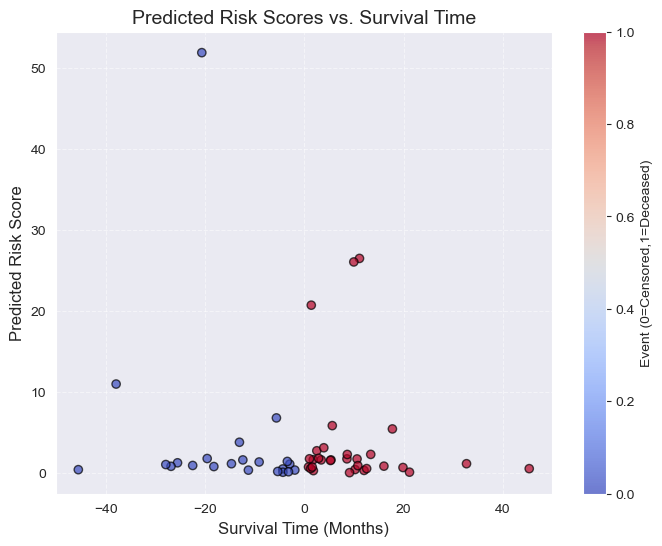

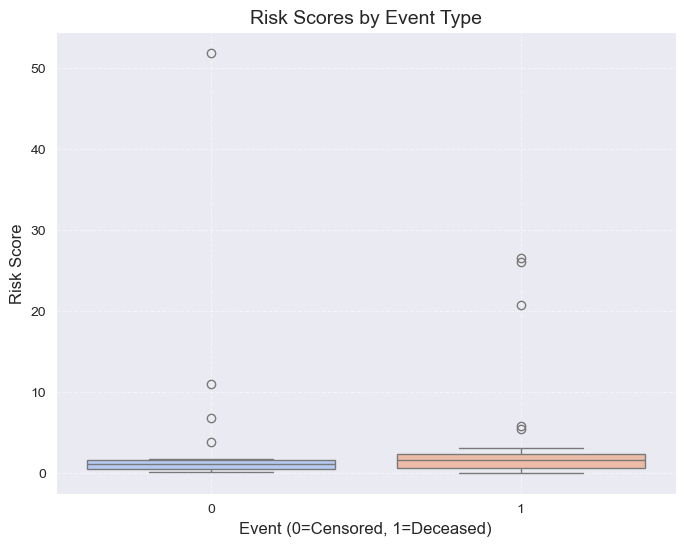

In [16]:
risk_scores_time_event_train = pd.DataFrame({
    "Risk Score": risk_scores_train,
    "Event": y_event_train,  # Event indicator (1=deceased, 0=censored)
    "Time": y_time_train     # Survival time
})

# Scatter plot: Risk scores vs. survival time, colored by event status
plt.figure(figsize=(8, 6))
plt.scatter(risk_scores_time_event_train["Time"], risk_scores_time_event_train["Risk Score"], c=risk_scores_time_event_train["Event"], 
            cmap="coolwarm", alpha=0.7, edgecolor="k", label="Event (0=Censored,1=Deceased)")
plt.colorbar(label="Event (0=Censored,1=Deceased)")
plt.title("Predicted Risk Scores vs. Survival Time", fontsize=14)
plt.xlabel("Survival Time (Months)", fontsize=12)
plt.ylabel("Predicted Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

# Box plot: Risk scores by event type
plt.figure(figsize=(8, 6))
sns.boxplot(x=risk_scores_time_event_train["Event"], y=risk_scores_time_event_train["Risk Score"], palette="coolwarm")
plt.title("Risk Scores by Event Type", fontsize=14)
plt.xlabel("Event (0=Censored, 1=Deceased)", fontsize=12)
plt.ylabel("Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

# SHAP values

<Axes: >

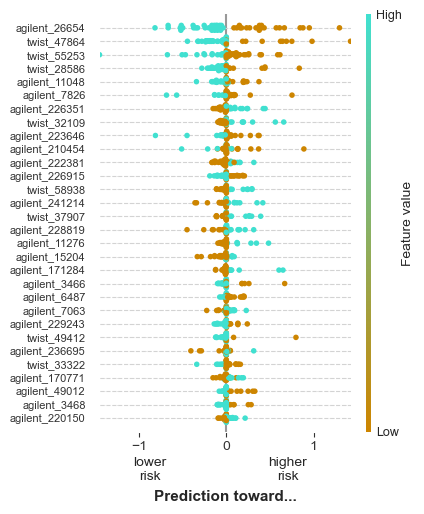

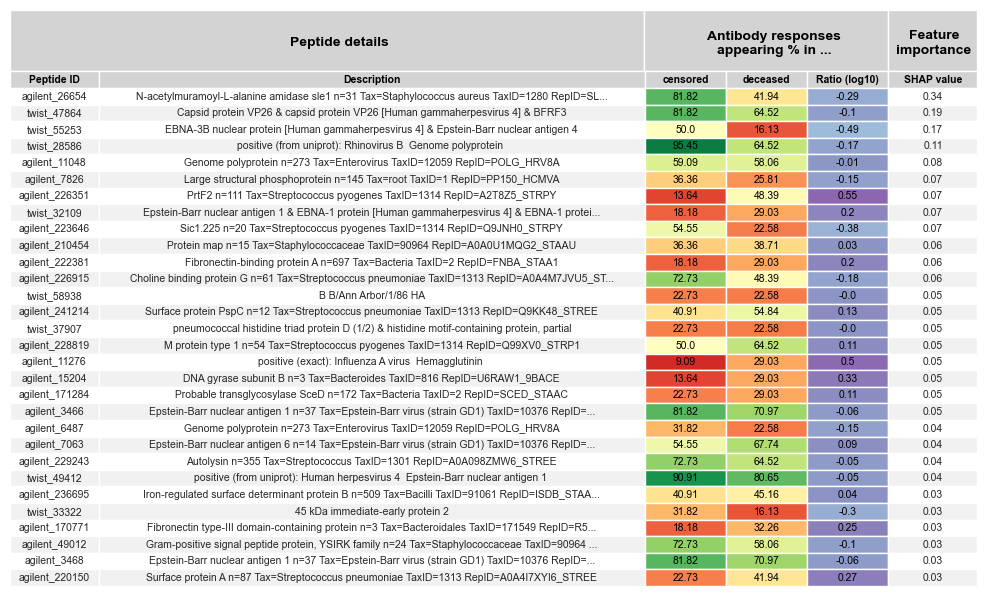

In [17]:
number_peptides = f"{X_train.shape[1]}"
plot_shap_values(train_shap_values, X_train.loc[all_validation_indices],
                 label_groups = ['lower\nrisk', 'higher\nrisk'], color_map=newCmap, max_display=30,
                 figures_dir = config.figures_dir, save_fig = True, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}')

oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]
y_event_train.name = config.col_target  # Naming the Series since it currently has no name
features_train = X_train.join(y_event_train).set_index(config.col_target, append=True)
feature_importance_train = generate_feature_importance_table(train_shap_values, X_train.columns, oligos_metadata, features_train, f'xgb_Cox-Hazard_trainingSet_{number_peptides}',
                                             group_tests = config.group_tests, figures_dir = config.figures_dir)
plot_table_top_features(feature_importance_train, 
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, estimator_name =f'xgb_Cox-Hazard_trainingSet_{number_peptides}', save_fig = True)

# Kaplan Meier Curve

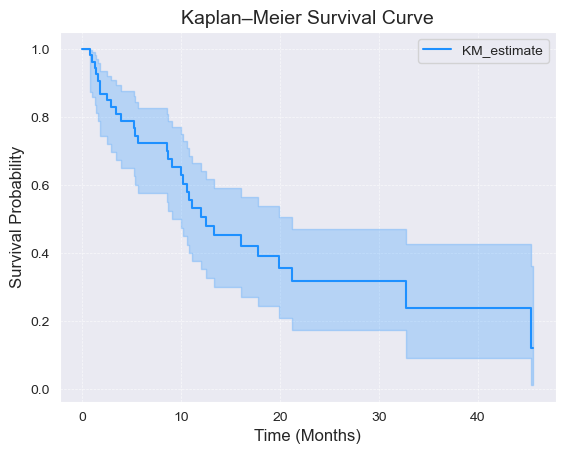

In [18]:
# Kaplan-Meier fitter from lifelines
kmf = KaplanMeierFitter()

# Fit the Kaplan-Meier estimator
kmf.fit(durations=np.abs(y_time_train), event_observed=y_event_train)
suffix='trainingSet_all'
# Plot the survival curve
kmf.plot_survival_function(ci_show=True, color="dodgerblue")
plt.title("Kaplan–Meier Survival Curve", fontsize=14)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig(Path(config.figures_dir) / f'Kaplan-Meier_{suffix}.png',
                    dpi=300, bbox_inches='tight')

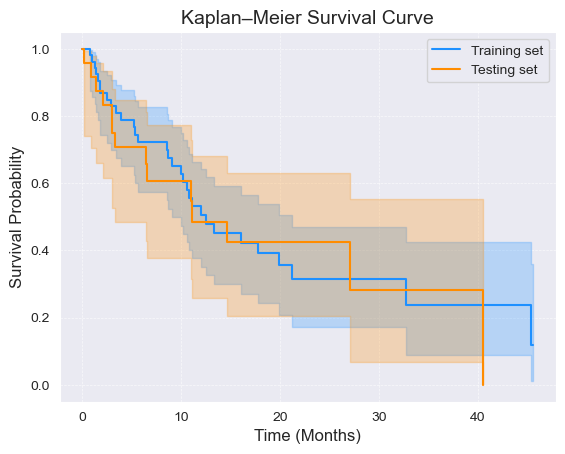

In [143]:
# Kaplan-Meier fitter from lifelines
kmf = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

# Fit the Kaplan-Meier estimator
kmf.fit(durations=np.abs(y_time_train), event_observed=y_event_train)
kmf2.fit(durations=np.abs(y_time_test), event_observed=y_event_test)

suffix="training-testing_all"
#suffix='trainingSet_all'
# Plot the survival curve
kmf.plot_survival_function(ci_show=True, color="dodgerblue", label="Training set")
kmf2.plot_survival_function(ci_show=True, color="darkorange", label="Testing set")
plt.title("Kaplan–Meier Survival Curve", fontsize=14)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig(f'/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/trainTest/figures_censored-deceased/Kaplan-Meier_{suffix}.png',
                    dpi=300, bbox_inches='tight')

## Time-Dependent AUC

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Time-Dependent AUC over Follow-up Time xgb_Cox-Hazard_trainingSet_425'}, xlabel='Time (Months)', ylabel='Time-Dependent AUC'>,
 <Axes: >)

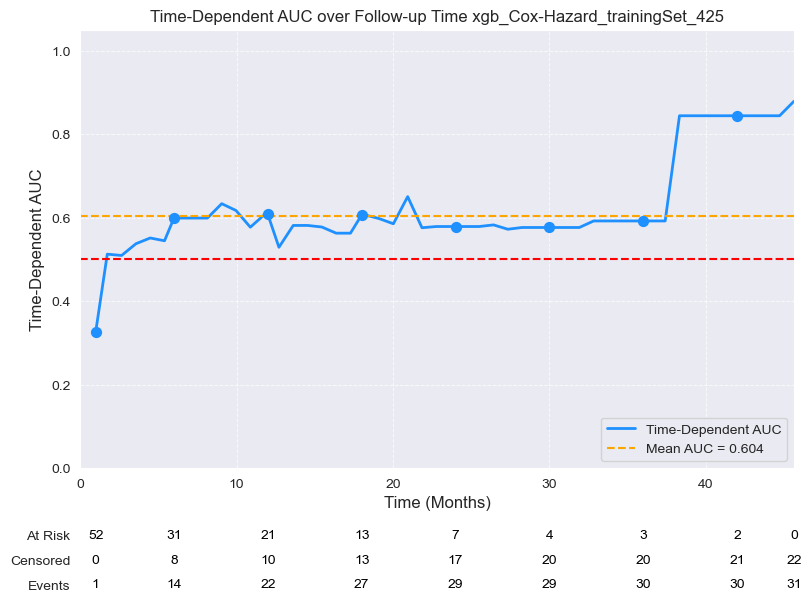

In [19]:
(auc_values_train, mean_auc_train, auc_values_highlight_train, 
 samples_at_risk_train, time_points_train, time_points_highlight_train) = calculate_time_dependent_auc(y_event_train, y_time_train,
                                 y_event_val_pred, y_time_val_pred, risk_scores_train, 
                                  time_points_highlight=None, num_points=50, buffer=0.001)
plot_time_dependent_auc_with_table(time_points_train, auc_values_train, mean_auc_train, samples_at_risk_train,
                        time_points_highlight=time_points_highlight_train, auc_values_highlight=auc_values_highlight_train,
                        figures_dir = config.figures_dir, save_fig=True, suffix_file =f'xgb_Cox-Hazard_trainingSet_{number_peptides}')

## Antigen Score

In [38]:
shap_values_train_df = pd.DataFrame({'SHAP value': np.abs(train_shap_values).mean(0)}, index=X_train.columns).sort_values(by='SHAP value', ascending=False)
shap_threshold_train = shap_values_train_df['SHAP value'].quantile(0.98)
top_peptides_train = shap_values_train_df.head(30).index
#top_peptides_train = shap_values_train_df[shap_values_train_df['SHAP value'] > shap_threshold_train].index

shap_values_train_df = pd.DataFrame(train_shap_values, columns=X_train.columns, index=all_validation_indices)
antigen_scores_time_event_train, antigen_threshold_train, shap_scaler_train, antigen_scaler_train = calculate_antigen_scores_scaled(shap_values_train_df, y_time_train.abs(), y_event_train, top_peptides_train, scaler=None, scaler_antigens=None, threshold=None, val_quantile=50, return_all = True)
antigen_scores_time_event_train

,OS months,OS Status,Antigen Score,Antigen Score (Scaled),Antigen Score (Dichotomized)
R14P01_40_HCC434_HCC_MUW_A_T_C2,1.775148,1,3.230266,0.881961,1
R14P01_55_HCC487_HCC_MUW_A_T_C2,1.939513,0,1.385983,0.654859,1
R14P01_78_HCC708_HCC_MUW_A_T_C2,13.116371,0,0.332379,0.525120,1
R14P01_57_HCC497_HCC_MUW_A_T_C2,3.221565,0,-2.081160,0.227920,0
R14P01_56_HCC492_HCC_MUW_A_T_C2,1.380671,1,4.188852,1.000000,1
R14P01_63_HCC570_HCC_MUW_A_T_C2,20.710059,0,4.183348,0.999322,1
R14P01_24_HCCAB_89_01_HCC_MUW_A_T_C2,5.358317,1,0.136398,0.500987,0
R14P01_66_HCC589_HCC_MUW_A_T_C2,13.379356,1,0.152545,0.502975,1
R14P01_03_LB_005_01_HCC_MUW_A_T_C2,45.364892,1,-0.885758,0.375120,0
R14P01_02_LB_004_02_HCC_MUW_A_T_C2,38.001315,0,1.604640,0.681784,1


## Testing Set

In [21]:
# Calling the function to train and evaluate
(estimator, importance_gain_test, importance_cover_test, importance_weight_test
 , test_shap_values, risk_scores_test, c_index_test) = train_and_evaluate_model(
    X_test, y_time_test, y_event_test,
    X_train=X_train, y_time_train=y_time_train,
    #estimator = model, 
    #params=params,
    param_grid=param_grid,
    #n_splits = 5,
    random_state = config.random_state)
#Concordance Index (C-index) testing set: 0.5554

Concordance Index (C-index) testing set: 0.5554


<Axes: >

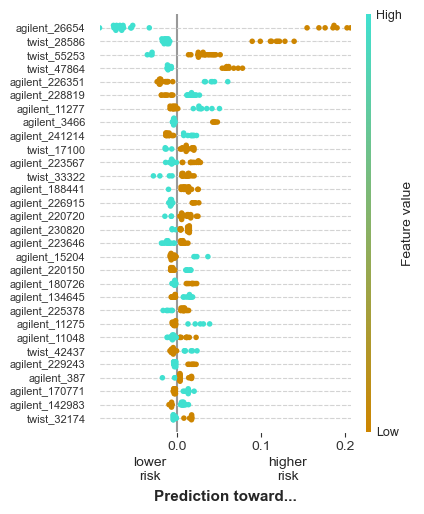

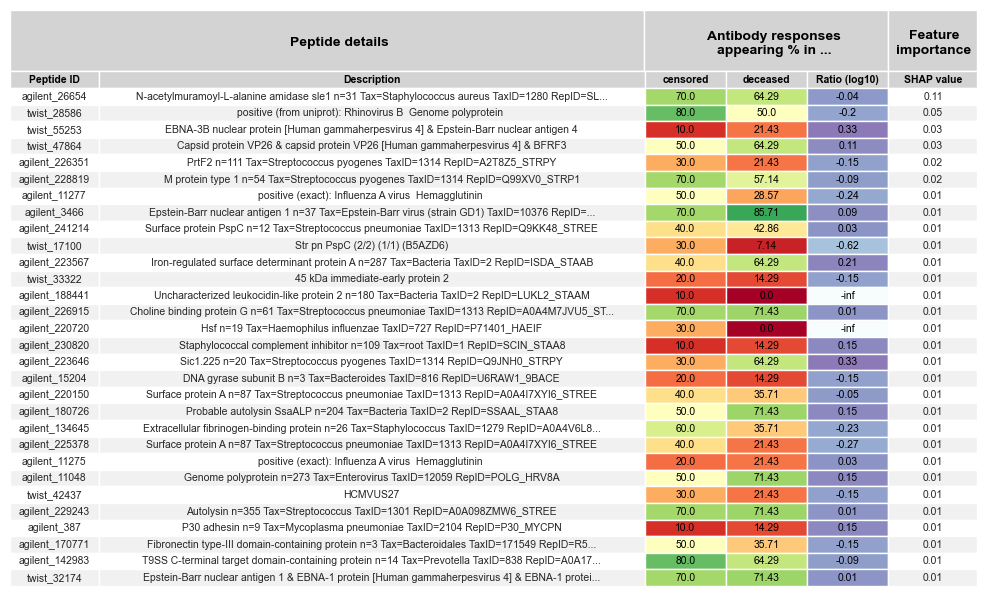

In [22]:
# Plot shap values
plot_shap_values(test_shap_values, X_test,
                 label_groups=['lower\nrisk', 'higher\nrisk'], color_map=newCmap, max_display=30,
                 figures_dir=config.figures_dir, save_fig = True, suffix_file=f'xgb_Cox-Hazard_testingSet_{number_peptides}')

y_event_test.name = config.col_target  # Naming the Series since it currently has no name
features_test = X_test.join(y_event_test).set_index(config.col_target, append=True)

feature_importance_test = generate_feature_importance_table(test_shap_values, 
                                                          X_test.columns, oligos_metadata,
                                                          features_test,
                                                          f'xgb_Cox-Hazard_testingSet_{number_peptides}',
                                                          group_tests = config.group_tests,
                                                          figures_dir = config.figures_dir)
plot_table_top_features(feature_importance_test,
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, estimator_name =f'xgb_Cox-Hazard_testingSet_{number_peptides}', save_fig = True)

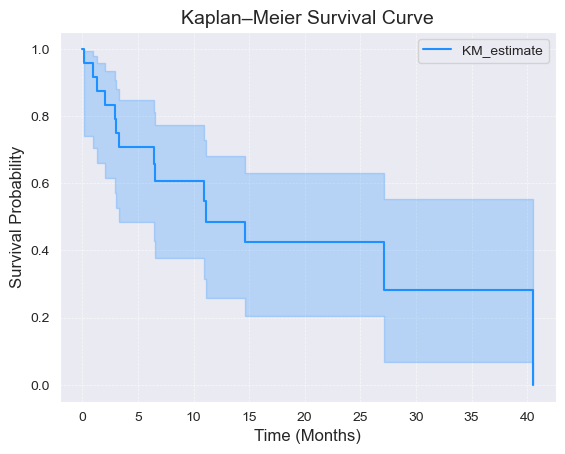

In [23]:
# Take the absolute values of y_time_test for Kaplan-Meier analysis
survival_times = np.abs(y_time_test)

# Kaplan-Meier fitter from lifelines
kmf = KaplanMeierFitter()

# Fit the Kaplan-Meier estimator
kmf.fit(durations=survival_times, event_observed=y_event_test)
suffix='testingSet_all'
# Plot the survival curve
kmf.plot_survival_function(ci_show=True, color="dodgerblue")
plt.title("Kaplan–Meier Survival Curve", fontsize=14)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig(Path(config.figures_dir) / f'Kaplan-Meier_{suffix}.png',
                    dpi=300, bbox_inches='tight')

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Time-Dependent AUC over Follow-up Time xgb_Cox-Hazard_testingSet_425'}, xlabel='Time (Months)', ylabel='Time-Dependent AUC'>,
 <Axes: >)

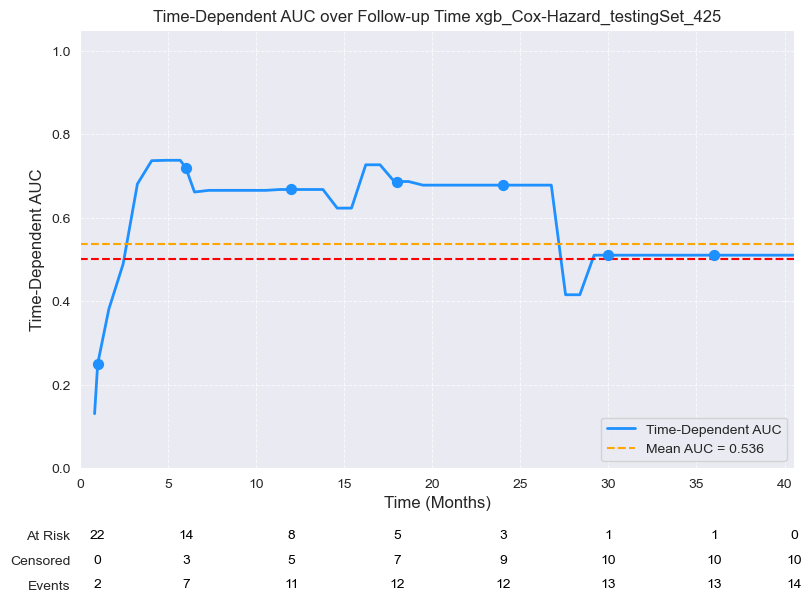

In [24]:
(auc_values_test, mean_auc_test, auc_values_highlight_test, 
 samples_at_risk_test, time_points_test, time_points_highlight_test) = calculate_time_dependent_auc(y_event_train, y_time_train, 
                                 y_event_test , y_time_test, risk_scores_test, 
                                  time_points_highlight=None, num_points=50, buffer=0.001)
plot_time_dependent_auc_with_table(time_points_test, auc_values_test, mean_auc_test, samples_at_risk_test,
                        time_points_highlight=time_points_highlight_test, auc_values_highlight=auc_values_highlight_test,
                        figures_dir = config.figures_dir, save_fig=True, suffix_file =f'xgb_Cox-Hazard_testingSet_{number_peptides}')

In [39]:
shap_values_test_df = pd.DataFrame(test_shap_values, columns=X_test.columns, index=X_test.index)
antigen_scores_time_event_test = calculate_antigen_scores_scaled(shap_values_test_df, y_time_test.abs(), y_event_test, top_peptides_train, scaler=shap_scaler_train, scaler_antigens=antigen_scaler_train, threshold=antigen_threshold_train, return_all = False)
antigen_scores_time_event_test

,OS months,OS Status,Antigen Score,Antigen Score (Scaled),Antigen Score (Dichotomized)
SampleName,,,,,
R14P01_54_HCC486_HCC_MUW_A_T_C2,6.508876,1,0.204710,0.509399,1
R14P01_15_HCCAB_59_01_HCC_MUW_A_T_C2,4.700855,0,0.295802,0.520616,1
R14P01_33_HCC25_HCC_MUW_A_T_C2,40.532544,1,0.286600,0.519482,1
R14P01_77_HCC693_HCC_MUW_A_T_C2,5.752794,0,0.211444,0.510228,1
R14P01_23_HCCAB_80_02_HCC_MUW_A_T_C2,6.410256,1,0.052109,0.490608,0
R14P01_11_HCCAB_39_01_HCC_MUW_A_T_C2,0.920447,1,0.128536,0.500019,0
R14P01_71_HCC681_HCC_MUW_A_T_C2,1.347798,1,0.175740,0.505831,1
R14P01_61_HCC558_HCC_MUW_A_T_C2,17.685733,0,0.022059,0.486907,0
R14P01_58_HCC531_HCC_MUW_A_T_C2,10.979619,1,0.327266,0.524490,1


# Distributions of risk score in training and test/external Set

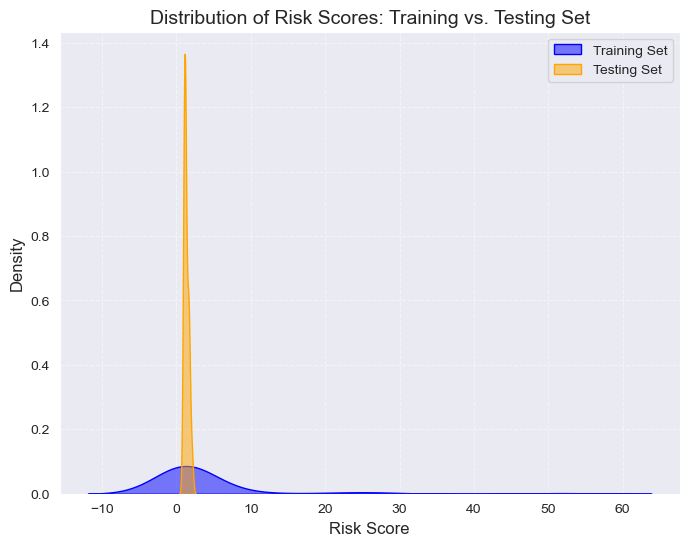

In [33]:
plt.figure(figsize=(8, 6))
sns.kdeplot(risk_scores_train, label="Training Set", color="blue", fill=True, alpha=0.5)
sns.kdeplot(risk_scores_test, label="Testing Set", color="orange", fill=True, alpha=0.5)
plt.title("Distribution of Risk Scores: Training vs. Testing Set", fontsize=14)
plt.xlabel("Risk Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(alpha=0.5, linestyle="--")

# Kaplan Meier Curve

Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_xgb_Cox-Hazard_trainingSet_425.png
Log-Rank Test p-value: 0.1773
Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_xgb_Cox-Hazard_testingSet_425.png
Log-Rank Test p-value: 0.5177


0.517735110403484

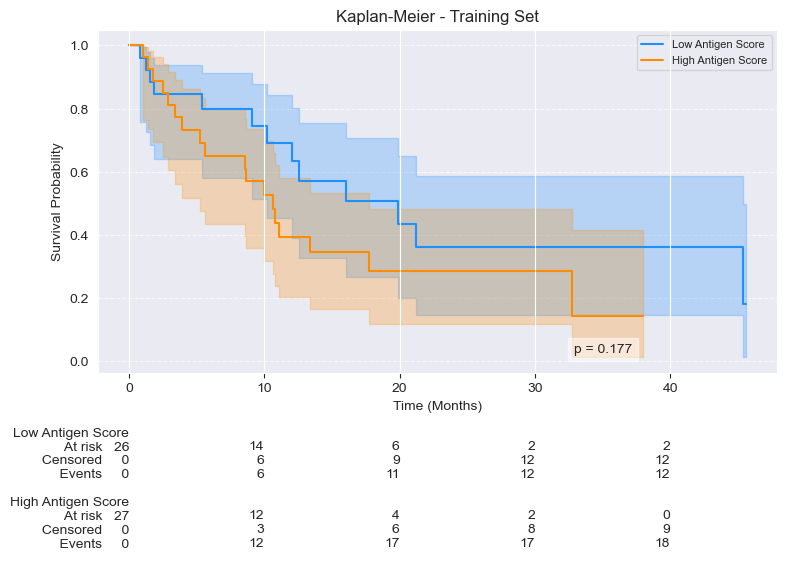

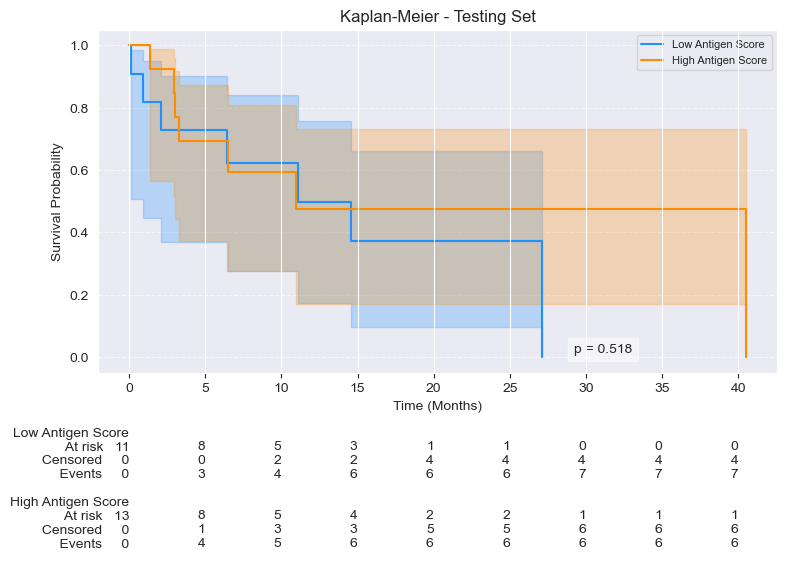

In [40]:
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - Training Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

# Plot for Testing Set
plot_kaplan_meier(antigen_scores_time_event_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - Testing Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'xgb_Cox-Hazard_testingSet_{number_peptides}')
# Perform log-rank test for External Set
perform_logrank_test(antigen_scores_time_event_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

# Coxnet Survival Analysis

In [41]:
def cindex_scorer(y_true, y_pred):
    return concordance_index_ipcw(y_true, y_true, y_pred)[0]
scorer = make_scorer(cindex_scorer, greater_is_better=True)

# Expanded parameter grid
param_grid = {
    "l1_ratio": [0.1, 0.5, 0.7, 1.0],  # Include values between Ridge-like (0) and LASSO-like (1.0)
    "alpha_min_ratio": [0.001, 0.01, 0.1],  # Different levels of penalty aggressiveness
    "n_alphas": [50, 100, 200]  # Test with fewer or more alphas
}

X_train_cox = X_train
y_train_cox = Surv.from_arrays(event=y_event_train.astype(bool),
                            time=y_time_train.abs())

# Initialize risk_scores to hold predictions for all samples
risk_scores_train_cox = pd.Series(index=X_train_cox.index, name='Risk score coxnet')
coefficients_list = []

#kf_outer = KFold(n_splits=10, shuffle=True, random_state=420)
kf_outer = CustomStratifiedKFold(n_splits=10, shuffle=True, random_state=420)
for train_index, val_index in kf_outer.split(X_train_cox, y_train_cox):
    # Split data into training and validation sets
    features, X_val = X_train_cox.iloc[train_index], X_train_cox.iloc[val_index]
    target, y_val = y_train_cox[train_index], y_train_cox[val_index]

    model = CoxnetSurvivalAnalysis()

    # Inner loop: Perform hyperparameter tuning with GridSearchCV
    #kf_inner = KFold(n_splits=5, shuffle=True, random_state=420)
    kf_inner = CustomStratifiedKFold(n_splits=5, shuffle=True, random_state=420)
    gcv = GridSearchCV(model, param_grid, scoring=scorer, cv=kf_inner, verbose=1)
    gcv.fit(features, target)

    # Get the best model from GridSearchCV
    best_model = gcv.best_estimator_

    # Predict risk scores for the validation set
    #risk_scores[val_index] = best_model.predict(X_val)
    risk_scores_train_cox.iloc[val_index] = best_model.predict(X_val)
    
    # Save coefficients for the best model
    optimal_coefficients = best_model.coef_[:, -1]  # Using the last alpha (most regularized)
    coefficients_list.append(optimal_coefficients)
        

# Aggregate results
# Calculate c-index using all risk scores
#c_index_train_cox = concordance_index_censored(y_train_cox["event"], y_train_cox["time"], risk_scores_train_cox)[0]  # Extract the c-index value
c_index_train_cox = concordance_index_ipcw(y_train_cox, y_train_cox, risk_scores_train_cox)[0]  # Extract the c-index value

print(f"Overall C-Index: {c_index_train_cox:.4f}")

# Convert list of coefficients into a NumPy array
coefficients_matrix_train_cox = np.array(coefficients_list)  # Shape: (n_folds, n_features)
#Overall C-Index: 0.5526

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Overall C-Index: 0.5526


In [92]:
mean_coefficients_train_cox = np.mean(np.abs(coefficients_matrix_train_cox), axis=0)
#mean_coefficients_train_cox = np.mean(coefficients_matrix_train_cox, axis=0)
top_indices_train_cox = np.argsort(mean_coefficients_train_cox)[-30:][::-1]
top_peptides_train_cox = X_train_cox.columns[top_indices_train_cox]
selected_features_train_cox = X_train_cox.iloc[:, top_indices_train_cox]

# Calculate the mean coefficients (retain signs)
mean_coefficients_train_cox = np.mean(coefficients_matrix_train_cox, axis=0)
#scaler_coxnet = MinMaxScaler(feature_range=(0, 1))
#selected_coefficients_train_cox = scaler_coxnet.fit_transform(mean_coefficients_train_cox[top_indices_train_cox].reshape(-1,1)).reshape(30,)
#selected_coefficients_train_cox = scaler_coxnet.fit_transform(mean_coefficients_train_cox.reshape(-1,1))[top_indices_train_cox].reshape(30,)

#antigen_scores_train_cox = selected_features_train_cox @ selected_coefficients_train_cox
antigen_scores_train_cox = selected_features_train_cox @ mean_coefficients_train_cox[top_indices_train_cox]

scaler_antigen_coxnet = MinMaxScaler(feature_range=(0, 1))
antigen_scores_scaled_train_cox = scaler_antigen_coxnet.fit_transform(antigen_scores_train_cox.to_frame())
antigen_scores_train_cox_df = pd.DataFrame(antigen_scores_train_cox, columns=['Antigen Score coxnet'])
antigen_scores_train_cox_df['Antigen Score coxnet (Scaled)'] = antigen_scores_scaled_train_cox

threshold_coxnet_train_cox = np.quantile(antigen_scores_scaled_train_cox, 50/100)
antigen_scores_train_cox_df['Antigen Score coxnet (Dichotomized)'] = (antigen_scores_scaled_train_cox > threshold_coxnet_train_cox).astype(int)

antigen_scores_time_event_train_cox = pd.merge(y_time_train.abs(), y_event_train, left_index=True, right_index=True)
antigen_scores_time_event_train_cox = pd.merge(antigen_scores_time_event_train_cox, antigen_scores_train_cox_df, left_index=True, right_index=True)

/tmp/ipykernel_438091/2915538790.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=risk_scores_time_event_train_cox["Event"], y=risk_scores_time_event_train_cox["Risk Score"], palette="coolwarm")


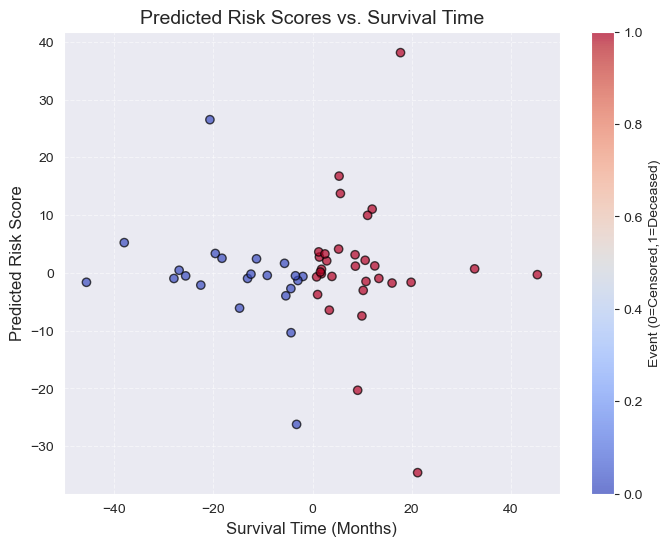

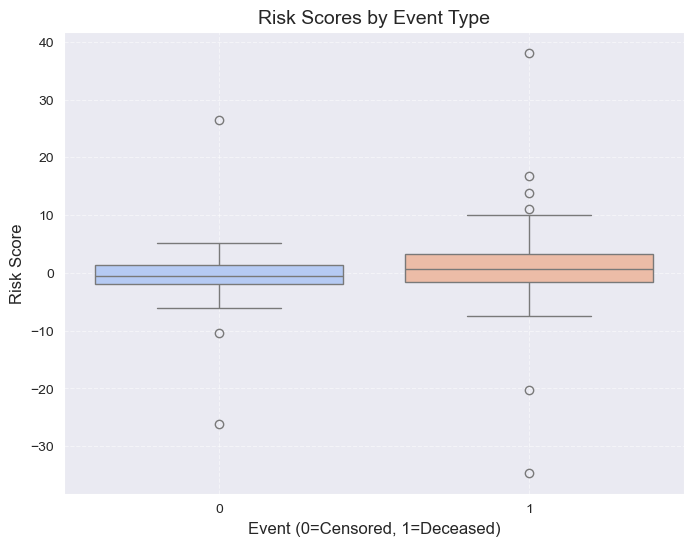

In [43]:
risk_scores_time_event_train_cox = pd.DataFrame({
    "Risk Score": risk_scores_train_cox,
    "Event": y_event_train,  # Event indicator (1=deceased, 0=censored)
    "Time": y_time_train     # Survival time
})

# Scatter plot: Risk scores vs. survival time, colored by event status
plt.figure(figsize=(8, 6))
plt.scatter(risk_scores_time_event_train_cox["Time"], risk_scores_time_event_train_cox["Risk Score"], c=risk_scores_time_event_train_cox["Event"], 
            cmap="coolwarm", alpha=0.7, edgecolor="k", label="Event (0=Censored,1=Deceased)")
plt.colorbar(label="Event (0=Censored,1=Deceased)")
plt.title("Predicted Risk Scores vs. Survival Time", fontsize=14)
plt.xlabel("Survival Time (Months)", fontsize=12)
plt.ylabel("Predicted Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

# Box plot: Risk scores by event type
plt.figure(figsize=(8, 6))
sns.boxplot(x=risk_scores_time_event_train_cox["Event"], y=risk_scores_time_event_train_cox["Risk Score"], palette="coolwarm")
plt.title("Risk Scores by Event Type", fontsize=14)
plt.xlabel("Event (0=Censored, 1=Deceased)", fontsize=12)
plt.ylabel("Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Time-Dependent AUC over Follow-up Time coxNet_trainingSet_425'}, xlabel='Time (Months)', ylabel='Time-Dependent AUC'>,
 <Axes: >)

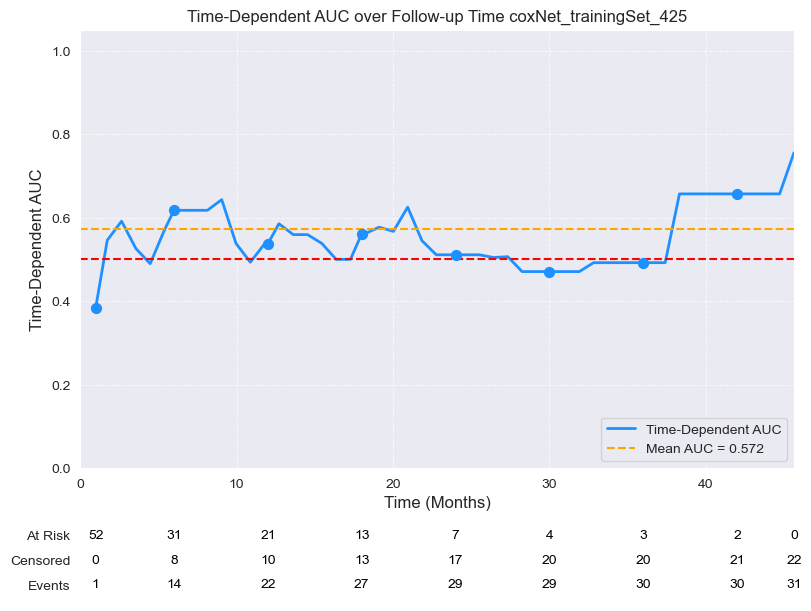

In [44]:
(auc_values_train_cox, mean_auc_train_cox, auc_values_highlight_train_cox,
 samples_at_risk_train_cox, time_points_train_cox, time_points_highlight_train_cox) = calculate_time_dependent_auc(y_event_train,
                                                                                                 y_time_train,
                                                                                                 y_event_train,
                                                                                                 y_time_train,
                                                                                                 risk_scores_train_cox,
                                                                                                 time_points_highlight=None,
                                                                                                 num_points=50,
                                                                                                 buffer=0.001)
plot_time_dependent_auc_with_table(time_points_train_cox, auc_values_train_cox, mean_auc_train_cox, samples_at_risk_train_cox,
                                       time_points_highlight=time_points_highlight_train_cox,
                                       auc_values_highlight=auc_values_highlight_train_cox,
                                       figures_dir=config.figures_dir, save_fig=True, suffix_file=f'coxNet_trainingSet_{number_peptides}')

In [45]:
model = CoxnetSurvivalAnalysis()
# Expanded parameter grid
param_grid = {
    "l1_ratio": [0.1, 0.5, 0.7, 1.0],  # Include values between Ridge-like (0) and LASSO-like (1.0)
    "alpha_min_ratio": [0.001, 0.01, 0.1],  # Different levels of penalty aggressiveness
    "n_alphas": [50, 100, 200]  # Test with fewer or more alphas
}
# Perform GridSearchCV on the full training set
kf = CustomStratifiedKFold(n_splits=5, shuffle=True, random_state=420)
gcv = GridSearchCV(model, param_grid, scoring=scorer, cv=kf, verbose=1)
gcv.fit(X_train_cox, y_train_cox)

# Retrieve the best model
final_model = gcv.best_estimator_
print("Best Parameters:", gcv.best_params_)
print("Best Training C-Index:", gcv.best_score_)

# Then you can do a coxph-like analysis or evaluate c-index on test_cox, e.g.:
y_test_cox = Surv.from_arrays(event=y_event_test,
                             time=y_time_test.abs())

# Predict risk scores for the external test set
risk_scores_test_cox = final_model.predict(X_test)
#c_index_test_cox = concordance_index_censored(y_test_cox["event"], y_test_cox["time"], risk_scores_test_cox)[0]
c_index_test_cox = concordance_index_ipcw(y_train_cox, y_test_cox, risk_scores_test_cox)[0]  # Extract the c-index value

print(f"C-Index on Test Set: {c_index_test_cox:.4f}")
risk_scores_test_cox = pd.Series(risk_scores_test_cox, index=X_test.index, name="Risk score coxnet")

optimal_coefficients_test_cox = final_model.coef_[:, -1]  # Using the last alpha (most regularized)
#C-Index on Test Set: 0.5448

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'alpha_min_ratio': 0.1, 'l1_ratio': 0.7, 'n_alphas': 50}
Best Training C-Index: 0.5641254490878846
C-Index on Test Set: 0.5448


In [93]:
selected_features_test_cox = X_test[top_peptides_train_cox]
#scaler_coxnet = MinMaxScaler(feature_range=(0, 1))
#selected_coefficients_test_cox = scaler_coxnet.fit_transform(optimal_coefficients_test_cox[X_test.columns.get_indexer(top_peptides_train_cox)].reshape(-1,1)).reshape(30,)
#selected_coefficients_test_cox = scaler_coxnet.transform(optimal_coefficients_test_cox.reshape(-1,1))[X_test.columns.get_indexer(top_peptides_train_cox)].reshape(30,)
#selected_coefficients_test_cox = np.clip(selected_coefficients_test_cox, 0, 1)

#antigen_scores_test_cox = selected_features_test_cox @ selected_coefficients_test_cox
antigen_scores_test_cox = selected_features_test_cox @ optimal_coefficients_test_cox[X_test.columns.get_indexer(top_peptides_train_cox)]

scaler_antigen_coxnet = MinMaxScaler(feature_range=(0, 1))
antigen_scores_scaled_test_cox = scaler_antigen_coxnet.fit_transform(antigen_scores_test_cox.to_frame())
#antigen_scores_scaled_test_cox = np.clip(antigen_scores_scaled_test_cox, 0, 1)
antigen_scores_test_cox_df = pd.DataFrame(antigen_scores_test_cox, columns=['Antigen Score coxnet'])
antigen_scores_test_cox_df['Antigen Score coxnet (Scaled)'] = antigen_scores_scaled_test_cox
antigen_scores_test_cox_df['Antigen Score coxnet (Dichotomized)'] = (antigen_scores_scaled_test_cox > threshold_coxnet_train_cox).astype(int)

antigen_scores_time_event_test_cox = pd.merge(y_time_test.abs(), y_event_test, left_index=True, right_index=True)
antigen_scores_time_event_test_cox = pd.merge(antigen_scores_time_event_test_cox, antigen_scores_test_cox_df, left_index=True, right_index=True)

/tmp/ipykernel_438091/3033784132.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=risk_scores_time_event_test_cox["Event"], y=risk_scores_time_event_test_cox["Risk Score"], palette="coolwarm")


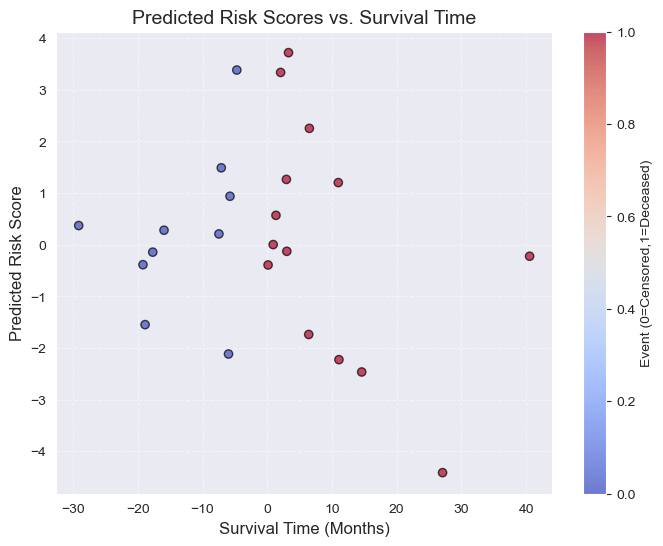

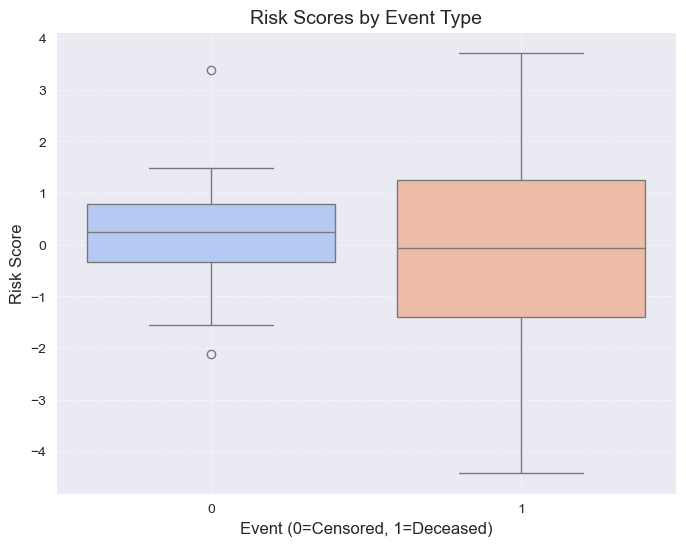

In [47]:
risk_scores_time_event_test_cox = pd.DataFrame({
    "Risk Score": risk_scores_test_cox,
    "Event": y_event_test,  # Event indicator (1=deceased, 0=censored)
    "Time": y_time_test     # Survival time
})

# Scatter plot: Risk scores vs. survival time, colored by event status
plt.figure(figsize=(8, 6))
plt.scatter(risk_scores_time_event_test_cox["Time"], risk_scores_time_event_test_cox["Risk Score"], c=risk_scores_time_event_test_cox["Event"], 
            cmap="coolwarm", alpha=0.7, edgecolor="k", label="Event (0=Censored,1=Deceased)")
plt.colorbar(label="Event (0=Censored,1=Deceased)")
plt.title("Predicted Risk Scores vs. Survival Time", fontsize=14)
plt.xlabel("Survival Time (Months)", fontsize=12)
plt.ylabel("Predicted Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

# Box plot: Risk scores by event type
plt.figure(figsize=(8, 6))
sns.boxplot(x=risk_scores_time_event_test_cox["Event"], y=risk_scores_time_event_test_cox["Risk Score"], palette="coolwarm")
plt.title("Risk Scores by Event Type", fontsize=14)
plt.xlabel("Event (0=Censored, 1=Deceased)", fontsize=12)
plt.ylabel("Risk Score", fontsize=12)
plt.grid(alpha=0.5, linestyle="--")

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Time-Dependent AUC over Follow-up Time coxNet_testingSet_425'}, xlabel='Time (Months)', ylabel='Time-Dependent AUC'>,
 <Axes: >)

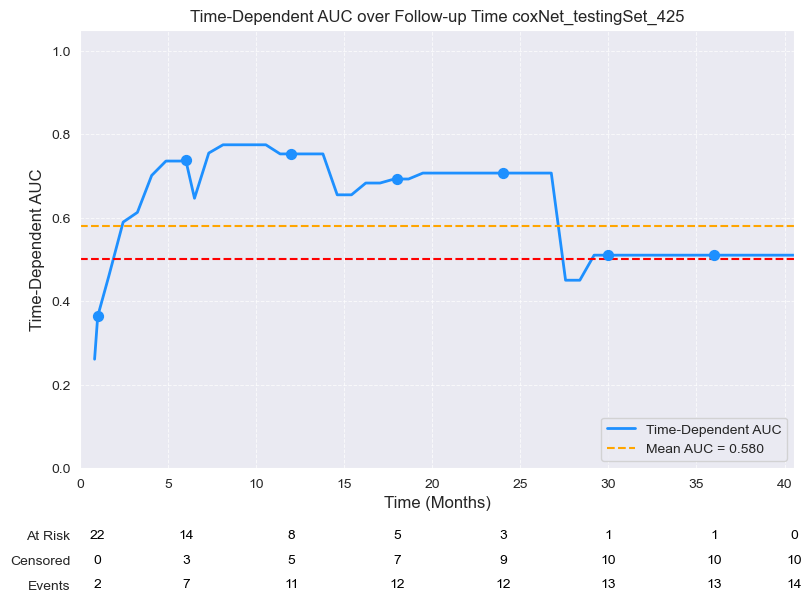

In [48]:
(auc_values_test_cox, mean_auc_test_cox, auc_values_highlight_test_cox,
 samples_at_risk_test_cox, time_points_test_cox, time_points_highlight_test_cox) = calculate_time_dependent_auc(y_event_train,
                                                                                                 y_time_train,
                                                                                                 y_event_test,
                                                                                                 y_time_test,
                                                                                                 risk_scores_test_cox,
                                                                                                 time_points_highlight=None,
                                                                                                 num_points=50,
                                                                                                 buffer=0.001)
plot_time_dependent_auc_with_table(time_points_test_cox, auc_values_test_cox, mean_auc_test_cox, samples_at_risk_test_cox,
                                       time_points_highlight=time_points_highlight_test_cox,
                                       auc_values_highlight=auc_values_highlight_test_cox,
                                       figures_dir=config.figures_dir, save_fig=True, suffix_file=f'coxNet_testingSet_{number_peptides}')

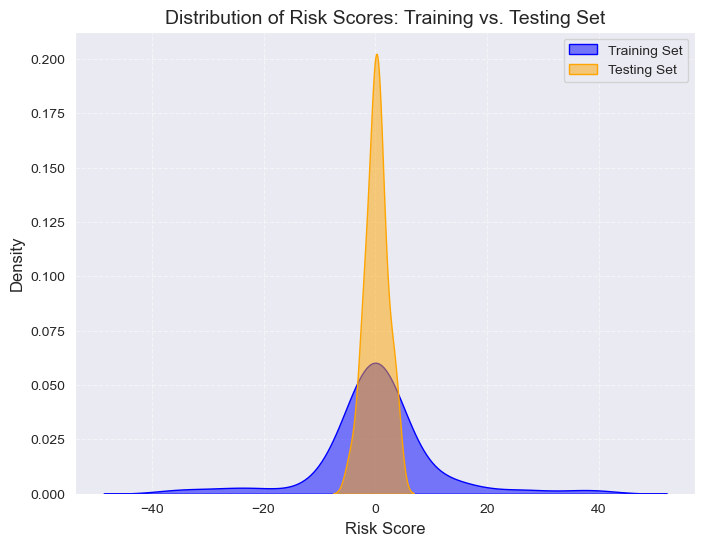

In [49]:
plt.figure(figsize=(8, 6))
sns.kdeplot(risk_scores_train_cox, label="Training Set", color="blue", fill=True, alpha=0.5)
sns.kdeplot(risk_scores_test_cox, label="Testing Set", color="orange", fill=True, alpha=0.5)
plt.title("Distribution of Risk Scores: Training vs. Testing Set", fontsize=14)
plt.xlabel("Risk Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(alpha=0.5, linestyle="--")

Text(0, 0.5, 'Frequency')

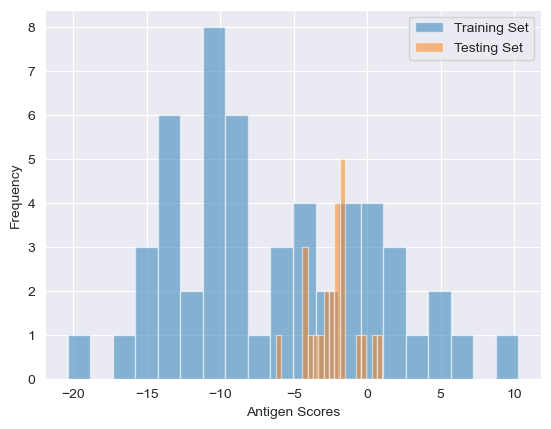

In [50]:
# Plot antigen score distributions
plt.hist(antigen_scores_train_cox, bins=20, alpha=0.5, label='Training Set')
plt.hist(antigen_scores_test_cox, bins=20, alpha=0.5, label='Testing Set')
#plt.axvline(training_threshold, color='red', linestyle='dashed', label='Training Threshold')
plt.legend()
plt.xlabel('Antigen Scores')
plt.ylabel('Frequency')

Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_coxnet_trainingSet_425.png
Log-Rank Test p-value: 0.0000
Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_coxnet_testingSet_425.png
Log-Rank Test p-value: 0.8882


0.8881584238718501

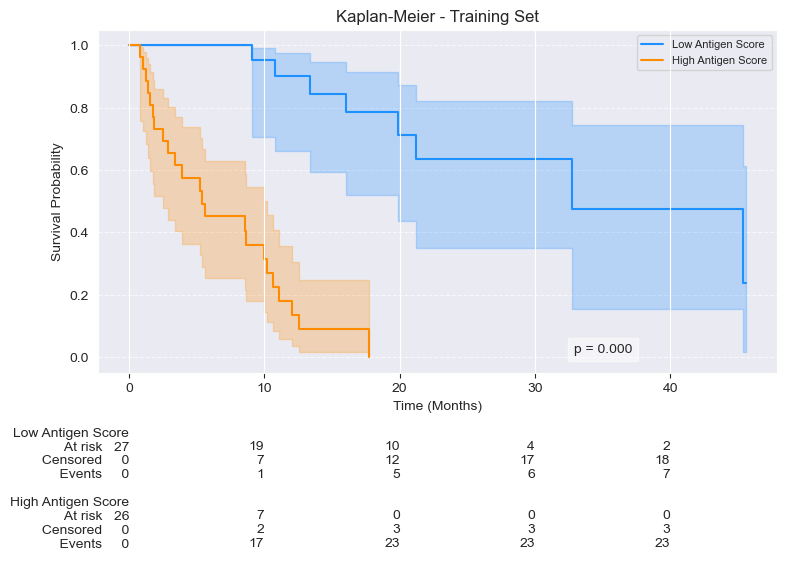

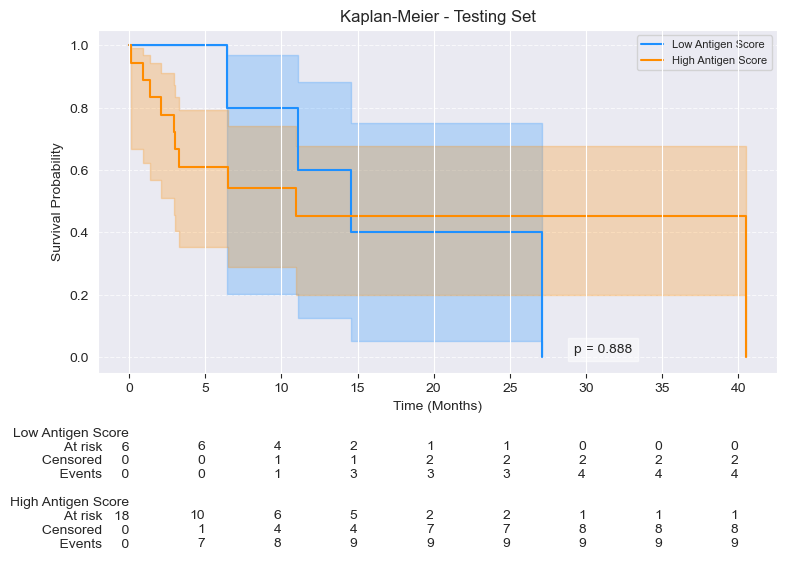

In [94]:
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_train_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)', labels,
                  title="Kaplan-Meier - Training Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'coxnet_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_train_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)')

# Plot for test_cox (External) Set
plot_kaplan_meier(antigen_scores_time_event_test_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)', labels,
                  title="Kaplan-Meier - Testing Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'coxnet_testingSet_{number_peptides}')
# Perform log-rank test for External Set
perform_logrank_test(antigen_scores_time_event_test_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)')

 ## Intersect Top Peptides Both Models

In [99]:
# Experiment to use intersection between xgb cox-survival model and coxnet
top_peptides_intersection = top_peptides_train.intersection(top_peptides_train_cox)

antigen_scores_time_event_intersection_train, antigen_threshold_intersection_train, shap_scaler_intersection_train, antigen_scaler_intersection_train = calculate_antigen_scores_scaled(shap_values_train_df, y_time_train.abs(), y_event_train, top_peptides_intersection, scaler=None, scaler_antigens=None, threshold=None, val_quantile=45, return_all = True)

antigen_scores_time_event_intersection_test = calculate_antigen_scores_scaled(shap_values_test_df, y_time_test.abs(), y_event_test, top_peptides_intersection, scaler=shap_scaler_intersection_train, scaler_antigens=antigen_scaler_intersection_train, threshold=antigen_threshold_intersection_train, val_quantile=45, return_all = False)

Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_intersection_xgb_Cox-Hazard_trainingSet_425.png
Log-Rank Test p-value: 0.0341
Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_intersection_xgb_Cox-Hazard_testingSet_425.png
Log-Rank Test p-value: 0.9655


0.9654508474981929

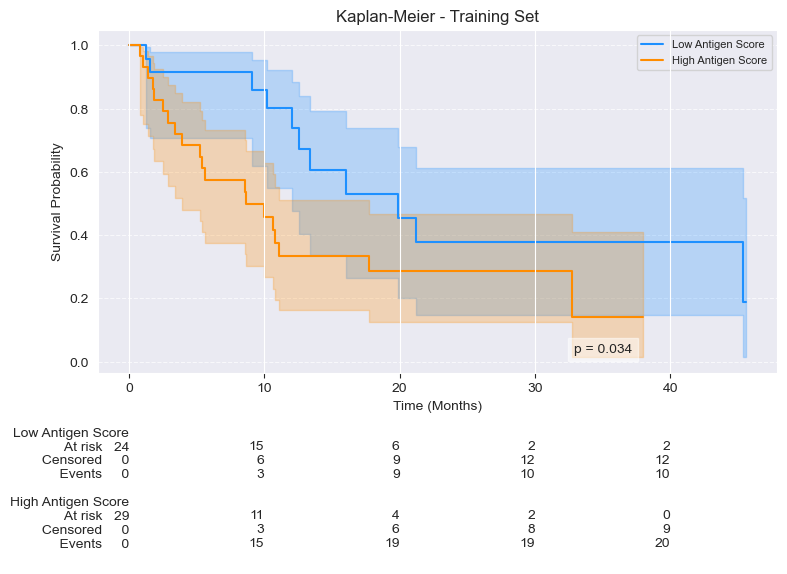

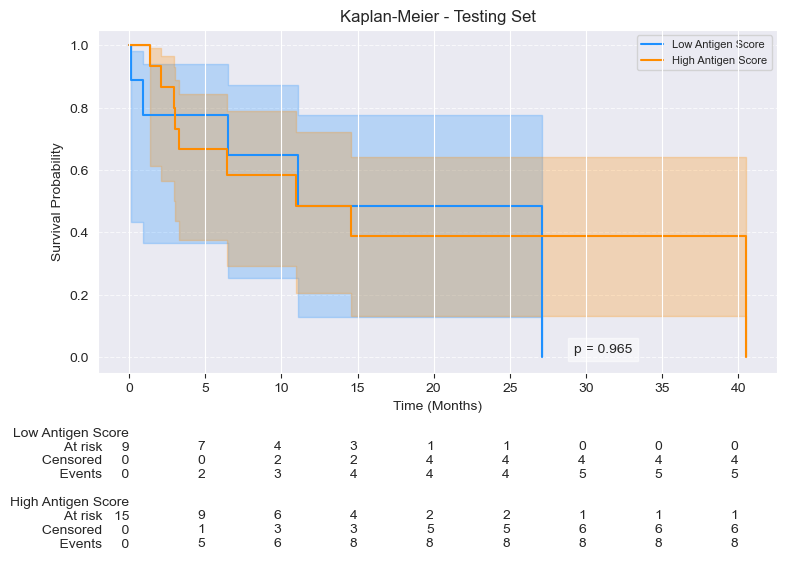

In [100]:
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_intersection_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - Training Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'intersection_xgb_Cox-Hazard_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_intersection_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

# Plot for Testing Set
plot_kaplan_meier(antigen_scores_time_event_intersection_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - Testing Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'intersection_xgb_Cox-Hazard_testingSet_{number_peptides}')
# Perform log-rank test for External Set
perform_logrank_test(antigen_scores_time_event_intersection_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

In [101]:
# Configure the transformer to output a pandas DataFrame
selected_features_intersection_train_cox = X_train_cox[top_peptides_intersection]
antigen_scores_intersection_train_cox = selected_features_intersection_train_cox @ mean_coefficients_train_cox[X_train_cox.columns.get_indexer(top_peptides_intersection)]
#scaler_coxnet = StandardScaler()
scaler_antigen_intersection_coxnet = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the data
antigen_scores_scaled_intersection_train_cox = scaler_antigen_intersection_coxnet.fit_transform(antigen_scores_intersection_train_cox.to_frame())
antigen_scores_intersection_train_cox_df = pd.DataFrame(antigen_scores_intersection_train_cox, columns=['Antigen Score coxnet'])
antigen_scores_intersection_train_cox_df['Antigen Score coxnet (Scaled)'] = antigen_scores_scaled_intersection_train_cox


threshold_coxnet_intersection_train_cox = np.quantile(antigen_scores_scaled_intersection_train_cox, 45/100)
antigen_scores_intersection_train_cox_df['Antigen Score coxnet (Dichotomized)'] = (antigen_scores_scaled_intersection_train_cox > threshold_coxnet_intersection_train_cox).astype(int)

antigen_scores_time_event_intersection_train_cox = pd.merge(y_time_train.abs(), y_event_train, left_index=True, right_index=True)
antigen_scores_time_event_intersection_train_cox = pd.merge(antigen_scores_time_event_intersection_train_cox, antigen_scores_intersection_train_cox_df, left_index=True, right_index=True)

#####
selected_features_intersection_test_cox = X_test[top_peptides_intersection]
antigen_scores_intersection_test_cox = selected_features_intersection_test_cox @ optimal_coefficients_test_cox[X_test.columns.get_indexer(top_peptides_intersection)]

scaler_antigen_intersection_coxnet = MinMaxScaler(feature_range=(0, 1)) #optimal not needed

antigen_scores_scaled_intersection_test_cox = scaler_antigen_intersection_coxnet.fit_transform(antigen_scores_intersection_test_cox.to_frame()) #optimal not needed
antigen_scores_intersection_test_cox_df = pd.DataFrame(antigen_scores_intersection_test_cox, columns=['Antigen Score coxnet'])
antigen_scores_intersection_test_cox_df['Antigen Score coxnet (Scaled)'] = antigen_scores_scaled_intersection_test_cox
antigen_scores_intersection_test_cox_df['Antigen Score coxnet (Dichotomized)'] = (antigen_scores_scaled_intersection_test_cox > threshold_coxnet_intersection_train_cox).astype(int)

antigen_scores_time_event_intersection_test_cox = pd.merge(y_time_test.abs(), y_event_test, left_index=True, right_index=True)
antigen_scores_time_event_intersection_test_cox = pd.merge(antigen_scores_time_event_intersection_test_cox, antigen_scores_intersection_test_cox_df, left_index=True, right_index=True)

Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_intersection_coxnet_trainingSet_425.png
Log-Rank Test p-value: 0.0000
Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_intersection_coxnet_testingSet_425.png
Log-Rank Test p-value: 0.7029


0.7028627269533732

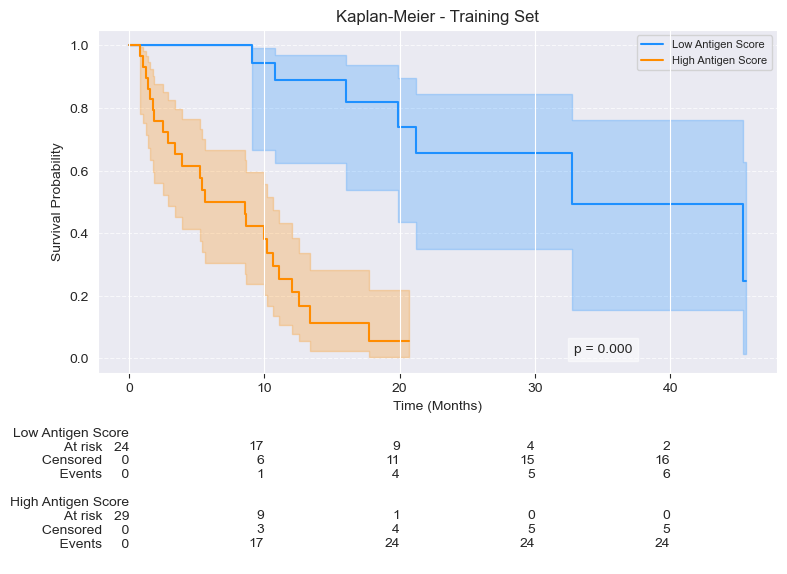

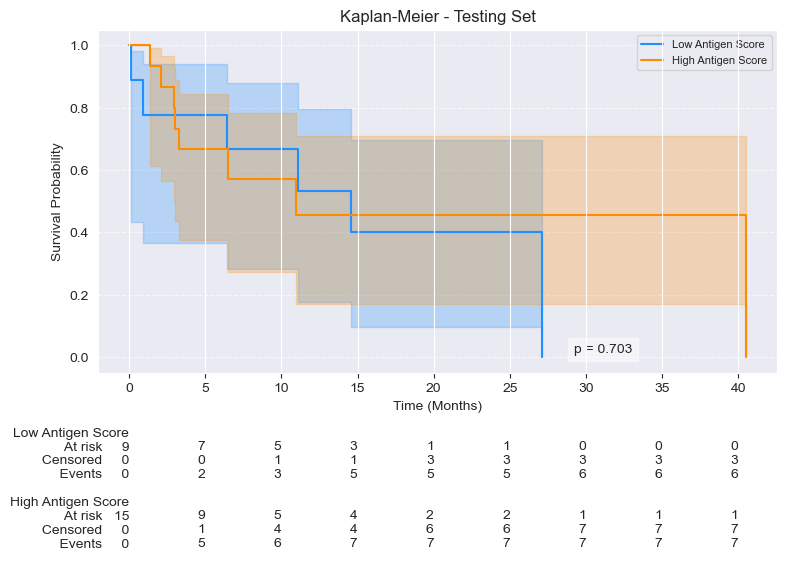

In [102]:
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_intersection_train_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)', labels,
                  title="Kaplan-Meier - Training Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'intersection_coxnet_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_intersection_train_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)')

# Plot for test_cox (External) Set
plot_kaplan_meier(antigen_scores_time_event_intersection_test_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)', labels,
                  title="Kaplan-Meier - Testing Set",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'intersection_coxnet_testingSet_{number_peptides}')
# Perform log-rank test for External Set
perform_logrank_test(antigen_scores_time_event_intersection_test_cox, 'OS months', 'OS Status', 'Antigen Score coxnet (Dichotomized)')

# Prepare Clinical MetaData

In [103]:
with open(f"/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/top_pepides_train_cox_{number_peptides}.pkl", "wb") as f:
    pickle.dump(top_peptides_train_cox, f)

with open(f"/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/top_pepides_train_{number_peptides}.pkl", "wb") as f:
    pickle.dump(top_peptides_train, f)
    
with open(f"/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Predictions/Figures/figures_censored-deceased/top_pepides_intersection_{number_peptides}.pkl", "wb") as f:
    pickle.dump(top_peptides_intersection, f) #(shap_values_train_df.head(30).index.intersection(X_train_cox.columns[np.argsort(np.mean(np.abs(coefficients_matrix_train_cox), axis=0))[-30:][::-1]]))

In [104]:
clinical_meta = metadata_handler.get_individuals_metadata_df()

top_peptides_df = feature_manager.get_data_with_target()[top_peptides_intersection].droplevel(0)
scores_sets = pd.concat([pd.concat([pd.concat([antigen_scores_time_event_intersection_train.iloc[:,2:], antigen_scores_time_event_intersection_test.iloc[:,2:]], axis=0, ignore_index=False),
           pd.concat([pd.concat([antigen_scores_time_event_intersection_train_cox.iloc[:,2:], antigen_scores_time_event_intersection_test_cox.iloc[:,2:]], axis=0, ignore_index=False),
                      pd.concat([risk_scores_train.to_frame(), risk_scores_test.to_frame()], axis=0, ignore_index=False)], axis=1),
                      pd.concat([risk_scores_train_cox.to_frame(), risk_scores_test_cox.to_frame()], axis=0, ignore_index=False)], axis=1)], axis = 1) 
scores_sets.index.name = 'SampleName'
clinical_meta = pd.concat([clinical_meta, scores_sets, top_peptides_df], axis = 1)
# Replace 1 with the name of the peptide and 0 with "absence"
for peptide_column in top_peptides_intersection:
    clinical_meta[peptide_column] = clinical_meta[peptide_column].apply(
        lambda x: 'presence' if x == 1 else 'absence'
    )

In [105]:
clinical_meta['Sex_ctg'] = clinical_meta['Sex'].apply(lambda x: "Male" if x == 1 else "Female")
clinical_meta['Age >= 65'] = (clinical_meta['Age']>=65).astype(int)
clinical_meta['Age_ctg'] = clinical_meta['Age >= 65'].apply(lambda x: ">=65" if x == 1 else "<65")
clinical_meta["Line_of_syst.treatment"] = pd.get_dummies(clinical_meta["Line_of_syst.treatment_ctg"], drop_first=True, dtype=int)
clinical_meta["BMI Category"] = clinical_meta["BMI"].apply(lambda x: "<18.5" if x < 18.5 else 
                                                        ">=18.5<25" if x >= 18.5 and x < 25 else 
                                                        ">=25<30" if x >= 25 and x < 30 else 
                                                        ">=30<35" if x >= 30 and x < 35 else 
                                                        ">=35")
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BMI Category"], drop_first=False, dtype=int).drop(columns=[">=18.5<25"])], axis =1)

clinical_meta['Cirrhosis_ctg'] = clinical_meta['Cirrhosis_ctg'].apply(lambda x: "cirrhosis" if x == "yes" else "no cirrhosis")
clinical_meta['Cirrhosis_ctg'] = pd.Categorical(clinical_meta['Cirrhosis_ctg'],
                                                     categories=["no cirrhosis","cirrhosis"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["Child-Pugh_ctg stage"], drop_first=True, dtype=int).rename(columns={"stage B": "Child-Pugh stage B", 
                                                                                                                                            "stage C": "Child-Pugh stage C"})], axis=1)
clinical_meta['MVI_ctg'] = clinical_meta['MVI_ctg'].apply(lambda x: "MVI" if x == "yes" else "no MVI")
clinical_meta['MVI_ctg'] = pd.Categorical(clinical_meta['MVI_ctg'],
                                                     categories=["no MVI","MVI"], ordered=True)
clinical_meta['EHS_ctg'] = clinical_meta['EHS_ctg'].apply(lambda x: "EHS" if x == "yes" else "no EHS")
clinical_meta['EHS_ctg'] = pd.Categorical(clinical_meta['EHS_ctg'],
                                                     categories=["no EHS","EHS"], ordered=True)
clinical_meta['BCLC_ctg stage'] = pd.Categorical(clinical_meta['BCLC_ctg stage'],
                                                     categories=["stage B", "stage A", "stage C", "stage D"], ordered=True)
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BCLC_ctg stage"], drop_first=True, dtype=int).rename(columns={"stage B": "BCLC stage A", 
                                                                                                                                      "stage C": "BCLC stage C", 
                                                                                                                                      "stage D": "BCLC stage D"})], axis=1)
clinical_meta['AFP400_ctg'] = clinical_meta['AFP400_ctg'].apply(lambda x: ">400" if x == "yes" else "<400")
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["mRECIST_ctg"], drop_first=False, dtype=int).drop(columns=["PR"])], axis=1)
clinical_meta['Antigen Score (Dichotomized) ctg'] = clinical_meta['Antigen Score (Dichotomized)'].apply(lambda x: "Low Antigen Score" if x == 0 else "High Antigen Score")
clinical_meta['Antigen Score (Dichotomized) ctg'] = pd.Categorical(clinical_meta['Antigen Score (Dichotomized) ctg'],
                                                     categories=["Low Antigen Score", "High Antigen Score"], ordered=True)
clinical_meta['Antigen Score coxnet (Dichotomized) ctg'] = clinical_meta['Antigen Score coxnet (Dichotomized)'].apply(lambda x: "Low Antigen Score" if x == 0 else "High Antigen Score")
clinical_meta['Antigen Score coxnet (Dichotomized) ctg'] = pd.Categorical(clinical_meta['Antigen Score coxnet (Dichotomized) ctg'],
                                                     categories=["Low Antigen Score", "High Antigen Score"], ordered=True)

clinical_meta_train = clinical_meta.loc[X_train.index]
clinical_meta_train.loc[:, 'BMI'] = clinical_meta_train['BMI'].fillna(clinical_meta_train['BMI'].median())
clinical_meta_train['mRECIST_ctg'] = clinical_meta_train['mRECIST_ctg'].replace('Death', 'PD')
clinical_meta_train['mRECIST_ctg'] = pd.Categorical(clinical_meta_train['mRECIST_ctg'],
                                                     categories=["PR", "CR", "SD", "PD"], ordered=True)
clinical_meta_test = clinical_meta.loc[X_test.index]
#clinical_meta.to_excel("/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Metadata/HCC_MUW_metadata_with_scores.xlsx", index=True)


# Univariate Analysis


In [106]:
def clean_predictor_name(label):
    # Remove '_ctg' or similar parts
    label = label.replace('_ctg', '')
    # Remove '400_ctg' or any category like this
    label = label.replace('400', '')
    label = label.replace('Category', '')
    label = label.replace('(Scaled)', '')

    # Remove '(Dichotomized) ctg'
    label = re.sub(r'\(Dichotomized\) ctg', '', label)
    # Optionally, remove any trailing spaces
    return label.strip()


# Initialize a list to store the results
cc = ['dodgerblue', 'orange']
top_peptides_intersection_list = list(top_peptides_intersection)
results = []
# List of the variables to perform univariate analysis for
variables = [
    "Sex_ctg", "Age_ctg", "ORR_ctg", "DCR_ctg", "Line_of_syst.treatment_ctg", "BMI Category",
    "Cirrhosis_ctg", "Child-Pugh_ctg stage", "ECOG_ctg", "MVI_ctg", "EHS_ctg", "BCLC_ctg stage",
    "AFP400_ctg", "mRECIST_ctg", "Antigen Score (Dichotomized) ctg", "Antigen Score coxnet (Dichotomized) ctg",
    *top_peptides_intersection_list
]

#variables = [*top_peptides_intersection_list]
# Loop through the list of variables
for var in variables:
    groups = sorted(clinical_meta_train[var].unique())
    kmf_list = []
    flag = 0
    if len(groups) < 3:
        fig, ax = plt.subplots(figsize=(8, 6))

    for group in groups:
        group_data = clinical_meta_train[clinical_meta_train[var] == group]
        
                   
        # Initialize Kaplan-Meier Fitter
        kmf = KaplanMeierFitter()
            
        # Fit the Kaplan-Meier estimator for each group
        kmf.fit(group_data['OS months'], event_observed=group_data['OS Status'], label=str(group))
            
        # Calculate the median survival time and 95% CI for this group
        median_survival = kmf.median_survival_time_
        ci_lower, ci_upper = median_survival_times(kmf.confidence_interval_).iloc[0,0], median_survival_times(kmf.confidence_interval_).iloc[0,1]

        # Get the group size
        group_size = len(group_data)
        kmf_list.append(kmf)
        
        # Perform log-rank test if there are multiple groups
        if len(groups) < 3:
            other_groups = clinical_meta_train[clinical_meta_train[var] != group]
            
            result = logrank_test(group_data['OS months'], other_groups['OS months'],
                                      event_observed_A=group_data['OS Status'],
                                      event_observed_B=other_groups['OS Status'])
            p_value = result.p_value
            kmf.plot_survival_function(ax=ax, ci_show=True, color=cc[flag], show_censors=True)
            #kmf.plot_survival_function(show_censors=True, censor_styles={'ms': 6, 'marker': 's'})
            flag = flag + 1

        else:
            result = multivariate_logrank_test(
                clinical_meta_train['OS months'], 
                clinical_meta_train[var], 
                event_observed=clinical_meta_train['OS Status'])
            p_value = result.p_value

        # Store the results for this group
        clean_var = clean_predictor_name(var)
        results.append([clean_var, group, group_size, median_survival, ci_lower, ci_upper, p_value])
        
        if len(groups) < 3 and flag == 2:
            
            p_value_text = f'p = {p_value:.3f}'
            ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
            add_at_risk_counts(kmf_list[0], kmf_list[1], ax=ax)
            ax.set_title(clean_var, fontsize=12)
            ax.set_xlabel("Time (Months)", fontsize=10)
            ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend(fontsize=8)
            plt.tight_layout()
            fig_path = Path(config.figures_dir) / f'kaplan_meier_{clean_var}_{number_peptides}.png'
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.close()

            fig, ax = plt.subplots(figsize=(8, 4))
            rmst_plot(kmf_list[0], model2=kmf_list[1], text_position=(10, 0.9), t=30, ax=ax)
            # Access the plot lines and change their colors
            lines = ax.get_lines()
            lines[0].set_color(cc[0])
            lines[1].set_color(cc[1])
            ax.set_title(clean_var, fontsize=12)
            ax.set_xlabel("Time (Months)", fontsize=10)
            ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend([lines[0], lines[1]], [kmf_list[0].label, kmf_list[1].label], fontsize=8)
            plt.tight_layout()
            fig_path = Path(config.figures_dir) / f'kaplan_meier_RMST_{clean_var}_{number_peptides}.png'
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.close()



# Convert the results into a DataFrame for easy display
univariate_kmf = pd.DataFrame(results, columns=['Variable', 'Group', 'Size', 'Median OS (Months)', '95% CI Lower', '95% CI Upper', 'P-value'])
significant_predictors_kmf = univariate_kmf[univariate_kmf["P-value"] < 0.05]["Variable"].unique().tolist()

# Remove duplicates in the 'Variable' column, keeping the first occurrence
# Remove both 'stage' and 'Antigen Score' in one step
univariate_kmf['Group'] = univariate_kmf['Group'].str.replace(r'stage|Antigen Score', '', regex=True)
univariate_kmf['Variable'] = univariate_kmf.apply(lambda row: f"\\textbf{{{row['Variable']}}}" if row['P-value'] < 0.05 else row['Variable'], axis=1)
univariate_kmf['P-value'] = univariate_kmf['P-value'].apply(lambda x: f"\\textbf{{{x:.4f}}}" if pd.notna(x) and x < 0.05 else f"{x:.4f}")
univariate_kmf.loc[univariate_kmf['Variable'].duplicated(keep='last'), 'P-value'] = ""
univariate_kmf.loc[univariate_kmf['Variable'].duplicated(), 'Variable'] = ""
# Round the columns to 2 decimals
univariate_kmf['Median OS (Months)'] = univariate_kmf['Median OS (Months)'].round(2)
univariate_kmf['95% CI Lower'] = univariate_kmf['95% CI Lower'].round(2)
univariate_kmf['95% CI Upper'] = univariate_kmf['95% CI Upper'].round(2)
print(tabulate(univariate_kmf, headers='keys', tablefmt='latex', showindex=False))

\begin{tabular}{llrrrrl}
\hline
 Variable                      & Group             &   Size &   Median OS (Months) &   95\% CI Lower &   95\% CI Upper & P-value         \\
\hline
 Sex                           & Female            &     12 &                10.78 &           2.5  &         inf    &                 \\
                               & Male              &     41 &                12.56 &           8.58 &          21.2  & 0.6723          \\
 Age                           & \ensuremath{<}65               &     16 &                11.11 &           3.39 &          45.36 &                 \\
                               & \ensuremath{>}=65              &     37 &                12.56 &           8.65 &          21.2  & 0.6556          \\
 \textbackslash{}textbf\{ORR\}                  & ORR               &     17 &                45.36 &          11.11 &         inf    &                 \\
                               & non ORR           &     36 &                 9.11 &    

In [107]:
# Function to extract category names from the model's index (e.g., 'Sex_ctg[T.Male]' -> 'Male')
def extract_category_name(category):
    category = category.split('[')[-1].split(']')[0].replace('T.', '')
    category = category.replace('stage ', '')
    category = category.replace('Antigen Score', '')
    return  category

# Create a DataFrame with survival variables and clinical predictors
predictors_cont = ["Age", "BMI", "AFP", "Antigen Score (Scaled)", "Antigen Score coxnet (Scaled)"]
predictors_ctg = {"Sex_ctg":"Female", "Age_ctg":"<65", "ORR_ctg":"ORR","DCR_ctg":"DCR", 
                 "Line_of_syst.treatment_ctg":"first", "BMI Category":">=18.5<25", "Cirrhosis_ctg":"no cirrhosis", 
                 "Child-Pugh_ctg stage":"A", "ECOG_ctg":"no symptoms" , "MVI_ctg":"no MVI", "EHS_ctg":"no EHS", 
                 "BCLC_ctg stage":"B", "AFP400_ctg":"<400", "mRECIST_ctg":"PR", 
                  "Antigen Score (Dichotomized) ctg": "Low", "Antigen Score coxnet (Dichotomized) ctg": "Low"}
predictors_ctg.update({variable: "absence" for variable in top_peptides_intersection_list})

# Loop over each categorical predictor (based on the keys of reference_dict)
univariate_results = []

for predictor in predictors_cont:
    # Fit the Cox model for each categorical predictor
    cph = CoxPHFitter()
    cph.fit(clinical_meta_train, duration_col="OS months", event_col="OS Status", formula=f"`{predictor}`")
    summary = cph.summary
    
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[predictor, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[predictor, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[predictor, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    p_value = summary.loc[predictor, 'p']
        
    # Extract the readable category name
    univariate_results.append((predictor, "", hr, ll, ul, p_value))


for predictor, reference_category in predictors_ctg.items():
    # Fit the Cox model for each categorical predictor
    cph = CoxPHFitter()
    cph.fit(clinical_meta_train, duration_col="OS months", event_col="OS Status", formula=f"C(`{predictor}`)")
    
    summary = cph.summary
    
    # Loop over the categories in the summary and create readable names
    for category in summary.index:
        # Extract HR, 95% CI (lower, upper), and p-value for each category
        hr = summary.loc[category, 'exp(coef)']  # Hazard Ratio
        ll = summary.loc[category, 'exp(coef) lower 95%']  # Lower bound of 95% CI
        ul = summary.loc[category, 'exp(coef) upper 95%']  # Upper bound of 95% CI
        p_value = summary.loc[category, 'p']
        
        # Extract the readable category name
        clean_predictor = clean_predictor_name(predictor)
        category_name = extract_category_name(category)+ f" - Ref {reference_category}"
        univariate_results.append((clean_predictor, category_name, hr, ll, ul, p_value))

# Convert results to a DataFrame for better readability
univariate_cph = pd.DataFrame(univariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "P-value"])
significant_predictors_cph = univariate_cph[univariate_cph["P-value"] < 0.05]["Variable"].tolist()

# Remove duplicates in the 'Variable' column, keeping the first occurrence
# Remove both 'stage' and 'Antigen Score' in one step
univariate_cph['Variable'] = univariate_cph.apply(lambda row: f"\\textbf{{{row['Variable']}}}" if row['P-value'] < 0.05 else row['Variable'], axis=1)
univariate_cph['Group'] = univariate_cph.apply(lambda row: f"\\textbf{{{row['Group']}}}" if row['P-value'] < 0.05 else row['Group'], axis=1)
univariate_cph['P-value'] = univariate_cph['P-value'].apply(lambda x: f"\\textbf{{{x:.4f}}}" if pd.notna(x) and x < 0.05 else f"{x:.4f}")
value_counts = univariate_cph['Variable'].value_counts()
repeated_values = value_counts[value_counts > 2].index
univariate_cph.loc[univariate_cph['Variable'].isin(repeated_values) & univariate_cph['Variable'].duplicated(), 'Variable'] = ""

#univariate_cph.loc[univariate_cph['Variable'].duplicated(), 'Variable'] = ""
# Round the columns to 2 decimals
univariate_cph['Hazard Ratio'] = univariate_cph['Hazard Ratio'].round(2)
univariate_cph['95% CI Lower'] = univariate_cph['95% CI Lower'].round(2)
univariate_cph['95% CI Upper'] = univariate_cph['95% CI Upper'].round(2)
print(tabulate(univariate_cph, headers='keys', tablefmt='latex', showindex=False))
univariate_cph

/home/creyna/miniconda3/envs/ML_env/lib/python3.9/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column C(`BMI Category`)[T.>=35] have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['OS Status'].astype(bool)
>>> print(df.loc[events, 'C(`BMI Category`)[T.>=35]'].var())
>>> print(df.loc[~events, 'C(`BMI Category`)[T.>=35]'].var())

A very low variance means that the column C(`BMI Category`)[T.>=35] completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/home/creyna/miniconda3/envs/ML_env/lib/python3.9/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.1

\begin{tabular}{llrrrl}
\hline
 Variable                               & Group                            &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper & P-value         \\
\hline
 Age                                    &                                  &           0.98 &           0.94 &           1.02 & 0.2272          \\
 BMI                                    &                                  &           1.02 &           0.94 &           1.1  & 0.6018          \\
 \textbackslash{}textbf\{AFP\}                           & \textbackslash{}textbf\{\}                        &           1    &           1    &           1    & \textbackslash{}textbf\{0.0082\} \\
 \textbackslash{}textbf\{Antigen Score (Scaled)\}        & \textbackslash{}textbf\{\}                        &          19.83 &           2.78 &         141.64 & \textbackslash{}textbf\{0.0029\} \\
 \textbackslash{}textbf\{Antigen Score coxnet (Scaled)\} & \textbackslash{}textbf\{\}                        &         242.

,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,P-value
0,Age,,0.98,0.94,1.02,0.2272
1,BMI,,1.02,0.94,1.10,0.6018
2,\textbf{AFP},\textbf{},1.00,1.00,1.00,\textbf{0.0082}
3,\textbf{Antigen Score (Scaled)},\textbf{},19.83,2.78,141.64,\textbf{0.0029}
4,\textbf{Antigen Score coxnet (Scaled)},\textbf{},242.15,40.43,1450.31,\textbf{0.0000}
5,Sex,Male - Ref Female,1.20,0.51,2.80,0.6727
6,Age,>=65 - Ref <65,0.84,0.40,1.77,0.6560
7,\textbf{ORR},\textbf{non ORR - Ref ORR},4.14,1.66,10.30,\textbf{0.0022}
8,\textbf{DCR},\textbf{non DCR - Ref DCR},2.87,1.38,5.97,\textbf{0.0048}
9,Line_of_syst.treatment,later - Ref first,0.81,0.32,2.06,0.6606


# Multivariate Analysis with Forward Stepwise Selection

In [67]:
significant_predictors_cph #3,4,6,8,9  #0 AFP, 1-2 antigen, 3,4-ORR/DCR, 5 Child, 7 BCLC stage, 8 AFP, 9 RECIST, 10-11 antigen add MVI

['AFP',
 'Antigen Score (Scaled)',
 'Antigen Score coxnet (Scaled)',
 'ORR',
 'DCR',
 'Child-Pugh stage',
 'Child-Pugh stage',
 'BCLC stage',
 'AFP',
 'mRECIST',
 'Antigen Score',
 'Antigen Score coxnet',
 'agilent_26654',
 'twist_47864',
 'twist_55253',
 'twist_28586',
 'agilent_226351',
 'agilent_241214',
 'agilent_11276']

In [68]:
significant_predictors_kmf

['ORR',
 'DCR',
 'Child-Pugh stage',
 'MVI',
 'BCLC stage',
 'AFP',
 'mRECIST',
 'Antigen Score',
 'Antigen Score coxnet',
 'agilent_26654',
 'twist_47864',
 'twist_55253',
 'twist_28586',
 'agilent_226351',
 'agilent_241214',
 'agilent_11276']

In [108]:
# Function to extract the first and second parts
def extract_parts(text):
    pattern = r'C\(`([^`]+)`\)\[T\.([^\]]+)\]'
    match = re.match(pattern, text)
    if match:
        return match.groups()  # returns a tuple (first_part, second_part)
    else:
        return text, ''  # If it doesn't match the pattern, return the original text and an empty string


references_dict = {"Sex":"Female", "Age":"<65", "ORR":"ORR","DCR":"DCR", 
                 "Line_of_syst.treatment":"first", "BMI":">=18.5<25", "Cirrhosis":"no cirrhosis", 
                 "Child-Pugh stage":"A", "ECOG":"no symptoms" , "MVI":"no MVI", "EHS":"no EHS", 
                 "BCLC stage":"B", "AFP":"<400", "mRECIST":"PR", 
                  "Antigen Score": "Low", "Antigen Score coxnet": "Low"}
references_dict.update({variable: "absence" for variable in top_peptides_intersection_list})
 #3,4,6,8,9  #0 AFP, 1-2 antigen, 3,4-ORR/DCR, 5 Child, 7 BCLC stage, 8 AFP, 9 RECIST, 10-11 antigen add MVI
significant_predictors = [significant_predictors_cph[i] for i in [4,7,8,10]]  
significant_predictors = ['Child-Pugh_ctg stage'] +  ["MVI_ctg"] + [key for key in predictors_ctg if any(value in key for value in significant_predictors)]
significant_predictors.remove("Antigen Score coxnet (Dichotomized) ctg")


# Forward stepwise selection
selected_predictors = []
remaining_predictors = significant_predictors.copy()  #chosen with univariate analysis
best_aic = float("inf")

# Define continuous variables list (for example, AFP is continuous)
continuous_predictors = ['AFP']

while remaining_predictors:
    aic_with_candidates = []
    for predictor in remaining_predictors:
        cph = CoxPHFitter()
  
        # If continuous, just use the variable name without C()
        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors] + [f"`{predictor}`"])
      
        # Fit the model
        cph.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors + [predictor]], 
                duration_col="OS months", event_col="OS Status", formula=formula)

        aic_with_candidates.append((cph.AIC_partial_, predictor))
    
    aic_with_candidates.sort()
    best_new_aic, best_candidate = aic_with_candidates[0]
    
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors.append(best_candidate)
        remaining_predictors.remove(best_candidate)
        print(f"Added {best_candidate}, AIC: {best_aic}")
    else:
        break

print("Final Model Predictors:", selected_predictors)

# Fit the final Cox model with the selected predictors
cph = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors], 
        duration_col="OS months", event_col="OS Status", formula=formula)
cph.print_summary()


multivariate_results = []
summary = cph.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']
    
    variable, category = extract_parts(idx)
    
    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_fwd_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
print(tabulate(multivariate_fwd_cph, headers='keys', tablefmt='latex', showindex=False))

Added Child-Pugh_ctg stage, AIC: 187.233031181678
Added DCR_ctg, AIC: 176.62522906025973
Added Antigen Score (Dichotomized) ctg, AIC: 173.6021160665299
Added MVI_ctg, AIC: 173.42632799823548
Final Model Predictors: ['Child-Pugh_ctg stage', 'DCR_ctg', 'Antigen Score (Dichotomized) ctg', 'MVI_ctg']


<lifelines.CoxPHFitter: fitted with 53 total observations, 22 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 53
number of events observed = 31
   partial log-likelihood = -81.71
         time fit was run = 2025-02-06 21:24:31 UTC

---
                                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                    
C(`Child-Pugh_ctg stage`)[T.stage B]                         2.05      7.73      0.53            1.01            3.08                2.76               21.66
C(`Child-Pugh_ctg stage`)[T.stage C]                         1.50      4.47      0.78           -0.03            3.02                0.97               20.58
C(`DCR_ctg`)[T.non DCR]                                      1.75      5.77      0.48            0.82            2.69                2.26               14.71
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]  0.75      2.13      0.41           -0.05            1.56                0.95                4.77
C(`MVI_ctg`)[T.MVI]                                          0.67      1.96      0.45           -0.22            1.56                0.80                4.75

                                                             cmp to    z      p  -log2(p)
covariate                                                                                
C(`Child-Pugh_ctg stage`)[T.stage B]                           0.00 3.89 <0.005     13.28
C(`Child-Pugh_ctg stage`)[T.stage C]                           0.00 1.92   0.05      4.20
C(`DCR_ctg`)[T.non DCR]                                        0.00 3.67 <0.005     12.00
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]    0.00 1.83   0.07      3.89
C(`MVI_ctg`)[T.MVI]                                            0.00 1.48   0.14      2.85
---
Concordance = 0.82
Partial AIC = 173.43
log-likelihood ratio test = 36.80 on 5 df
-log2(p) of ll-ratio test = 20.54

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group             &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &     Coef &   Score points &     P-value \\
\hline
 Child-Pugh stage & B - Ref A         &        7.72931 &       2.75765  &       21.6642  & 2.04502  &            4.1 & 0.000100657 \\
 Child-Pugh stage & C - Ref A         &        4.47297 &       0.972061 &       20.5825  & 1.49805  &            3   & 0.0544075   \\
 DCR              & non DCR - Ref DCR &        5.76725 &       2.26131  &       14.7088  & 1.7522   &            3.6 & 0.000244377 \\
 Antigen Score    & High  - Ref Low   &        2.12599 &       0.947773 &        4.76891 & 0.754238 &            1.6 & 0.0672756   \\
 MVI              & MVI - Ref no MVI  &        1.9553  &       0.804823 &        4.75035 & 0.670543 &            1.4 & 0.138729    \\
\hline
\end{tabular}


In [109]:
# Fit the final Cox model with the selected predictors
cph_fwd = CoxPHFitter()
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_fwd.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)
covariates_groups = cph_fwd.summary.index
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group

variables['Antigen Score (Dichotomized) ctg'] = ["Low Antigen Score"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    cph_fwd.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'CoxPhModel_Partial_Effects_Outcome_Forward_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

In [110]:
pass_peptides = [ 'agilent_26654', 'twist_47864', 'twist_55253', 'twist_28586', 'agilent_226351', 'agilent_241214', 'agilent_11276']

 #3,4,6,8,9  #0 AFP, 1-2 antigen, 3,4-ORR/DCR, 5 Child, 7 BCLC stage, 8 AFP, 9 RECIST, 10-11 antigen add MVI
significant_predictors = [significant_predictors_cph[i] for i in [4,7,8]]   
significant_predictors = ['Child-Pugh_ctg stage'] +  ["MVI_ctg"] + [key for key in predictors_ctg if any(value in key for value in significant_predictors)] + pass_peptides

# Forward stepwise selection
selected_predictors = []
remaining_predictors = significant_predictors.copy()  #chosen with univariate analysis
best_aic = float("inf")

# Define continuous variables list (for example, AFP is continuous)
continuous_predictors = ['AFP']

while remaining_predictors:
    aic_with_candidates = []
    for predictor in remaining_predictors:
        cph = CoxPHFitter()
  
        # If continuous, just use the variable name without C()
        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors] + [f"`{predictor}`"])
      
        # Fit the model
        cph.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors + [predictor]], 
                duration_col="OS months", event_col="OS Status", formula=formula)

        aic_with_candidates.append((cph.AIC_partial_, predictor))
    
    aic_with_candidates.sort()
    best_new_aic, best_candidate = aic_with_candidates[0]
    
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors.append(best_candidate)
        remaining_predictors.remove(best_candidate)
        print(f"Added {best_candidate}, AIC: {best_aic}")
    else:
        break

print("Final Model Predictors:", selected_predictors)

# Fit the final Cox model with the selected predictors
cph_fwd_peptides = CoxPHFitter()
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_fwd_peptides.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors], 
        duration_col="OS months", event_col="OS Status", formula=formula)
cph_fwd_peptides.print_summary()

multivariate_results = []
summary = cph_fwd_peptides.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']
    
    variable, category = extract_parts(idx)
    
    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_fwd_peptides_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
print(tabulate(multivariate_fwd_peptides_cph, headers='keys', tablefmt='latex', showindex=False))

Added Child-Pugh_ctg stage, AIC: 187.233031181678
Added DCR_ctg, AIC: 176.62522906025973
Added agilent_226351, AIC: 170.31273131669167
Added twist_47864, AIC: 167.26307677443285
Added MVI_ctg, AIC: 165.49623493033846
Added twist_28586, AIC: 164.1107814899525
Added agilent_11276, AIC: 163.93261490116345
Final Model Predictors: ['Child-Pugh_ctg stage', 'DCR_ctg', 'agilent_226351', 'twist_47864', 'MVI_ctg', 'twist_28586', 'agilent_11276']


<lifelines.CoxPHFitter: fitted with 53 total observations, 22 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 53
number of events observed = 31
   partial log-likelihood = -73.97
         time fit was run = 2025-02-06 21:25:04 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
C(`Child-Pugh_ctg stage`)[T.stage B]  1.59      4.92      0.58            0.47            2.72                1.59               15.18
C(`Child-Pugh_ctg stage`)[T.stage C]  1.16      3.20      0.86           -0.52            2.85                0.59               17.23
C(`DCR_ctg`)[T.non DCR]               1.95      7.00      0.54            0.88            3.01                2.41               20.31
C(`agilent_226351`)[T.presence]       1.15      3.17      0.43            0.30            2.00                1.36                7.40
C(`twist_47864`)[T.presence]         -1.07      0.34      0.45           -1.96           -0.18                0.14                0.83
C(`MVI_ctg`)[T.MVI]                   0.96      2.62      0.44            0.10            1.83                1.10                6.24
C(`twist_28586`)[T.presence]         -0.89      0.41      0.47           -1.81            0.04                0.16                1.04
C(`agilent_11276`)[T.presence]        0.75      2.11      0.48           -0.20            1.70                0.82                5.47

                                      cmp to     z      p  -log2(p)
covariate                                                          
C(`Child-Pugh_ctg stage`)[T.stage B]    0.00  2.77   0.01      7.47
C(`Child-Pugh_ctg stage`)[T.stage C]    0.00  1.35   0.18      2.51
C(`DCR_ctg`)[T.non DCR]                 0.00  3.58 <0.005     11.52
C(`agilent_226351`)[T.presence]         0.00  2.66   0.01      7.01
C(`twist_47864`)[T.presence]            0.00 -2.36   0.02      5.79
C(`MVI_ctg`)[T.MVI]                     0.00  2.18   0.03      5.08
C(`twist_28586`)[T.presence]            0.00 -1.87   0.06      4.02
C(`agilent_11276`)[T.presence]          0.00  1.54   0.12      3.03
---
Concordance = 0.85
Partial AIC = 163.93
log-likelihood ratio test = 52.30 on 8 df
-log2(p) of ll-ratio test = 26.01

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group                  &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &      Coef &   Score points &     P-value \\
\hline
 Child-Pugh stage & B - Ref A              &       4.91643  &       1.59212  &      15.1818   &  1.59258  &            3.2 & 0.00563328  \\
 Child-Pugh stage & C - Ref A              &       3.20026  &       0.594396 &      17.2304   &  1.16323  &            2.4 & 0.175639    \\
 DCR              & non DCR - Ref DCR      &       7.00268  &       2.41484  &      20.3067   &  1.94629  &            3.9 & 0.000339688 \\
 agilent\_226351   & presence - Ref absence &       3.16799  &       1.35594  &       7.40165  &  1.1531   &            2.4 & 0.0077394   \\
 twist\_47864      & presence - Ref absence &       0.34185  &       0.140383 &       0.832446 & -1.07338  &           -2.1 & 0.0180876   \\
 MVI              & MVI - Ref no MVI       &       2.61986  &       1.1005   &       6.23684  &  0.963119 &         

In [111]:
# Fit the final Cox model with the selected predictors
cph_fwd_peptides = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_fwd_peptides.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)
covariates_groups = cph_fwd_peptides.summary.index
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group


variables['twist_47864'] = ["absence"]
variables['twist_28586'] = ["absence"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    cph_fwd_peptides.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'CoxPhModel_Partial_Effects_Outcome_Forward_Peptides_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

# Multivariate Analysis with Backward Stepwise Selection


In [112]:
y_surv_train = Surv.from_arrays(event=clinical_meta_train["OS Status"], time=clinical_meta_train["OS months"])
y_surv_test = Surv.from_arrays(event=clinical_meta_test["OS Status"], time=clinical_meta_test["OS months"])

 #3,4,6,8,9  #0 AFP, 1-2 antigen, 3,4-ORR/DCR, 5 Child, 7 BCLC stage, 8 AFP, 9 RECIST, 10-11 antigen add MVI
significant_predictors = [significant_predictors_cph[i] for i in [4,7,8,10]]  
significant_predictors = ['Child-Pugh_ctg stage'] +  ["MVI_ctg"] + [key for key in predictors_ctg if any(value in key for value in significant_predictors)]
significant_predictors.remove("Antigen Score coxnet (Dichotomized) ctg")
continuous_predictors = ['AFP']

# Step 2: Fit Cox model with all candidate variables
cph = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in significant_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in significant_predictors])
cph.fit(clinical_meta_train[["OS months", "OS Status"] + significant_predictors], 
        duration_col="OS months", event_col="OS Status", formula=formula)

        
# Step 3: Start the backward selection process
selected_predictors = significant_predictors.copy()
best_aic = cph.AIC_partial_

# Conditional Backward Selection Loop
while len(selected_predictors) > 0:
    aic_with_candidates = []
    # Loop through each predictor and remove it, refit the model, and calculate AIC
    for predictor in selected_predictors:
        predictors_to_fit = [p for p in selected_predictors if p != predictor]
        
        cph = CoxPHFitter()   

        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in predictors_to_fit])
        #formula = " + ".join([f"C(`{p}`)" for p in predictors_to_fit])
        cph.fit(clinical_meta_train[["OS months", "OS Status"] + predictors_to_fit], 
                duration_col="OS months", event_col="OS Status", formula=formula)
                
        # Store the AIC for this candidate model
        aic_with_candidates.append((cph.AIC_partial_, predictor))
    
    # Sort by AIC and select the model with the smallest AIC
    aic_with_candidates.sort()
    best_new_aic, best_candidate_to_remove = aic_with_candidates[0]
    
    # If the best model with one less predictor has a better AIC, remove the variable
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors.remove(best_candidate_to_remove)
        print(f"Removed {best_candidate_to_remove}, AIC: {best_aic}")
    else:
        break  # Stop if no improvement

# Final Model with selected predictors
print("Final Model Predictors:", selected_predictors)

# Fit the final Cox model with the selected predictors
cph_bwd = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_bwd.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors], 
        duration_col="OS months", event_col="OS Status", formula=formula)
# Print the final model summary
cph_bwd.print_summary()


multivariate_results = []
summary = cph_bwd.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']
    
    variable, category = extract_parts(idx)
    
    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_bwd_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
multivariate_bwd_cph['Hazard Ratio'] = multivariate_bwd_cph['Hazard Ratio'].round(2)
multivariate_bwd_cph['95% CI Lower'] = multivariate_bwd_cph['95% CI Lower'].round(2)
multivariate_bwd_cph['95% CI Upper'] = multivariate_bwd_cph['95% CI Upper'].round(2)
multivariate_bwd_cph['Coef'] = multivariate_bwd_cph['Coef'].round(2)
multivariate_bwd_cph['P-value'] = multivariate_bwd_cph['P-value'].round(4)

print(tabulate(multivariate_bwd_cph, headers='keys', tablefmt='latex', showindex=False))

# Prepare the external validation set (clinical_meta_test)
validation_data = clinical_meta_test[["OS months", "OS Status"] + selected_predictors]
predicted_risk_scores_bwd = cph_bwd.predict_partial_hazard(validation_data)
# Calculate the C-index on the external validation set
c_index_external = concordance_index_ipcw(y_surv_train, y_surv_test, predicted_risk_scores_bwd)[0]
print(f"C-index on the testing validation set: {c_index_external:.4f}")

#AIC:173.42632799823548
#Final Model Predictors: ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg', 'Antigen Score (Dichotomized) ctg']
#C-index on the testing validation set: 0.7602

Removed AFP400_ctg, AIC: 173.42632799823548
Final Model Predictors: ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg', 'Antigen Score (Dichotomized) ctg']


<lifelines.CoxPHFitter: fitted with 53 total observations, 22 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 53
number of events observed = 31
   partial log-likelihood = -81.71
         time fit was run = 2025-02-06 21:25:13 UTC

---
                                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                    
C(`Child-Pugh_ctg stage`)[T.stage B]                         2.05      7.73      0.53            1.01            3.08                2.76               21.66
C(`Child-Pugh_ctg stage`)[T.stage C]                         1.50      4.47      0.78           -0.03            3.02                0.97               20.58
C(`MVI_ctg`)[T.MVI]                                          0.67      1.96      0.45           -0.22            1.56                0.80                4.75
C(`DCR_ctg`)[T.non DCR]                                      1.75      5.77      0.48            0.82            2.69                2.26               14.71
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]  0.75      2.13      0.41           -0.05            1.56                0.95                4.77

                                                             cmp to    z      p  -log2(p)
covariate                                                                                
C(`Child-Pugh_ctg stage`)[T.stage B]                           0.00 3.89 <0.005     13.28
C(`Child-Pugh_ctg stage`)[T.stage C]                           0.00 1.92   0.05      4.20
C(`MVI_ctg`)[T.MVI]                                            0.00 1.48   0.14      2.85
C(`DCR_ctg`)[T.non DCR]                                        0.00 3.67 <0.005     12.00
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]    0.00 1.83   0.07      3.89
---
Concordance = 0.82
Partial AIC = 173.43
log-likelihood ratio test = 36.80 on 5 df
-log2(p) of ll-ratio test = 20.54

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group             &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &   Coef &   Score points &   P-value \\
\hline
 Child-Pugh stage & B - Ref A         &           7.73 &           2.76 &          21.66 &   2.05 &            4.1 &    0.0001 \\
 Child-Pugh stage & C - Ref A         &           4.47 &           0.97 &          20.58 &   1.5  &            3   &    0.0544 \\
 MVI              & MVI - Ref no MVI  &           1.96 &           0.8  &           4.75 &   0.67 &            1.4 &    0.1387 \\
 DCR              & non DCR - Ref DCR &           5.77 &           2.26 &          14.71 &   1.75 &            3.6 &    0.0002 \\
 Antigen Score    & High  - Ref Low   &           2.13 &           0.95 &           4.77 &   0.75 &            1.6 &    0.0673 \\
\hline
\end{tabular}
C-index on the testing validation set: 0.7602


In [113]:
# Fit the final Cox model with the selected predictors
cph_bwd = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_bwd.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)

covariates_groups = cph_bwd.summary.index
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group

variables['Antigen Score (Dichotomized) ctg'] = ["Low Antigen Score"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    cph_bwd.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'CoxPhModel_Partial_Effects_Outcome_Backward_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

# Multivariate Analysis with Peptides Backward Stepwise

In [114]:
pass_peptides = [ 'agilent_26654', 'twist_47864', 'twist_55253', 'twist_28586', 'agilent_226351', 'agilent_241214', 'agilent_11276']

 #3,4,6,8,9  #0 AFP, 1-2 antigen, 3,4-ORR/DCR, 5 Child, 7 BCLC stage, 8 AFP, 9 RECIST, 10-11 antigen add MVI
significant_predictors = [significant_predictors_cph[i] for i in [4,7,8]]   
significant_predictors = ['Child-Pugh_ctg stage'] +  ["MVI_ctg"] + [key for key in predictors_ctg if any(value in key for value in significant_predictors)] + pass_peptides
continuous_predictors = ['AFP']

# Step 2: Fit Cox model with all candidate variables
cph = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in significant_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in significant_predictors])
cph.fit(clinical_meta_train[["OS months", "OS Status"] + significant_predictors], 
        duration_col="OS months", event_col="OS Status", formula=formula)

# Step 3: Start the backward selection process
selected_predictors_peptides = significant_predictors.copy()
best_aic = cph.AIC_partial_

# Conditional Backward Selection Loop
while len(selected_predictors_peptides) > 0:
    aic_with_candidates = []
    # Loop through each predictor and remove it, refit the model, and calculate AIC
    for predictor in selected_predictors_peptides:
        predictors_to_fit = [p for p in selected_predictors_peptides if p != predictor]
        
        cph = CoxPHFitter()   

        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in predictors_to_fit])
        #formula = " + ".join([f"C(`{p}`)" for p in predictors_to_fit])
        cph.fit(clinical_meta_train[["OS months", "OS Status"] + predictors_to_fit], 
                duration_col="OS months", event_col="OS Status", formula=formula)
                
        # Store the AIC for this candidate model
        aic_with_candidates.append((cph.AIC_partial_, predictor))
    
    # Sort by AIC and select the model with the smallest AIC
    aic_with_candidates.sort()
    best_new_aic, best_candidate_to_remove = aic_with_candidates[0]
    
    # If the best model with one less predictor has a better AIC, remove the variable
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors_peptides.remove(best_candidate_to_remove)
        print(f"Removed {best_candidate_to_remove}, AIC: {best_aic}")
    else:
        break  # Stop if no improvement

# Final Model with selected predictors
print("Final Model Predictors:", selected_predictors_peptides)

# Fit the final Cox model with the selected predictors
cph_bwd_peptides = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors_peptides])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors_peptides])
cph_bwd_peptides.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors_peptides],
        duration_col="OS months", event_col="OS Status", formula=formula)
# Print the final model summary
cph_bwd_peptides.print_summary()


multivariate_results = []
summary = cph_bwd_peptides.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']
    
    variable, category = extract_parts(idx)
    
    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_bwd_peptides_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
multivariate_bwd_peptides_cph['Hazard Ratio'] = multivariate_bwd_peptides_cph['Hazard Ratio'].round(2)
multivariate_bwd_peptides_cph['95% CI Lower'] = multivariate_bwd_peptides_cph['95% CI Lower'].round(2)
multivariate_bwd_peptides_cph['95% CI Upper'] = multivariate_bwd_peptides_cph['95% CI Upper'].round(2)
multivariate_bwd_peptides_cph['Coef'] = multivariate_bwd_peptides_cph['Coef'].round(2)
multivariate_bwd_peptides_cph['P-value'] = multivariate_bwd_peptides_cph['P-value'].round(4)

print(tabulate(multivariate_bwd_peptides_cph, headers='keys', tablefmt='latex', showindex=False))

# Prepare the external validation set (clinical_meta_test)
validation_data = clinical_meta_test[["OS months", "OS Status"] + selected_predictors_peptides]
predicted_risk_scores_bwd_peptides = cph_bwd_peptides.predict_partial_hazard(validation_data)
# Calculate the C-index on the external validation set
c_index_external = concordance_index_ipcw(y_surv_train, y_surv_test, predicted_risk_scores_bwd_peptides)[0]
print(f"C-index on the testing validation set: {c_index_external:.4f}")
#AIC: 163.93261490116345
#Final Model Predictors: ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg', 'twist_47864', 'twist_28586', 'agilent_226351', 'agilent_11276']
#C-index on the testing validation set: 0.7339

Removed AFP400_ctg, AIC: 168.91306267651782
Removed twist_55253, AIC: 166.99495349839884
Removed agilent_241214, AIC: 165.25989218029176
Removed agilent_26654, AIC: 163.93261490116345
Final Model Predictors: ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg', 'twist_47864', 'twist_28586', 'agilent_226351', 'agilent_11276']


<lifelines.CoxPHFitter: fitted with 53 total observations, 22 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 53
number of events observed = 31
   partial log-likelihood = -73.97
         time fit was run = 2025-02-06 21:26:17 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
C(`Child-Pugh_ctg stage`)[T.stage B]  1.59      4.92      0.58            0.47            2.72                1.59               15.18
C(`Child-Pugh_ctg stage`)[T.stage C]  1.16      3.20      0.86           -0.52            2.85                0.59               17.23
C(`MVI_ctg`)[T.MVI]                   0.96      2.62      0.44            0.10            1.83                1.10                6.24
C(`DCR_ctg`)[T.non DCR]               1.95      7.00      0.54            0.88            3.01                2.41               20.31
C(`twist_47864`)[T.presence]         -1.07      0.34      0.45           -1.96           -0.18                0.14                0.83
C(`twist_28586`)[T.presence]         -0.89      0.41      0.47           -1.81            0.04                0.16                1.04
C(`agilent_226351`)[T.presence]       1.15      3.17      0.43            0.30            2.00                1.36                7.40
C(`agilent_11276`)[T.presence]        0.75      2.11      0.48           -0.20            1.70                0.82                5.47

                                      cmp to     z      p  -log2(p)
covariate                                                          
C(`Child-Pugh_ctg stage`)[T.stage B]    0.00  2.77   0.01      7.47
C(`Child-Pugh_ctg stage`)[T.stage C]    0.00  1.35   0.18      2.51
C(`MVI_ctg`)[T.MVI]                     0.00  2.18   0.03      5.08
C(`DCR_ctg`)[T.non DCR]                 0.00  3.58 <0.005     11.52
C(`twist_47864`)[T.presence]            0.00 -2.36   0.02      5.79
C(`twist_28586`)[T.presence]            0.00 -1.87   0.06      4.02
C(`agilent_226351`)[T.presence]         0.00  2.66   0.01      7.01
C(`agilent_11276`)[T.presence]          0.00  1.54   0.12      3.03
---
Concordance = 0.85
Partial AIC = 163.93
log-likelihood ratio test = 52.30 on 8 df
-log2(p) of ll-ratio test = 26.01

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group                  &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &   Coef &   Score points &   P-value \\
\hline
 Child-Pugh stage & B - Ref A              &           4.92 &           1.59 &          15.18 &   1.59 &            3.2 &    0.0056 \\
 Child-Pugh stage & C - Ref A              &           3.2  &           0.59 &          17.23 &   1.16 &            2.4 &    0.1756 \\
 MVI              & MVI - Ref no MVI       &           2.62 &           1.1  &           6.24 &   0.96 &            2   &    0.0295 \\
 DCR              & non DCR - Ref DCR      &           7    &           2.41 &          20.31 &   1.95 &            3.9 &    0.0003 \\
 twist\_47864      & presence - Ref absence &           0.34 &           0.14 &           0.83 &  -1.07 &           -2.1 &    0.0181 \\
 twist\_28586      & presence - Ref absence &           0.41 &           0.16 &           1.04 &  -0.89 &           -1.7 &    0.0616 \\
 agilent\_2

In [116]:
# Fit the final Cox model with the selected predictors
cph_bwd_peptides = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors_peptides])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors_peptides])
cph_bwd_peptides.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors_peptides],
        duration_col="OS months", event_col="OS Status", formula=formula)

covariates_groups = cph_bwd_peptides.summary.index
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group

variables['twist_47864'] = ["absence"]
variables['twist_28586'] = ["absence"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    cph_bwd_peptides.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'CoxPhModel_Partial_Effects_Outcome_Backward_Peptides_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

## Formatting Multivariate Model Data for Forest plots

In [117]:
# Example list with the desired order of variables
variable_order = multivariate_bwd_cph['Variable'].unique()
# Iterate over unique variable names in the 'Variable' column
new_rows = []
for variable in variable_order:
    # Create the new row with the reference values from the dictionary
    new_row = {
        'Variable': variable,  # Variable name
        'Group': references_dict.get(variable, ''),  # Group from ref_dict, default to empty string if not found
        'Hazard Ratio': 1,  # Set Hazard Ratio to 1
        '95% CI Lower': None,  # Empty string for 95% CI Lower
        '95% CI Upper': None,  # Empty string for 95% CI Upper
        'Coef': None,  # Empty string for Coef
        'Score points': None,  # Empty string for Score points
        'P-value': None  # Empty string for P-value
    }
    new_rows.append(new_row)
# Append the new rows to the original DataFrame
multivariate_forest = pd.concat([multivariate_bwd_cph, pd.DataFrame(new_rows)], ignore_index=True)
multivariate_forest['Group'] = multivariate_forest['Group'].str.replace(r'\s*- Ref.*', '', regex=True)
multivariate_forest['Variable'] = pd.Categorical(multivariate_forest['Variable'], categories=variable_order, ordered=True)
multivariate_forest = multivariate_forest.sort_values(by=['Variable', 'Hazard Ratio'], ascending=[True, True]).reset_index(drop=True)

#check this
multivariate_forest.iloc[1], multivariate_forest.iloc[2] = multivariate_forest.iloc[2].copy(), multivariate_forest.iloc[1].copy()
###


multivariate_forest['Variable'] = multivariate_forest['Variable'].cat.add_categories("")
multivariate_forest.loc[multivariate_forest['Variable'].duplicated(), 'Variable'] = ""

unique_variables = ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg','Antigen Score (Dichotomized) ctg']  # Add your actual list here

tmp = []
for variable in unique_variables:
    if variable == "AFP":
        tmp.append({
            'Variable': variable,
            'Group': '',
            'Size': 53
        })
    else:
        tmp_groups = clinical_meta_train[variable].unique()
        for group in tmp_groups:
            tmp_group_size = clinical_meta_train[clinical_meta_train[variable] == group].shape[0]
            tmp.append({
                'Variable': variable,
                'Group': group,
                'Size': tmp_group_size
            })
tmp = pd.DataFrame(tmp)
#check the match order
tmp.iloc[5], tmp.iloc[6] = tmp.iloc[6].copy(), tmp.iloc[5].copy()
tmp.iloc[7], tmp.iloc[8] = tmp.iloc[8].copy(), tmp.iloc[7].copy()
##
multivariate_forest['N'] = tmp['Size']
multivariate_forest_reversed = multivariate_forest[::-1].copy()
multivariate_forest_reversed['log_HR'] = np.log(multivariate_forest_reversed['Hazard Ratio'])
multivariate_forest_reversed['log_95% CI Lower'] = np.log(multivariate_forest_reversed['95% CI Lower'])
multivariate_forest_reversed['log_95% CI Upper'] = np.log(multivariate_forest_reversed['95% CI Upper'])
multivariate_forest_reversed

/tmp/ipykernel_438091/2015138169.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  multivariate_forest = pd.concat([multivariate_bwd_cph, pd.DataFrame(new_rows)], ignore_index=True)


,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,Coef,Score points,P-value,N,log_HR,log_95% CI Lower,log_95% CI Upper
8,,High,2.13,0.95,4.77,0.75,1.6,0.0673,29,0.756122,-0.051293,1.562346
7,Antigen Score,Low,1.00,NaN,NaN,NaN,NaN,NaN,24,0.000000,NaN,NaN
6,,non DCR,5.77,2.26,14.71,1.75,3.6,0.0002,25,1.752672,0.815365,2.688528
5,DCR,DCR,1.00,NaN,NaN,NaN,NaN,NaN,28,0.000000,NaN,NaN
4,,MVI,1.96,0.80,4.75,0.67,1.4,0.1387,24,0.672944,-0.223144,1.558145
3,MVI,no MVI,1.00,NaN,NaN,NaN,NaN,NaN,29,0.000000,NaN,NaN
2,,C,4.47,0.97,20.58,1.50,3.0,0.0544,3,1.497388,-0.030459,3.024320
1,,B,7.73,2.76,21.66,2.05,4.1,0.0001,17,2.045109,1.015231,3.075467
0,Child-Pugh stage,A,1.00,NaN,NaN,NaN,NaN,NaN,33,0.000000,NaN,NaN


In [118]:
# Example list with the desired order of variables
variable_order = multivariate_bwd_peptides_cph['Variable'].unique()
# Iterate over unique variable names in the 'Variable' column
new_rows = []
for variable in variable_order:
    # Create the new row with the reference values from the dictionary
    new_row = {
        'Variable': variable,  # Variable name
        'Group': references_dict.get(variable, ''),  # Group from ref_dict, default to empty string if not found
        'Hazard Ratio': 1,  # Set Hazard Ratio to 1
        '95% CI Lower': None,  # Empty string for 95% CI Lower
        '95% CI Upper': None,  # Empty string for 95% CI Upper
        'Coef': None,  # Empty string for Coef
        'Score points': None,  # Empty string for Score points
        'P-value': None  # Empty string for P-value
    }
    new_rows.append(new_row)
# Append the new rows to the original DataFrame
multivariate_peptides_forest = pd.concat([multivariate_bwd_peptides_cph, pd.DataFrame(new_rows)], ignore_index=True)
multivariate_peptides_forest['Group'] = multivariate_peptides_forest['Group'].str.replace(r'\s*- Ref.*', '', regex=True)
multivariate_peptides_forest['Variable'] = pd.Categorical(multivariate_peptides_forest['Variable'], categories=variable_order, ordered=True)
multivariate_peptides_forest = multivariate_peptides_forest.sort_values(by=['Variable', 'Hazard Ratio'], ascending=[True, True]).reset_index(drop=True)


#### this check
# for multivariate analysis where the var groups are not sorted with baseline first
multivariate_peptides_forest.iloc[1], multivariate_peptides_forest.iloc[2] = multivariate_peptides_forest.iloc[2].copy(), multivariate_peptides_forest.iloc[1].copy()
multivariate_peptides_forest.iloc[7], multivariate_peptides_forest.iloc[8] = multivariate_peptides_forest.iloc[8].copy(), multivariate_peptides_forest.iloc[7].copy()
multivariate_peptides_forest.iloc[9], multivariate_peptides_forest.iloc[10] = multivariate_peptides_forest.iloc[10].copy(), multivariate_peptides_forest.iloc[9].copy()
##################

multivariate_peptides_forest['Variable'] = multivariate_peptides_forest['Variable'].cat.add_categories("")
multivariate_peptides_forest.loc[multivariate_peptides_forest['Variable'].duplicated(), 'Variable'] = ""
unique_variables = ['Child-Pugh_ctg stage', 'MVI_ctg', 'DCR_ctg', 'agilent_11276', 'agilent_226351', 'twist_28586', 'twist_47864']  # Add your actual list here

tmp = []
for variable in unique_variables:
    tmp_groups = clinical_meta_train[variable].unique()
    for group in tmp_groups:
        tmp_group_size = clinical_meta_train[clinical_meta_train[variable] == group].shape[0]
        tmp.append({
            'Variable': variable,
            'Group': group,
            'Size': tmp_group_size
        })
tmp = pd.DataFrame(tmp)
#tmp = tmp.sort_values(by=['Variable', 'Group'], ascending=[True, True]).reset_index(drop=True)

#
tmp.iloc[5], tmp.iloc[6] = tmp.iloc[6].copy(), tmp.iloc[5].copy()
tmp.iloc[7], tmp.iloc[14] = tmp.iloc[14].copy(), tmp.iloc[7].copy()
tmp.iloc[8], tmp.iloc[13] = tmp.iloc[13].copy(), tmp.iloc[8].copy()
tmp.iloc[13], tmp.iloc[14] = tmp.iloc[14].copy(), tmp.iloc[13].copy()
tmp.iloc[9], tmp.iloc[12] = tmp.iloc[12].copy(), tmp.iloc[9].copy()
tmp.iloc[10], tmp.iloc[11] = tmp.iloc[11].copy(), tmp.iloc[10].copy()
#

multivariate_peptides_forest['N'] = tmp['Size']
multivariate_peptides_forest_reversed = multivariate_peptides_forest[::-1].copy()
multivariate_peptides_forest_reversed['log_HR'] = np.log(multivariate_peptides_forest_reversed['Hazard Ratio'])
multivariate_peptides_forest_reversed['log_95% CI Lower'] = np.log(multivariate_peptides_forest_reversed['95% CI Lower'])
multivariate_peptides_forest_reversed['log_95% CI Upper'] = np.log(multivariate_peptides_forest_reversed['95% CI Upper'])
multivariate_peptides_forest_reversed

/tmp/ipykernel_438091/3880084352.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  multivariate_peptides_forest = pd.concat([multivariate_bwd_peptides_cph, pd.DataFrame(new_rows)], ignore_index=True)


,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,Coef,Score points,P-value,N,log_HR,log_95% CI Lower,log_95% CI Upper
14,,presence,2.11,0.82,5.47,0.75,1.5,0.1224,11,0.746688,-0.198451,1.699279
13,agilent_11276,absence,1.00,NaN,NaN,NaN,NaN,NaN,42,0.000000,NaN,NaN
12,,presence,3.17,1.36,7.40,1.15,2.4,0.0077,18,1.153732,0.307485,2.001480
11,agilent_226351,absence,1.00,NaN,NaN,NaN,NaN,NaN,35,0.000000,NaN,NaN
10,,presence,0.41,0.16,1.04,-0.89,-1.7,0.0616,41,-0.891598,-1.832581,0.039221
9,twist_28586,absence,1.00,NaN,NaN,NaN,NaN,NaN,12,0.000000,NaN,NaN
8,,presence,0.34,0.14,0.83,-1.07,-2.1,0.0181,38,-1.078810,-1.966113,-0.186330
7,twist_47864,absence,1.00,NaN,NaN,NaN,NaN,NaN,15,0.000000,NaN,NaN
6,,non DCR,7.00,2.41,20.31,1.95,3.9,0.0003,25,1.945910,0.879627,3.011113
5,DCR,DCR,1.00,NaN,NaN,NaN,NaN,NaN,28,0.000000,NaN,NaN


# Forest Plots

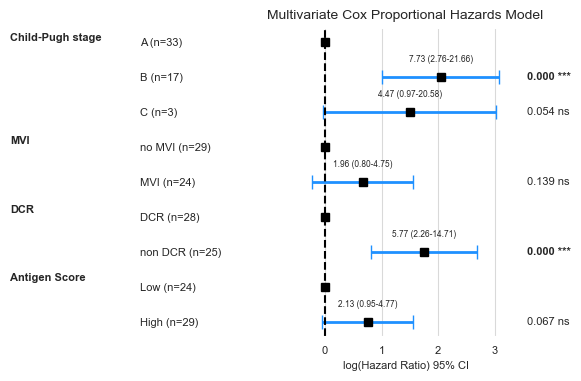

In [119]:
variables = multivariate_forest_reversed['Variable']
p_values = multivariate_forest_reversed['P-value']
groups = multivariate_forest_reversed['Group']
N = multivariate_forest_reversed['N']
hr = multivariate_forest_reversed['log_HR']
lower_ci = multivariate_forest_reversed['log_95% CI Lower']
upper_ci = multivariate_forest_reversed['log_95% CI Upper']
actual_hr = multivariate_forest_reversed['Hazard Ratio']  # Store actual HR values for display
actual_lc = multivariate_forest_reversed['95% CI Lower']
actual_uc = multivariate_forest_reversed['95% CI Upper']

# Convert p-values to significance stars
def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(7, 5), gridspec_kw={'width_ratios': [1, 4]})  # Adjusted width ratios
# **First subplot: Variable names in bold**
for i, var in enumerate(variables):
    ax1.text(0, (i + 0.6) / len(variables), f"{var}", fontsize=8, ha='left', fontweight='bold')

# Remove the x and y axis ticks/labels in the first subplot
ax1.axis('off')

# **Second subplot: Forest plot with HR, CI, Group labels, and P-values**
# Plot hazard ratios with error bars (95% CI)
ax2.errorbar(hr, np.arange(len(variables)), xerr=[np.array(hr) - np.array(lower_ci), np.array(upper_ci) - np.array(hr)],
             fmt='s', color='black', ecolor='dodgerblue', elinewidth=2, capsize=5)

# Adding the reference line at HR = 1
ax2.axvline(np.log(1), color='black', linestyle='--')

# Annotate with text: Adding p-values and CI on top of each HR point
for i, (h, l, u, p) in enumerate(zip(hr, lower_ci, upper_ci, p_values)):
    if pd.notna(p) and p != 'ns':
        significance = get_significance_stars(p)
        p_value_text = f'{p:.3f} {significance}'
        
        # Make p-value bold if significant
        if p < 0.05:
            ax2.text(np.nanmax(np.array(upper_ci)) + 0.5, i, p_value_text, va='center', ha='left', fontsize=8, fontweight='bold')
        else:
            ax2.text(np.nanmax(np.array(upper_ci)) + 0.5, i, p_value_text, va='center', ha='left', fontsize=8)

# Add actual HR values on top of the squares, only for HR != 1
for i, (h,actual, l, u) in enumerate(zip(hr, actual_hr, actual_lc, actual_uc)):
    if actual != 1.0:  # Only add HR value if it is not equal to 1
        ax2.text(h, i+0.5, f'{actual:.2f} ({l:.2f}-{u:.2f})', ha='center', va='center', fontsize=6)

# Combine the Variable and Group labels for the second plot
combined_labels = [
    f"{grp} (n={n})" for var, grp, n in zip(variables, groups, N)
]

# Set the y-tick labels for the second subplot: first the variable names (bold), then the group and N values (regular)
ax2.set_yticks(np.arange(len(variables)))  # Set y-ticks to match number of variables
ax2.set_yticklabels(combined_labels, ha='left')  # Set the y-tick labels with both variable and group information
ax2.tick_params(axis='y', labelsize=8)  # Set font size for y-axis labels
ax2.set_xlim(np.nanmin(lower_ci) - 0.5, np.nanmax(upper_ci) + 0.5)  # Extend the x-axis limit (you can adjust this value as necessary)
ax2.get_yaxis().set_tick_params(pad=100)

# Set labels and title for the second plot
ax2.set_xlabel('log(Hazard Ratio) 95% CI', fontsize=8)
ax2.tick_params(axis='x', labelsize=8)
ax2.set_title('Multivariate Cox Proportional Hazards Model', fontsize=10)

# Set grid lines: show only vertical lines
ax2.grid(False, axis='y')
ax2.grid(True, axis='x', linestyle='-', color='black', alpha=0.15)  # Only vertical grid lines
ax2.set_facecolor('white')
# Adjust layout to make subplots closer
plt.tight_layout(pad=5)
plt.savefig(Path(config.figures_dir, f'forest_plot_multivariate_coxph_{number_peptides}'), dpi=300, bbox_inches='tight')

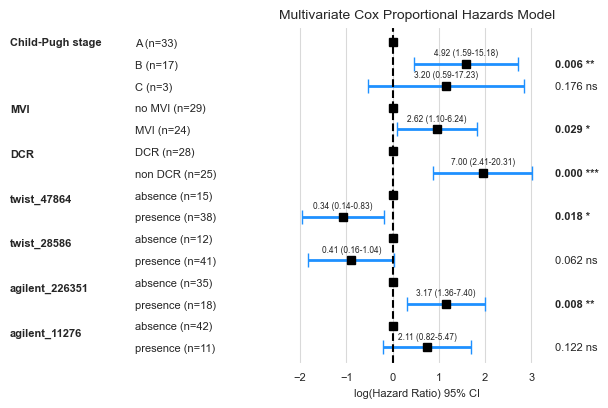

In [121]:
variables = multivariate_peptides_forest_reversed['Variable']
p_values = multivariate_peptides_forest_reversed['P-value']
groups = multivariate_peptides_forest_reversed['Group']
N = multivariate_peptides_forest_reversed['N']
hr = multivariate_peptides_forest_reversed['log_HR']
lower_ci = multivariate_peptides_forest_reversed['log_95% CI Lower']
upper_ci = multivariate_peptides_forest_reversed['log_95% CI Upper']
actual_hr = multivariate_peptides_forest_reversed['Hazard Ratio']  # Store actual HR values for display
actual_lc = multivariate_peptides_forest_reversed['95% CI Lower']
actual_uc = multivariate_peptides_forest_reversed['95% CI Upper']

# Convert p-values to significance stars
def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(7, 5), gridspec_kw={'width_ratios': [1, 4]})  # Adjusted width ratios

# **First subplot: Variable names in bold**
for i, var in enumerate(variables):
    ax1.text(0, (i + 0.2) / len(variables), f"{var}", fontsize=8, ha='left', fontweight='bold')

# Remove the x and y axis ticks/labels in the first subplot
ax1.axis('off')

# **Second subplot: Forest plot with HR, CI, Group labels, and P-values**
# Plot hazard ratios with error bars (95% CI)
ax2.errorbar(hr, np.arange(len(variables)), xerr=[np.array(hr) - np.array(lower_ci), np.array(upper_ci) - np.array(hr)],
             fmt='s', color='black', ecolor='dodgerblue', elinewidth=2, capsize=5)

# Adding the reference line at HR = 1
ax2.axvline(np.log(1), color='black', linestyle='--')

# Annotate with text: Adding p-values and CI on top of each HR point
for i, (h, l, u, p) in enumerate(zip(hr, lower_ci, upper_ci, p_values)):
    if pd.notna(p) and p != 'ns':
        significance = get_significance_stars(p)
        p_value_text = f'{p:.3f} {significance}'
        
        # Make p-value bold if significant
        if p < 0.05:
            ax2.text(np.nanmax(np.array(upper_ci)) + 0.5, i, p_value_text, va='center', ha='left', fontsize=8, fontweight='bold')
        else:
            ax2.text(np.nanmax(np.array(upper_ci)) + 0.5, i, p_value_text, va='center', ha='left', fontsize=8)

# Add actual HR values on top of the squares, only for HR != 1
for i, (h,actual, l, u) in enumerate(zip(hr, actual_hr, actual_lc, actual_uc)):
    if actual != 1.0:  # Only add HR value if it is not equal to 1
        ax2.text(h, i+0.5, f'{actual:.2f} ({l:.2f}-{u:.2f})', ha='center', va='center', fontsize=6)

# Combine the Variable and Group labels for the second plot
combined_labels = [
    f"{grp} (n={n})" for var, grp, n in zip(variables, groups, N)
]

# Set the y-tick labels for the second subplot: first the variable names (bold), then the group and N values (regular)
ax2.set_yticks(np.arange(len(variables)))  # Set y-ticks to match number of variables
ax2.set_yticklabels(combined_labels, ha='left')  # Set the y-tick labels with both variable and group information
ax2.tick_params(axis='y', labelsize=8)  # Set font size for y-axis labels
ax2.set_xlim(np.nanmin(lower_ci) - 0.5, np.nanmax(upper_ci) + 0.5)  # Extend the x-axis limit (you can adjust this value as necessary)
ax2.get_yaxis().set_tick_params(pad=100)
# Set labels and title for the second plot
ax2.set_xlabel('log(Hazard Ratio) 95% CI', fontsize=8)
ax2.tick_params(axis='x', labelsize=8)
ax2.set_title('Multivariate Cox Proportional Hazards Model', fontsize=10)

# Set grid lines: show only vertical lines
ax2.grid(False, axis='y')
ax2.grid(True, axis='x', linestyle='-', color='black', alpha=0.15)  # Only vertical grid lines
ax2.set_facecolor('white')
# Adjust layout to make subplots closer
plt.tight_layout(pad=4)
plt.savefig(Path(config.figures_dir, f'forest_plot_multivariate_coxph_peptides_{number_peptides}'), dpi=300, bbox_inches='tight')

# Check Assumptions

In [123]:
cph_bwd.check_assumptions(clinical_meta_train[["OS months", "OS Status"] + selected_predictors],  p_value_threshold=0.01, show_plots=True)
# Save all generated figures
for i in plt.get_fignums():  # Loop through all open figures
    plt.figure(i)
    plt.savefig(Path(config.figures_dir / f"cox_assumption_check_bwd_{i}.png"), dpi=300, bbox_inches="tight")
plt.close("all")  # Close all figures


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


In [124]:
cph_bwd_peptides.check_assumptions(clinical_meta_train[["OS months", "OS Status"] + selected_predictors_peptides],  p_value_threshold=0.05, show_plots=True)
# Save all generated figures
for i in plt.get_fignums():  # Loop through all open figures
    plt.figure(i)
    plt.savefig(Path(config.figures_dir / f"cox_assumption_check_bwd_peptides_{i}.png"), dpi=300, bbox_inches="tight")
plt.close("all")


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


# Parametric Model Testing
## QQPlot



In [125]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.reshape(4,)
for i, model in enumerate([WeibullFitter(), LogNormalFitter(), LogLogisticFitter(), ExponentialFitter()]):
    model.fit(clinical_meta_train["OS months"], clinical_meta_train["OS Status"])
    qq_plot(model, ax=axes[i])
    # Print AIC
    print("The AIC value for", model.__class__.__name__, "is",  model.AIC_)
fig_path = Path(config.figures_dir) / f'QQplot_Parametric_Models_TrainingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.close()

# Testing Set
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.reshape(4,)
for i, model in enumerate([WeibullFitter(), LogNormalFitter(), LogLogisticFitter(), ExponentialFitter()]):
    model.fit(clinical_meta_test["OS months"], clinical_meta_test["OS Status"])
    qq_plot(model, ax=axes[i])
    # Print AIC
    print("The AIC value for", model.__class__.__name__, "is",  model.AIC_)
fig_path = Path(config.figures_dir) / f'QQplot_Parametric_Models_TestingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.close()

best_model, best_aic_ = find_best_parametric_model(event_times=clinical_meta_test["OS months"],
event_observed=clinical_meta_test["OS Status"],
scoring_method="AIC")
print(best_model)

The AIC value for WeibullFitter is 254.23412880641288
The AIC value for LogNormalFitter is 252.27093842585492
The AIC value for LogLogisticFitter is 253.34242131342384
The AIC value for ExponentialFitter is 252.26557566104725
The AIC value for WeibullFitter is 113.30730745906159
The AIC value for LogNormalFitter is 114.39875526653287
The AIC value for LogLogisticFitter is 114.1167346008522
The AIC value for ExponentialFitter is 112.10058699307376
<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 24 total observations, 10 right-censored observations>


# Weibull BWD Models with Partial Effects

In [126]:
weibull_bwd = WeibullAFTFitter()
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])

weibull_bwd.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)
covariates_groups = weibull_bwd.summary.index.get_level_values(1)
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group
#variables['DCR_ctg'] = ["DCR"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    weibull_bwd.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'WeibullAFT_BWD_Partial_Effects_Outcome_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

# Prepare the external validation set (clinical_meta_test)
validation_data = clinical_meta_test[["OS months", "OS Status"] + selected_predictors]
predicted_risk_scores_weibull_bwd = -weibull_bwd.predict_median(validation_data)
# Calculate the C-index on the external validation set
c_index_external = concordance_index_ipcw(y_surv_train, y_surv_test, predicted_risk_scores_weibull_bwd)[0]
print(f"C-index on the external validation set: {c_index_external:.4f}")
#C-index on the external validation set: 0.7515

C-index on the external validation set: 0.7515


In [127]:
weibull_bwd_peptides = WeibullAFTFitter()
formula_peptides = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors_peptides])

weibull_bwd_peptides.fit(clinical_meta_train[["OS months", "OS Status"] + selected_predictors_peptides],
        duration_col="OS months", event_col="OS Status", formula=formula_peptides)
covariates_groups = weibull_bwd_peptides.summary.index.get_level_values(1)
# Initialize dictionaries to store the variables and groups
variables = {}
# Iterate through the covariates and groups
for label in covariates_groups:
    if '[T.' in label:  # Check if it contains the '[T.' group part
        # Extract variable name (the part before '[T.')
        variable = label.split('[')[0].strip('C()').replace('`', '')
        group = label.split('[T.')[1].split(']')[0]

        if variable in variables:
            variables[variable].append(group)  # Add group to the existing variable list
        else:
            variables[variable] = [group]  # Initialize the variable with a list containing the group


variables['twist_47864'] = ["absence"]
variables['twist_28586'] = ["absence"]

for covariate, values in variables.items():
    # Plot partial effects for each covariate with specified values
    cleaned_covariate = re.sub(r'(_ctg|stage)', '', covariate)
    fig, ax = plt.subplots(figsize=(8, 4))
    weibull_bwd_peptides.plot_partial_effects_on_outcome(covariates=covariate, values=values, cmap='coolwarm', ax=ax)

    # Add the x-axis label to the plot
    ax.set_title(cleaned_covariate, fontsize=12)
    ax.set_xlabel("Time (Months)", fontsize=10)
    ax.set_ylabel("Survival Probability", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
     # Update legend to use the cleaned-up covariate name
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [re.sub(r'(_ctg|stage)', '', label) for label in labels])

    fig_path = Path(config.figures_dir) / f'WeibullAFT_BWD-Peptides_Partial_Effects_Outcome_{covariate}_{number_peptides}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()

# Prepare the external validation set (clinical_meta_test)
validation_data = clinical_meta_test[["OS months", "OS Status"] + selected_predictors_peptides]
predicted_risk_scores_weibull_bwd_peptides = -weibull_bwd_peptides.predict_median(validation_data)
# Calculate the C-index on the external validation set
c_index_external = concordance_index_ipcw(y_surv_train, y_surv_test, predicted_risk_scores_weibull_bwd_peptides)[0]
print(f"C-index on the external validation set: {c_index_external:.4f}")
#C-index on the external validation set: 0.7469

C-index on the external validation set: 0.7469


# Time-Dependent C-Index


Spearman Rank Correlation: 0.9903, p-value: 0.0000


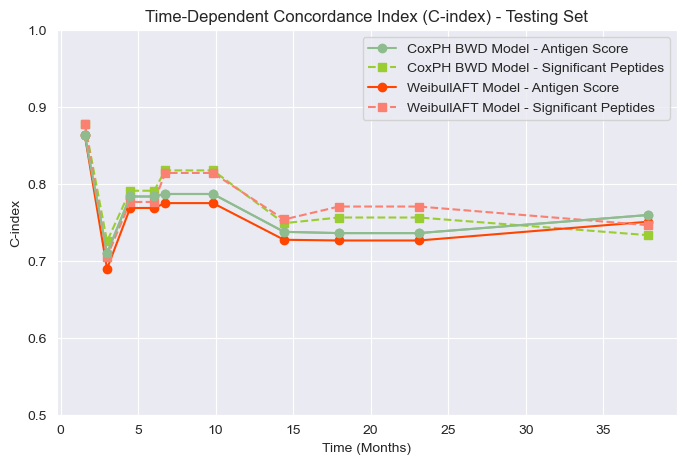

In [129]:
# Define time horizons (percentiles of observed survival times in external validaion set)
time_horizons = np.percentile(y_surv_test["time"], np.linspace(10, 99, 10))

# Compute time-dependent C-index using inverse probability of censoring weights (IPCW)
c_indices = []
for t in time_horizons:

    # Compute C-index for this time point
    c_index_t = concordance_index_ipcw(
        y_surv_train,   # Training survival data (for censoring distribution estimation)
        y_surv_test,  # Validation survival data (for C-index calculation)
        predicted_risk_scores_bwd,
        tau=t  # Time horizon for evaluation
    )[0]  # Extract the C-index value

    c_indices.append(c_index_t)

# Compute time-dependent C-index using predicted_risk_scores_bwd_peptides
c_indices_bwd_peptides = []
for t in time_horizons:
    c_index_t_peptides = concordance_index_ipcw(
        y_surv_train,  # Training survival data
        y_surv_test,  # Validation survival data
        predicted_risk_scores_bwd_peptides,
        tau=t  # Time horizon for evaluation
    )[0]  # Extract the C-index value

    c_indices_bwd_peptides.append(c_index_t_peptides)

# Compute time-dependent C-index using predicted_risk_scores_bwd_peptides
c_indices_weibull_bwd = []
for t in time_horizons:
    c_index_t = concordance_index_ipcw(
        y_surv_train,  # Training survival data
        y_surv_test,  # Validation survival data
        predicted_risk_scores_weibull_bwd,
        tau=t  # Time horizon for evaluation
    )[0]  # Extract the C-index value

    c_indices_weibull_bwd.append(c_index_t)

# Compute time-dependent C-index using predicted_risk_scores_bwd_peptides
c_indices_weibull_bwd_peptides = []
for t in time_horizons:
    c_index_t_peptides = concordance_index_ipcw(
        y_surv_train,  # Training survival data
        y_surv_test,  # Validation survival data
        predicted_risk_scores_weibull_bwd_peptides,
        tau=t  # Time horizon for evaluation
    )[0]  # Extract the C-index value

    c_indices_weibull_bwd_peptides.append(c_index_t_peptides)

# Plot the time-dependent C-index
plt.figure(figsize=(8, 5))
plt.plot(time_horizons, c_indices, color = 'darkseagreen', marker='o', linestyle='-', label="CoxPH BWD Model - Antigen Score")
plt.plot(time_horizons, c_indices_bwd_peptides, color = 'yellowgreen', marker='s', linestyle='--', label="CoxPH BWD Model - Significant Peptides")
plt.plot(time_horizons, c_indices_weibull_bwd, color = 'orangered', alpha=1, marker='o', linestyle='-', label="WeibullAFT Model - Antigen Score")
plt.plot(time_horizons, c_indices_weibull_bwd_peptides, color = 'salmon', marker='s', linestyle='--', label="WeibullAFT Model - Significant Peptides")
plt.plot(time_horizons, c_indices, color = 'darkseagreen', marker='o', linestyle='-')
plt.xlabel("Time (Months)")
plt.ylabel("C-index")
plt.title("Time-Dependent Concordance Index (C-index) - Testing Set")
plt.legend(loc="upper right")  # Legend positioned at the top right
plt.ylim(0.5, 1.0)
fig_path = Path(config.figures_dir) / f'Time-Dependent_C-index_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
#plt.close()
#plt.show()
from scipy import stats
# Compute Spearman correlation (rank-based correlation)
rho, p_value = stats.spearmanr(predicted_risk_scores_bwd, predicted_risk_scores_weibull_bwd)
print(f"Spearman Rank Correlation: {rho:.4f}, p-value: {p_value:.4f}")

# Prognostic Significance of the CoxPH Models

In [130]:
var_name_df = {"Child-Pugh stage":"Child-Pugh_ctg stage",
               "DCR": "DCR_ctg",
               "Antigen Score coxnet":"Antigen Score coxnet (Dichotomized) ctg",
               "MVI":"MVI_ctg"}

groups_name_df = {"B - Ref A":"stage B",
                  "C - Ref A":"stage C",
                  "non DCR - Ref DCR":"non DCR",
                  "High  - Ref Low":"High Antigen Score",
                  "presence - Ref absence":"presence"}

multivariate_bwd_cph['Variable'] = multivariate_bwd_cph['Variable'].replace(var_name_df)
multivariate_bwd_cph['Group'] = multivariate_bwd_cph['Group'].replace(groups_name_df)

# 1. Create a lookup dictionary mapping (variable, group) -> score points.
score_map = {
    (row['Variable'], row['Group']): row['Score points']
    for idx, row in multivariate_bwd_cph.iterrows()
}
# 2. Initialize a new column in clinical_meta_train for the total score.
clinical_meta_train['Model 1 Score'] = 0.0

# 3. Loop over each unique variable in multivariate_bwd_cph
for var in multivariate_bwd_cph['Variable'].unique():
    if var in clinical_meta_train.columns:
        # If the combination (var, group) is not found in score_map, default to 0.
        scores = clinical_meta_train[var].map(lambda grp: score_map.get((var, grp), 0))
        clinical_meta_train['Model 1 Score'] = np.array(clinical_meta_train['Model 1 Score']) + np.array(scores)

#######
multivariate_bwd_peptides_cph['Variable'] = multivariate_bwd_peptides_cph['Variable'].replace(var_name_df)
multivariate_bwd_peptides_cph['Group'] = multivariate_bwd_peptides_cph['Group'].replace(groups_name_df)

# 1. Create a lookup dictionary mapping (variable, group) -> score points.
score_map = {
    (row['Variable'], row['Group']): row['Score points']
    for idx, row in multivariate_bwd_peptides_cph.iterrows()
}
# 2. Initialize a new column in clinical_meta_train for the total score.
clinical_meta_train['Model 2 Score'] = 0.0

# 3. Loop over each unique variable in multivariate_bwd_cph
for var in multivariate_bwd_peptides_cph['Variable'].unique():
    if var in clinical_meta_train.columns:
        # If the combination (var, group) is not found in score_map, default to 0.
        scores = clinical_meta_train[var].map(lambda grp: score_map.get((var, grp), 0))
        clinical_meta_train['Model 2 Score'] = np.array(clinical_meta_train['Model 2 Score']) + np.array(scores)

In [131]:
# 1. Create a lookup dictionary mapping (variable, group) -> score points.
score_map = {
    (row['Variable'], row['Group']): row['Score points']
    for idx, row in multivariate_bwd_cph.iterrows()
}
# 2. Initialize a new column in clinical_meta_train for the total score.
clinical_meta_test['Model 1 Score'] = 0.0

# 3. Loop over each unique variable in multivariate_bwd_cph
for var in multivariate_bwd_cph['Variable'].unique():
    if var in clinical_meta_test.columns:
        # If the combination (var, group) is not found in score_map, default to 0.
        scores = clinical_meta_test[var].map(lambda grp: score_map.get((var, grp), 0))
        clinical_meta_test['Model 1 Score'] = np.array(clinical_meta_test['Model 1 Score']) + np.array(scores)
        
#######
# 1. Create a lookup dictionary mapping (variable, group) -> score points.
score_map = {
    (row['Variable'], row['Group']): row['Score points']
    for idx, row in multivariate_bwd_peptides_cph.iterrows()
}
# 2. Initialize a new column in clinical_meta_train for the total score.
clinical_meta_test['Model 2 Score'] = 0.0

# 3. Loop over each unique variable in multivariate_bwd_cph
for var in multivariate_bwd_peptides_cph['Variable'].unique():
    if var in clinical_meta_test.columns:
        # If the combination (var, group) is not found in score_map, default to 0.
        scores = clinical_meta_test[var].map(lambda grp: score_map.get((var, grp), 0))
        clinical_meta_test['Model 2 Score'] = np.array(clinical_meta_test['Model 2 Score']) + np.array(scores)

<Axes: title={'center': 'Distribution of Model 1-2 Score'}, xlabel='Score', ylabel='Frequency'>

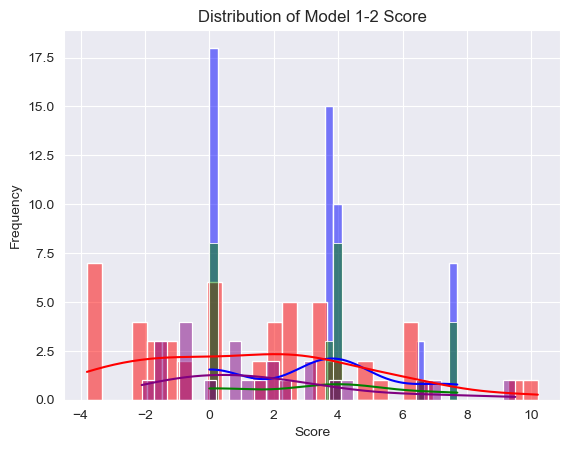

In [132]:
sns.histplot(clinical_meta_train['Model 1 Score'], bins=30, kde=True, color="blue")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Model 1-2 Score")

sns.histplot(clinical_meta_train['Model 2 Score'], bins=30, kde=True, color="red")
sns.histplot(clinical_meta_test['Model 1 Score'], bins=30, kde=True, color="green")
sns.histplot(clinical_meta_test['Model 2 Score'], bins=30, kde=True, color="purple")

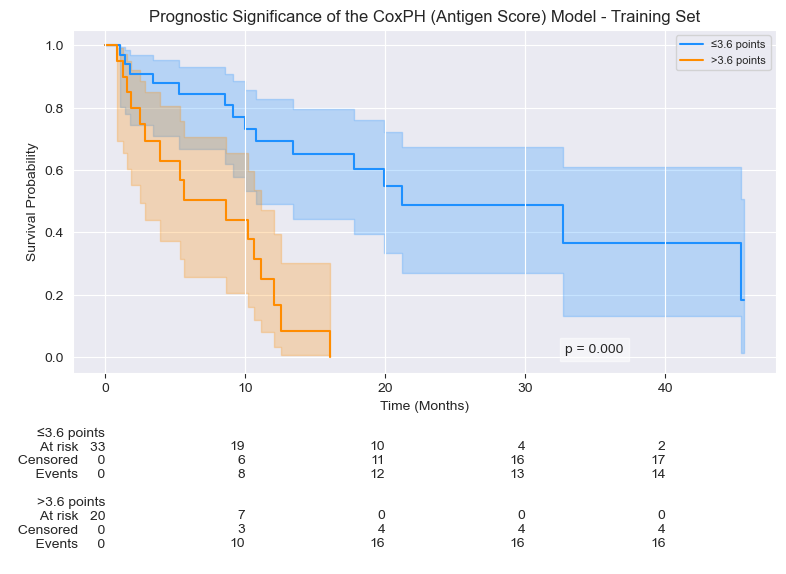

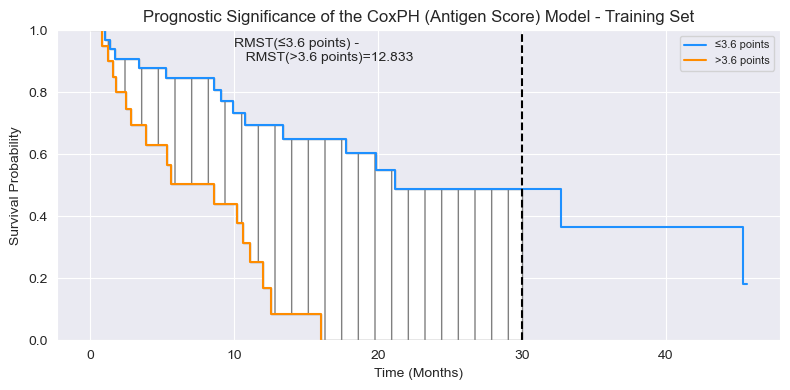

In [134]:
# Define threshold for grouping
threshold = clinical_meta_train['Model 1 Score'].median()  # You can adjust this
clinical_meta_train['Risk Group'] =  clinical_meta_train['Model 1 Score'].apply(lambda x: f'≤{round(threshold, 2)} points' if x <= threshold else f'>{round(threshold, 2)} points')

# Create Kaplan-Meier Fitters for each group
kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

# Filter data based on groups
low_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f"≤{round(threshold, 2)} points"]
high_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f">{round(threshold, 2)} points"]

# Fit survival curves
kmf_low.fit(low_risk['OS months'], event_observed=low_risk['OS Status'], label=f"≤{round(threshold, 2)} points")
kmf_high.fit(high_risk['OS months'], event_observed=high_risk['OS Status'], label=f">{round(threshold, 2)} points")


result = logrank_test(low_risk['OS months'], high_risk['OS months'],
                      event_observed_A=low_risk['OS Status'],
                      event_observed_B=high_risk['OS Status'])
p_value_text = f'p = {result.p_value:.3f}'
# Calculate the median survival time and 95% CI for this group
median_survival = kmf_low.median_survival_time_
ci_lower, ci_upper = median_survival_times(kmf_low.confidence_interval_).iloc[0,0], median_survival_times(kmf_low.confidence_interval_).iloc[0,1]

group_colors = {0: 'dodgerblue', 1: 'darkorange'}
###################
fig, ax = plt.subplots(figsize=(8, 6))
kmf_low.plot_survival_function(ax=ax, ci_show=True, color=group_colors[0]) #linestyle="dotted"
kmf_high.plot_survival_function(ax=ax, ci_show=True, color=group_colors[1]) #linestyle="dotted"
ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
add_at_risk_counts(kmf_low, kmf_high, ax=ax)
ax.set_title("Prognostic Significance of the CoxPH (Antigen Score) Model - Training Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_kaplan_meier_trainingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

##################
fig, ax = plt.subplots(figsize=(8, 4))
rmst_plot(kmf_low, model2=kmf_high, text_position=(10, 0.9), t=30, ax=ax)
# Access the plot lines and change their colors
lines = ax.get_lines()
lines[0].set_color(group_colors[0])
lines[1].set_color(group_colors[1])
ax.set_title("Prognostic Significance of the CoxPH (Antigen Score) Model - Training Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
ax.legend([lines[0], lines[1]], [kmf_low.label, kmf_high.label], fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_kaplan_meier_RMST_trainingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')


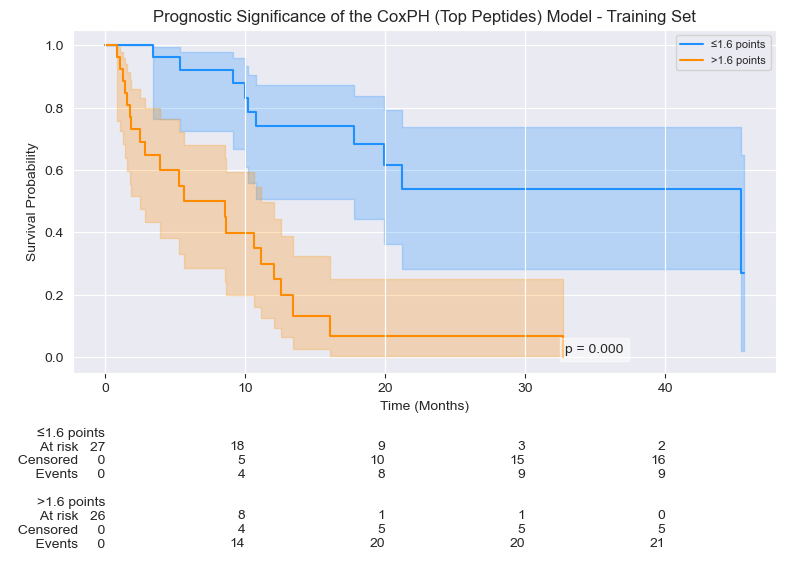

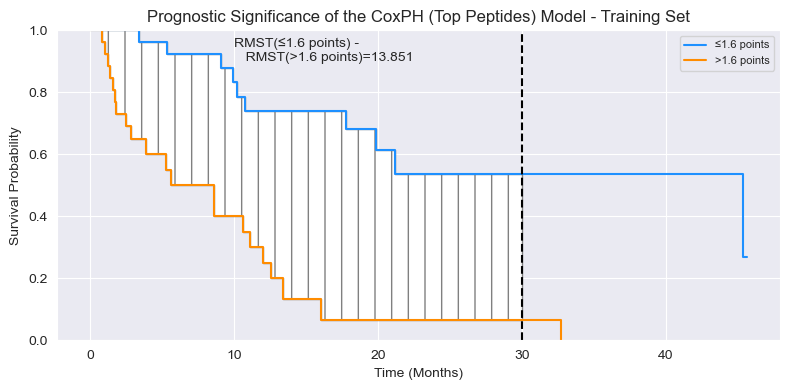

In [135]:
# Define threshold for grouping
threshold = clinical_meta_train['Model 2 Score'].median()  # You can adjust this
clinical_meta_train['Risk Group'] =  clinical_meta_train['Model 2 Score'].apply(lambda x: f'≤{round(threshold, 2)} points' if x <= threshold else f'>{round(threshold, 2)} points')

# Create Kaplan-Meier Fitters for each group
kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

# Filter data based on groups
low_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f"≤{round(threshold, 2)} points"]
high_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f">{round(threshold, 2)} points"]

# Fit survival curves
kmf_low.fit(low_risk['OS months'], event_observed=low_risk['OS Status'], label=f"≤{round(threshold, 2)} points")
kmf_high.fit(high_risk['OS months'], event_observed=high_risk['OS Status'], label=f">{round(threshold, 2)} points")


result = logrank_test(low_risk['OS months'], high_risk['OS months'],
                      event_observed_A=low_risk['OS Status'],
                      event_observed_B=high_risk['OS Status'])
p_value_text = f'p = {result.p_value:.3f}'
# Calculate the median survival time and 95% CI for this group
median_survival = kmf_low.median_survival_time_
ci_lower, ci_upper = median_survival_times(kmf_low.confidence_interval_).iloc[0,0], median_survival_times(kmf_low.confidence_interval_).iloc[0,1]

group_colors = {0: 'dodgerblue', 1: 'darkorange'}
###################
fig, ax = plt.subplots(figsize=(8, 6))
kmf_low.plot_survival_function(ax=ax, ci_show=True, color=group_colors[0]) #linestyle="dotted"
kmf_high.plot_survival_function(ax=ax, ci_show=True, color=group_colors[1]) #linestyle="dotted"
ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
add_at_risk_counts(kmf_low, kmf_high, ax=ax)
ax.set_title("Prognostic Significance of the CoxPH (Top Peptides) Model - Training Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_peptides_kaplan_meier_trainingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

##################
fig, ax = plt.subplots(figsize=(8, 4))
rmst_plot(kmf_low, model2=kmf_high, text_position=(10, 0.9), t=30, ax=ax)
# Access the plot lines and change their colors
lines = ax.get_lines()
lines[0].set_color(group_colors[0])
lines[1].set_color(group_colors[1])
ax.set_title("Prognostic Significance of the CoxPH (Top Peptides) Model - Training Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
ax.legend([lines[0], lines[1]], [kmf_low.label, kmf_high.label], fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_peptides_kaplan_meier_RMST_trainingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')


## Testing Set

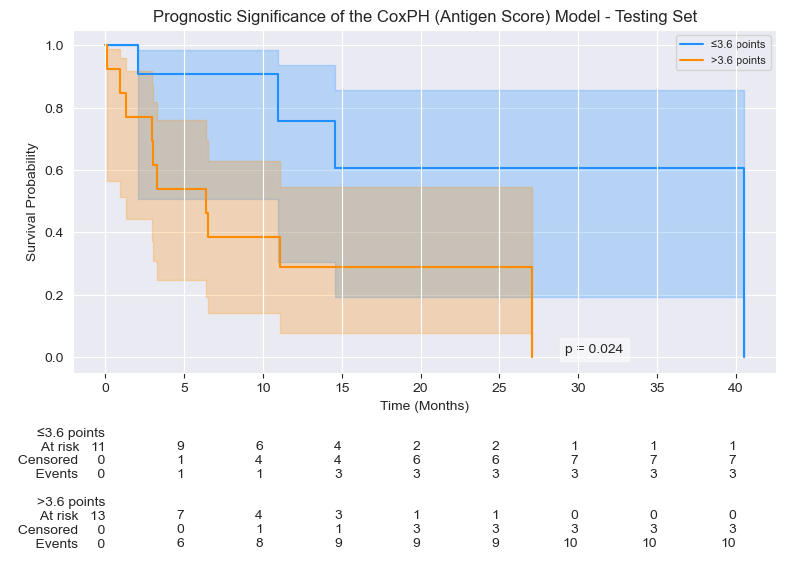

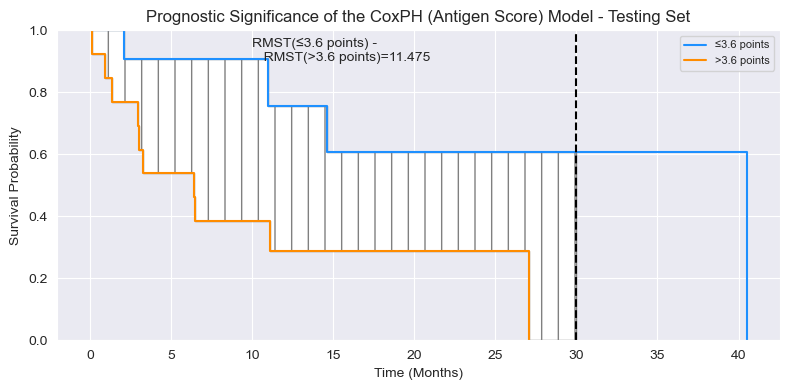

In [136]:
# Define threshold for grouping
threshold = clinical_meta_train['Model 1 Score'].median()  # You can adjust this
clinical_meta_test['Risk Group'] =  clinical_meta_test['Model 1 Score'].apply(lambda x: f'≤{round(threshold, 2)} points' if x <= threshold else f'>{round(threshold, 2)} points')

# Create Kaplan-Meier Fitters for each group
kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

# Filter data based on groups
low_risk = clinical_meta_test[clinical_meta_test['Risk Group'] == f"≤{round(threshold, 2)} points"]
high_risk = clinical_meta_test[clinical_meta_test['Risk Group'] == f">{round(threshold, 2)} points"]

# Fit survival curves
kmf_low.fit(low_risk['OS months'], event_observed=low_risk['OS Status'], label=f"≤{round(threshold, 2)} points")
kmf_high.fit(high_risk['OS months'], event_observed=high_risk['OS Status'], label=f">{round(threshold, 2)} points")


# Calculate the median survival time and 95% CI for this group
median_survival = kmf_low.median_survival_time_
ci_lower, ci_upper = median_survival_times(kmf_low.confidence_interval_).iloc[0,0], median_survival_times(kmf_low.confidence_interval_).iloc[0,1]

result = logrank_test(low_risk['OS months'], high_risk['OS months'],
                      event_observed_A=low_risk['OS Status'],
                      event_observed_B=high_risk['OS Status'])
p_value_text = f'p = {result.p_value:.3f}'

group_colors = {0: 'dodgerblue', 1: 'darkorange'}

###################
fig, ax = plt.subplots(figsize=(8, 6))
kmf_low.plot_survival_function(ax=ax, ci_show=True, color=group_colors[0]) #linestyle="dotted"
kmf_high.plot_survival_function(ax=ax, ci_show=True, color=group_colors[1]) #linestyle="dotted"
ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
add_at_risk_counts(kmf_low, kmf_high, ax=ax)
ax.set_title("Prognostic Significance of the CoxPH (Antigen Score) Model - Testing Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_kaplan_meier_testingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

##################
fig, ax = plt.subplots(figsize=(8, 4))
rmst_plot(kmf_low, model2=kmf_high, text_position=(10, 0.9), t=30, ax=ax)
# Access the plot lines and change their colors
lines = ax.get_lines()
lines[0].set_color(group_colors[0])
lines[1].set_color(group_colors[1])
ax.set_title("Prognostic Significance of the CoxPH (Antigen Score) Model - Testing Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
ax.legend([lines[0], lines[1]], [kmf_low.label, kmf_high.label], fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_kaplan_meier_RMST_testingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

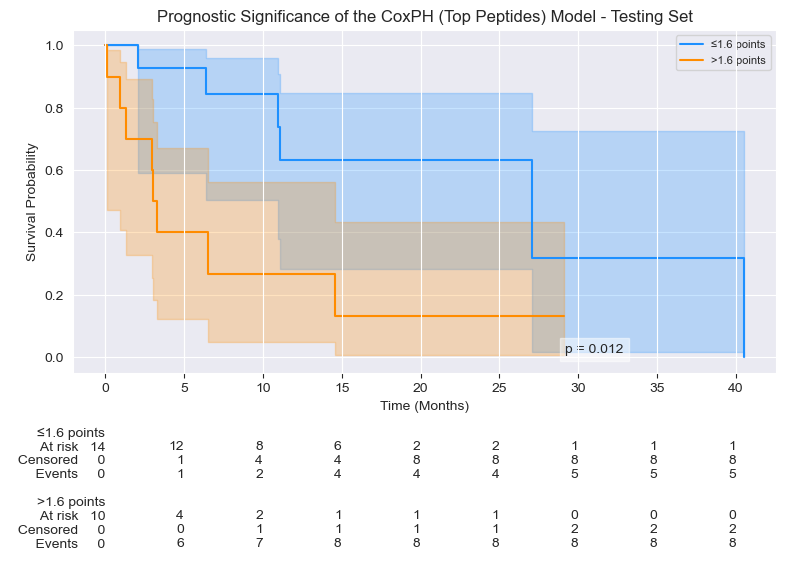

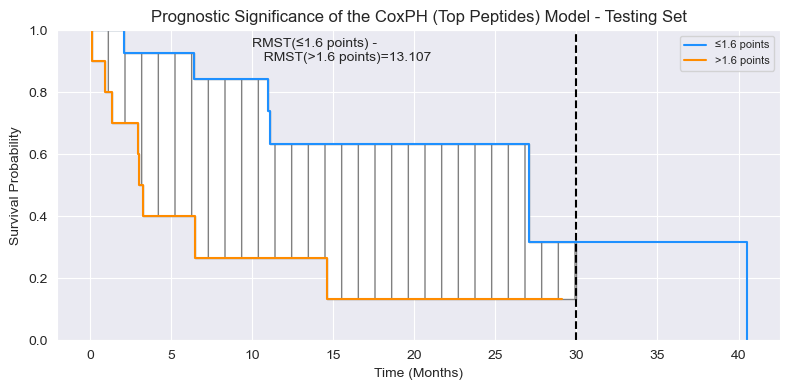

In [137]:
# Define threshold for grouping
threshold = clinical_meta_train['Model 2 Score'].median()  # You can adjust this
clinical_meta_test['Risk Group'] =  clinical_meta_test['Model 2 Score'].apply(lambda x: f'≤{round(threshold, 2)} points' if x <= threshold else f'>{round(threshold, 2)} points')

# Create Kaplan-Meier Fitters for each group
kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

# Filter data based on groups
low_risk = clinical_meta_test[clinical_meta_test['Risk Group'] == f"≤{round(threshold, 2)} points"]
high_risk = clinical_meta_test[clinical_meta_test['Risk Group'] == f">{round(threshold, 2)} points"]

# Fit survival curves
kmf_low.fit(low_risk['OS months'], event_observed=low_risk['OS Status'], label=f"≤{round(threshold, 2)} points")
kmf_high.fit(high_risk['OS months'], event_observed=high_risk['OS Status'], label=f">{round(threshold, 2)} points")


# Calculate the median survival time and 95% CI for this group
median_survival = kmf_low.median_survival_time_
ci_lower, ci_upper = median_survival_times(kmf_low.confidence_interval_).iloc[0,0], median_survival_times(kmf_low.confidence_interval_).iloc[0,1]

result = logrank_test(low_risk['OS months'], high_risk['OS months'],
                      event_observed_A=low_risk['OS Status'],
                      event_observed_B=high_risk['OS Status'])
p_value_text = f'p = {result.p_value:.3f}'

group_colors = {0: 'dodgerblue', 1: 'darkorange'}

###################
fig, ax = plt.subplots(figsize=(8, 6))
kmf_low.plot_survival_function(ax=ax, ci_show=True, color=group_colors[0]) #linestyle="dotted"
kmf_high.plot_survival_function(ax=ax, ci_show=True, color=group_colors[1]) #linestyle="dotted"
ax.text(0.7, 0.05, p_value_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.5))
add_at_risk_counts(kmf_low, kmf_high, ax=ax)
ax.set_title("Prognostic Significance of the CoxPH (Top Peptides) Model - Testing Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_peptides_kaplan_meier_testingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

##################
fig, ax = plt.subplots(figsize=(8, 4))
rmst_plot(kmf_low, model2=kmf_high, text_position=(10, 0.9), t=30, ax=ax)
# Access the plot lines and change their colors
lines = ax.get_lines()
lines[0].set_color(group_colors[0])
lines[1].set_color(group_colors[1])
ax.set_title("Prognostic Significance of the CoxPH (Top Peptides) Model - Testing Set", fontsize=12)
ax.set_xlabel("Time (Months)", fontsize=10)
ax.set_ylabel("Survival Probability", fontsize=10)
            #ax.grid(True, linestyle='--', alpha=0.7)
ax.legend([lines[0], lines[1]], [kmf_low.label, kmf_high.label], fontsize=8)
plt.tight_layout()
fig_path = Path(config.figures_dir) / f'PointScores_peptides_kaplan_meier_RMST_testingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

## Different Thresholds

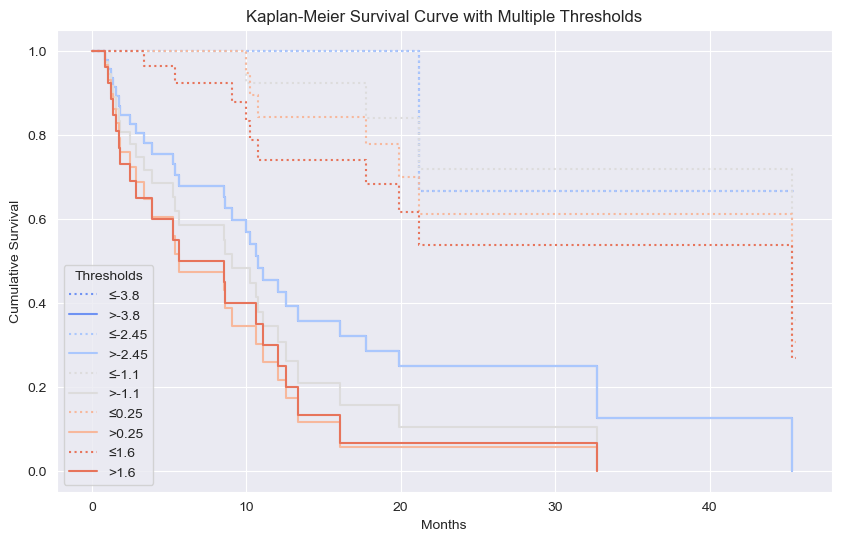

In [215]:
# Define range of thresholds from minimum to median score
min_score = clinical_meta_train['Model 2 Score'].min()
median_score = clinical_meta_train['Model 2 Score'].median()
thresholds = np.linspace(min_score, median_score, num=5)  # Adjust 'num' for more thresholds

# Plot Setup
plt.figure(figsize=(10, 6))

# Define colors for plotting
colors = sns.color_palette("coolwarm", len(thresholds))

# Iterate over different thresholds
for i, threshold in enumerate(thresholds):
    # Assign risk groups dynamically
    clinical_meta_train['Risk Group'] = clinical_meta_train['Model 2 Score'].apply(lambda x: f'≤{round(threshold, 2)}' if x <= threshold else f'>{round(threshold, 2)}')

    # Separate into low and high risk groups
    low_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f'≤{round(threshold, 2)}']
    high_risk = clinical_meta_train[clinical_meta_train['Risk Group'] == f'>{round(threshold, 2)}']

    # Kaplan-Meier Fitting
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()

    kmf_low.fit(low_risk['OS months'], event_observed=low_risk['OS Status'], label=f"≤{round(threshold, 2)}")
    kmf_high.fit(high_risk['OS months'], event_observed=high_risk['OS Status'], label=f">{round(threshold, 2)}")

    # Plot both curves
    kmf_low.plot_survival_function(color=colors[i], linestyle="dotted", ci_show=False)
    kmf_high.plot_survival_function(color=colors[i], linestyle="solid", ci_show=False)

# Final plot formatting
plt.xlabel("Months")
plt.ylabel("Cumulative Survival")
plt.title("Kaplan-Meier Survival Curve with Multiple Thresholds")
plt.legend(title="Thresholds")
plt.grid(True)
plt.show()